# EEG Epilepsy Network Analysis Pipeline

---
## 0a · Install Dependencies

Run this cell **once** before anything else.

In [1]:
%pip install mne ts2vg networkx scipy pandas matplotlib numpy pillow -q
print("\u2713 All dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
✓ All dependencies installed


---
## 0b · Imports, Paths & Constants

Loads all libraries, configures file paths, defines shared constants  
(channel names, graph parameters, colours), and registers benchmark helper functions.

> **Note:** Launch Jupyter from the **project root** (the folder that contains  
> `data/`, `reports/`, `src/`) so that relative paths resolve correctly.

In [2]:
import argparse, sys
from pathlib import Path

for _stream in (sys.stdout, sys.stderr):
    if hasattr(_stream, "reconfigure"):
        _stream.reconfigure(encoding="utf-8", errors="replace")

# Jupyter-friendly defaults (no CLI args in notebook)
import types
ARGS = types.SimpleNamespace(
    build_graph_only=False,
    validate_only=False,
    skip_heavy=False,
    section=None,
)

# ── Standard-library imports (always available) ────────────────────────────────
import csv, json, math, os, random, time, tracemalloc, urllib.request, warnings
from collections import Counter, defaultdict

# ── Third-party imports (just installed) ──────────────────────────────────────
import pandas as pd
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import scipy.cluster.hierarchy as sch
import scipy.sparse as sp
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle
from scipy.spatial.distance import squareform


# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR     = Path(".").resolve()  # project root = directory where Jupyter was launched
RAW_DIR      = BASE_DIR / "data" / "raw"
PREP_DIR     = BASE_DIR / "data" / "preprocessed"
GRAPH_DIR    = BASE_DIR / "data" / "graphs" / "adjacency_sparse"
NPZ_PATH     = GRAPH_DIR / "inter_to_ict_chb01_03_2980_3010_adjacency_sparse.npz"
FIG_DIR      = BASE_DIR / "reports" / "figures"
COSMO_DIR    = BASE_DIR / "data" / "graphs" / "cosmograph"
SM_LABELS    = BASE_DIR / "src" / "03_analytics" / "outputs" / "community_labels.npy"
EDF_PATH      = RAW_DIR / "chb01_03.edf"
SEIZURES_PATH = RAW_DIR / "chb01_03.edf.seizures"
SUMMARY_PATH  = RAW_DIR / "chb01-summary.txt"
SEGMENT_PATH  = PREP_DIR / "chb01_03_segment.npy"
CHNAMES_PATH  = PREP_DIR / "chb01_03_chnames.json"

for _d in [RAW_DIR, PREP_DIR, GRAPH_DIR, FIG_DIR, COSMO_DIR, SM_LABELS.parent]:
    _d.mkdir(parents=True, exist_ok=True)

# ── Shared constants ───────────────────────────────────────────────────────────
N_CH   = 23
N_TP   = 7680       # 30 s × 256 Hz
FS     = 256
ONSET  = 16         # seizure onset (s into 2980-3010 window)
K      = 4
WIN_S  = 5
STEP_S = 1
EXPECTED_NODES = N_CH * N_TP
EXPECTED_INTRA_EDGES = 35_161
EXPECTED_INTER_EDGES = 1_943_040
EXPECTED_TOTAL_EDGES = 1_978_201

CHANNEL_NAMES = [
    "FP1-F7","F7-T7","T7-P7","P7-O1",
    "FP1-F3","F3-C3","C3-P3","P3-O1",
    "FP2-F4","F4-C4","C4-P4","P4-O2",
    "FP2-F8","F8-T8","T8-P8","P8-O2",
    "FZ-CZ","CZ-PZ",
    "P7-T7","T7-FT9","FT9-FT10","FT10-T8","T8-P8-1",
]
CHANNEL_REGIONS = {
    "FP1-F7":"frontal","F7-T7":"frontal","T7-P7":"temporal","P7-O1":"parietal",
    "FP1-F3":"frontal","F3-C3":"central","C3-P3":"central","P3-O1":"parietal",
    "FP2-F4":"frontal","F4-C4":"central","C4-P4":"central","P4-O2":"parietal",
    "FP2-F8":"frontal","F8-T8":"frontal","T8-P8":"temporal","P8-O2":"parietal",
    "FZ-CZ":"central","CZ-PZ":"central",
    "P7-T7":"temporal","T7-FT9":"temporal","FT9-FT10":"temporal",
    "FT10-T8":"temporal","T8-P8-1":"temporal",
}

BG = "#0f1117"; PANEL = "#1a1d27"; TXT = "#e0e0e0"
ONSET_C = "#ff4f4f"; INTER_C = "#7c6af7"; ICTAL_C = "#f7936a"
CLRS = ["#B39DDB","#81C3E8","#88CFA4","#F5D87A"]

RESULTS = {}
AUTO_DISPLAY = True

# ── Benchmark helper functions (shared across sections 5a/5c/5d) ───────────────
def _bm_iced(A, labels):
    densities = []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        n_c = len(idx)
        if n_c < 2: continue
        sub = A[np.ix_(idx, idx)]
        actual = float(np.triu(sub, 1).sum())
        possible = n_c * (n_c - 1) / 2
        densities.append(actual / possible)
    return float(np.mean(densities)) if densities else 0.0

def _bm_ratio(A, labels):
    intra, inter = 0.0, 0.0
    n = len(labels)
    for i in range(n):
        for j in range(i + 1, n):
            w = A[i, j]
            if w > 0:
                if labels[i] == labels[j]: intra += w
                else: inter += w
    return inter / intra if intra > 0 else np.inf

def _bm_cond(A, labels):
    vals = []
    for c in np.unique(labels):
        rows = np.where(labels == c)[0]
        cols = np.where(labels != c)[0]
        cut = float(A[np.ix_(rows, cols)].sum())
        vol = float(A[rows, :].sum())
        vals.append(cut / vol if vol > 0 else 0.0)
    return float(np.mean(vals))

def _bm_cc(A, labels):
    coeffs = []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        if len(idx) < 3: continue
        sub = (A[np.ix_(idx, idx)] > 0).astype(float)
        np.fill_diagonal(sub, 0.0)
        for i in range(len(idx)):
            nbrs = np.where(sub[i] > 0)[0]; ki = len(nbrs)
            if ki < 2: continue
            tri = sum(sub[nbrs[u], nbrs[v]] for u in range(ki) for v in range(u+1, ki))
            coeffs.append(float(tri) / (ki*(ki-1)/2))
    return float(np.mean(coeffs)) if coeffs else 0.0

def _bm_ari(a, b):
    a, b = np.asarray(a), np.asarray(b)
    ca, cb = np.unique(a), np.unique(b)
    ma = {v: i for i, v in enumerate(ca)}; mb = {v: i for i, v in enumerate(cb)}
    C = np.zeros((len(ca), len(cb)), dtype=np.int64)
    for ai, bi in zip(a, b): C[ma[ai], mb[bi]] += 1
    def c2(n): return n*(n-1)//2
    sc = sum(c2(int(v)) for v in C.flatten())
    sa = sum(c2(int(v)) for v in C.sum(axis=1))
    sb = sum(c2(int(v)) for v in C.sum(axis=0))
    tot = c2(len(a))
    exp = sa*sb/tot if tot > 0 else 0
    mx = (sa+sb)/2
    return float((sc-exp)/(mx-exp)) if (mx-exp) > 0 else 1.0

def _bm_nmi(a, b):
    n = len(a); ca, cb = np.unique(a), np.unique(b)
    ma = {v: i for i, v in enumerate(ca)}; mb = {v: i for i, v in enumerate(cb)}
    P = np.zeros((len(ca), len(cb)))
    for ai, bi in zip(a, b): P[ma[ai], mb[bi]] += 1
    P /= n; pa, pb = P.sum(axis=1), P.sum(axis=0)
    mi = sum(P[i,j]*np.log(P[i,j]/(pa[i]*pb[j]))
             for i in range(len(ca)) for j in range(len(cb))
             if P[i,j]>0 and pa[i]>0 and pb[j]>0)
    ha = -sum(p*np.log(p) for p in pa if p>0)
    hb = -sum(p*np.log(p) for p in pb if p>0)
    return float(2*mi/(ha+hb)) if (ha+hb)>0 else 1.0

def _bm_bandpower(sig, fs, lo=1.0, hi=40.0):
    fft = np.fft.rfft(sig); freqs = np.fft.rfftfreq(len(sig), d=1.0/fs)
    psd = (np.abs(fft)**2)/len(sig); idx = (freqs>=lo)&(freqs<=hi)
    return float(psd[idx].mean()) if idx.sum()>0 else 0.0

def _bm_bpv(ch_temporal, labels, fs):
    bp = np.array([_bm_bandpower(ch_temporal[ch], fs) for ch in range(len(ch_temporal))])
    vars_ = [float(bp[np.where(labels==c)[0]].var())
             for c in np.unique(labels) if (labels==c).sum()>=2]
    return float(np.mean(vars_)) if vars_ else 0.0

def _bm_src(labels, ch_names, regions):
    regs = np.array([regions.get(ch, "unknown") for ch in ch_names])
    props = []
    for c in np.unique(labels):
        idx = np.where(labels==c)[0]
        if len(idx)==0: continue
        _, cts = np.unique(regs[idx], return_counts=True)
        props.append(cts.max()/len(idx))
    return float(np.mean(props)) if props else 0.0

def _bm_fmt(v):
    return "   inf  " if np.isinf(v) else f"{v:8.4f}"

def _bm_pavg(lst, idx):
    return float(np.mean([lst[i] for i in idx]))

def _bm_table(title, inter_idx, ictal_idx, iced_l, ratio_l, cond_l, cc_l,
               ari_str, nmi_str, runtime, peak_mem, bpv_l=None, src_l=None):
    W = 34
    print(f"\n{'='*67}")
    print(f"  {title}")
    print(f"{'='*67}")
    print(f"  {'Metric':<{W}} {'Interictal':>10}  {'Ictal':>10}")
    print(f"  {'-'*62}")
    for name, lst in [("Intra-Cluster Edge Density", iced_l),
                      ("Inter / Intra Edge Ratio",   ratio_l),
                      ("Conductance",                cond_l),
                      ("Avg Clustering Coeff (intra)", cc_l)]:
        print(f"  {name:<{W}} {_bm_fmt(_bm_pavg(lst, inter_idx))}  {_bm_fmt(_bm_pavg(lst, ictal_idx))}")
    print(f"  {'-'*62}")
    print(f"  {'ARI between runs':<{W}} {ari_str}")
    print(f"  {'NMI between runs':<{W}} {nmi_str}")
    print(f"  {'-'*62}")
    print(f"  {'Runtime (all windows)':<{W}} {runtime:8.2f} s")
    print(f"  {'Peak Memory Usage':<{W}} {peak_mem/1e6:8.1f} MB")
    print(f"  {'-'*62}")
    if bpv_l is not None:
        print(f"  {'Intra-Community Bandpower Var':<{W}} {_bm_fmt(_bm_pavg(bpv_l, inter_idx))}  {_bm_fmt(_bm_pavg(bpv_l, ictal_idx))}")
    else:
        print(f"  {'Intra-Community Bandpower Var':<{W}}      N/A        N/A")
    if src_l is not None:
        print(f"  {'Spatial Region Consistency':<{W}} {_bm_fmt(_bm_pavg(src_l, inter_idx))}  {_bm_fmt(_bm_pavg(src_l, ictal_idx))}")
    else:
        print(f"  {'Spatial Region Consistency':<{W}}      N/A        N/A")
    print(f"{'='*67}")

def _ok(name, note=""):
    pass

def _skip(name, note=""):
    pass

def _fail(name, note=""):
    print(f"  [warning] {name}" + (f" — {note}" if note else ""))

def print_section(title):
    print("\n" + "─" * 70)
    print(f"  {title}")
    print("─" * 70)


def display_figures_for_section(section_name, figure_names):
    """Display saved figures inline in Colab/Jupyter; silent no-op in plain terminal."""
    if not AUTO_DISPLAY:
        return
    try:
        import IPython
        if IPython.get_ipython() is None:
            return
        from IPython.display import Image, display, HTML
        display(HTML(
            f"<h3 style='margin-top:1.4em;padding-bottom:4px;"
            f"border-bottom:2px solid #888'>{section_name}</h3>"
        ))
        for figure_name in figure_names:
            path = FIG_DIR / figure_name
            if not path.exists():
                continue
            try:
                display(Image(filename=str(path)))
            except Exception:
                pass
    except Exception:
        pass


def display_table_for_section(section_name, data_dict):
    """Display a metric/value summary table inline; fallback to print in terminal."""
    if not AUTO_DISPLAY:
        return
    try:
        df = pd.DataFrame(
            [(k, v) for k, v in data_dict.items()],
            columns=["Metric", "Value"],
        )
        try:
            import IPython
            if IPython.get_ipython() is None:
                print(f"\n  {section_name}")
                print(df.to_string(index=False))
                return
            from IPython.display import display, HTML
            display(HTML(f"<h4 style='margin-top:0.8em'>{section_name}</h4>"))
            display(df)
        except Exception:
            print(f"\n  {section_name}")
            print(df.to_string(index=False))
    except Exception:
        pass


def validate_adjacency(path=NPZ_PATH):
    """Validate sparse adjacency against the final report/reference structure."""
    path = Path(path)
    print("\n" + "=" * 70)
    print("  ADJACENCY VALIDATION")
    print("=" * 70)
    if not path.exists() or path.stat().st_size < 1_000:
        print(f"  path: {path}")
        print("  status: missing or too small")
        return False

    mat = sp.load_npz(path).tocsr()
    shape = mat.shape
    nnz = int(mat.nnz)
    undirected_total = nnz // 2
    symmetric = (mat != mat.T).nnz == 0
    diag = mat.diagonal()
    diag_sum = float(diag.sum())
    diag_nnz = int(np.count_nonzero(diag))

    coo_upper = sp.triu(mat, k=1).tocoo()
    rows = coo_upper.row.astype(np.int64, copy=False)
    cols = coo_upper.col.astype(np.int64, copy=False)
    same_timepoint = (rows % N_TP) == (cols % N_TP)
    different_channel = (rows // N_TP) != (cols // N_TP)
    inter_layer_edges = int(np.count_nonzero(same_timepoint & different_channel))
    intra_layer_edges = int(coo_upper.nnz - inter_layer_edges)

    print(f"  shape: {shape}")
    print(f"  nnz: {nnz:,}")
    print(f"  undirected total edges: {undirected_total:,}")
    print(f"  intra-layer undirected edges: {intra_layer_edges:,}")
    print(f"  inter-layer undirected edges: {inter_layer_edges:,}")
    print(f"  symmetric: {symmetric}")
    print(f"  diagonal sum / diagonal nnz: {diag_sum:.6g} / {diag_nnz}")

    checks = {
        "shape": shape == (EXPECTED_NODES, EXPECTED_NODES),
        "nnz": nnz == EXPECTED_TOTAL_EDGES * 2,
        "undirected total edges": undirected_total == EXPECTED_TOTAL_EDGES,
        "intra-layer undirected edges": intra_layer_edges == EXPECTED_INTRA_EDGES,
        "inter-layer undirected edges": inter_layer_edges == EXPECTED_INTER_EDGES,
        "symmetric": symmetric,
        "zero diagonal": diag_sum == 0.0 and diag_nnz == 0,
    }
    passed = all(checks.values())
    display_table_for_section(
        "Adjacency Validation Summary",
        {
            "Shape": str(shape),
            "NNZ": f"{nnz:,}",
            "Undirected total edges": f"{undirected_total:,}",
            "Intra-layer edges": f"{intra_layer_edges:,}",
            "Inter-layer edges": f"{inter_layer_edges:,}",
            "Symmetric": str(symmetric),
            "Zero diagonal": str(diag_sum == 0.0 and diag_nnz == 0),
            "All checks passed": str(passed),
        },
    )
    return passed


# ── Download helper ────────────────────────────────────────────────────────────
def _dl_progress(count, block, total):
    if total > 0:
        pct = min(count * block / total * 100, 100)
        done = min(count * block, total) / 1e6
        print(f"\r    {pct:5.1f}%  {done:.1f} / {total/1e6:.1f} MB",
              end="", flush=True)

def _download(url, dest, label):
    dest.parent.mkdir(parents=True, exist_ok=True)
    print(f"  Downloading {label} …")
    print(f"    {url}")
    try:
        urllib.request.urlretrieve(url, dest, reporthook=_dl_progress)
        print(f"\n    Saved {dest.stat().st_size/1e6:.1f} MB → {dest.name}")
        return True
    except Exception as exc:
        print(f"\n  [warn] Download failed: {exc}")
        print(f"  → Place the file manually at: {dest}")
        return False

%matplotlib inline
print("\u2713 Setup complete — all constants and helpers loaded")

✓ Setup complete — all constants and helpers loaded


---
## SECTION 1 · Raw Data Download

Downloads `chb01_03.edf` (~53 MB) and `chb01_03.edf.seizures` from the project GitHub.  
Files are cached — the download is skipped if they already exist.

In [3]:
def download_raw_data():
    print_section("SECTION 1 · Raw Data Download")
    GITHUB_RAW = "https://raw.githubusercontent.com/ionikim/epilepsy_pediatrics_EEG/main/data/raw/"

    # EDF
    if EDF_PATH.exists() and EDF_PATH.stat().st_size > 10_000:
        print(f"  EDF already present: {EDF_PATH.stat().st_size/1e6:.0f} MB")
    else:
        ok = _download(GITHUB_RAW + "chb01_03.edf", EDF_PATH, "chb01_03.edf")
        if not ok:
            _fail("Raw data download", "EDF missing — place chb01_03.edf in data/raw/")
            return False

    # Seizure annotation (binary .seizures file — same format as CHB-MIT)
    if SEIZURES_PATH.exists() and SEIZURES_PATH.stat().st_size > 10:
        print(f"  Seizures file already present: {SEIZURES_PATH.name}")
    else:
        _download(GITHUB_RAW + "chb01_03.edf.seizures", SEIZURES_PATH, "chb01_03.edf.seizures")

    _ok("Raw data download", f"EDF {EDF_PATH.stat().st_size/1e6:.0f} MB")
    return True

In [4]:
# ────────────────────────────────────────────────────────────────────────
download_raw_data()


──────────────────────────────────────────────────────────────────────
  SECTION 1 · Raw Data Download
──────────────────────────────────────────────────────────────────────
    https://raw.githubusercontent.com/ionikim/epilepsy_pediatrics_EEG/main/data/raw/chb01_03.edf
    100.0%  42.4 / 42.4 MB
    Saved 42.4 MB → chb01_03.edf
    https://raw.githubusercontent.com/ionikim/epilepsy_pediatrics_EEG/main/data/raw/chb01_03.edf.seizures
    100.0%  0.0 / 0.0 MB
    Saved 0.0 MB → chb01_03.edf.seizures


True

---
## SECTION 2 · Preprocessing

Uses **MNE** to:
1. Load the raw EDF file
2. Apply a **1–45 Hz bandpass** filter
3. **Average re-reference** across all channels
4. Extract the **2980–3010 s** window (30 s · 7 680 samples @ 256 Hz)

Seizure onset is parsed from the `.seizures` annotation file.  
Segment is cached as `chb01_03_segment.npy` to speed up re-runs.

In [5]:
def preprocess_edf():
    print_section("SECTION 2 · Preprocessing  (bandpass · re-reference · window)")
    """
    Returns a pandas DataFrame with columns = [electrode_names..., 'label']
    and index = time values (seconds), for the 2980-3010 s window.
    Mirrors the notebook's process_edf_with_labels + extract_window_by_time logic.
    """
    if not EDF_PATH.exists():
        _fail("Preprocessing", "EDF not found — cannot preprocess")
        return None

    try:
        import mne
    except ImportError:
        _fail("Preprocessing", "mne not installed")
        return None

    # ── Load & filter (mirrors notebook's process_edf_with_labels) ────────────
    print("  Loading EDF …")
    raw = mne.io.read_raw_edf(str(EDF_PATH), preload=True, verbose=False)
    sfreq = raw.info["sfreq"]
    print(f"  Channels: {len(raw.ch_names)} | sfreq: {sfreq:.0f} Hz")

    print("  Bandpass filter 1–45 Hz …")
    raw.filter(1., 45., verbose=False)
    print("  Average reference …")
    raw.set_eeg_reference("average", verbose=False)

    # ── Build full DataFrame (mirrors notebook) ────────────────────────────────
    data = raw.get_data()                          # (n_ch, n_samples)
    times_full = np.arange(data.shape[1]) / sfreq
    df_full = pd.DataFrame(data.T, columns=raw.ch_names, index=times_full)
    df_full.index.name = "Time (s)"

    # ── Parse seizure onset (mirrors notebook's get_seizure_period) ──────────
    onset_abs = 2996
    if SEIZURES_PATH.exists():
        try:
            with open(SEIZURES_PATH, "rb") as f:
                b = f.read()
            onset_abs = int(bin(b[38])[2:] + bin(b[41])[2:], 2)
            print(f"  Seizure onset from .seizures file: {onset_abs}s")
        except Exception as exc:
            print(f"  [warn] .seizures parse failed ({exc}), falling back to summary")
            if SUMMARY_PATH.exists():
                for line in SUMMARY_PATH.read_text().splitlines():
                    if "Seizure Start Time" in line:
                        try: onset_abs = int(line.split()[-2])
                        except Exception: pass
                        break
    elif SUMMARY_PATH.exists():
        for line in SUMMARY_PATH.read_text().splitlines():
            if "Seizure Start Time" in line:
                try: onset_abs = int(line.split()[-2])
                except Exception: pass
                break
    onset_end = onset_abs + 40                    # conservative ictal end

    df_full["label"] = df_full.index.map(
        lambda t: "ictal" if onset_abs <= t <= onset_end else "interictal"
    )

    # ── Extract window 2980-3010 s (mirrors notebook's extract_window_by_time) ─
    dt = float(df_full.index[1] - df_full.index[0])
    sfreq_int = int(round(1 / dt))
    idx_vals = np.asarray(df_full.index, dtype=float)
    start_idx = int(np.argmin(np.abs(idx_vals - 2980.0)))
    end_idx = start_idx + N_TP
    window_df = df_full.iloc[start_idx:end_idx].copy()

    print(f"  Window: {window_df.index[0]:.1f}s → {window_df.index[-1]:.1f}s")
    print(f"  Samples: {len(window_df)}")
    print(f"  Labels: {window_df['label'].value_counts().to_dict()}")

    # ── Cache ─────────────────────────────────────────────────────────────────
    electrode_cols = [c for c in window_df.columns if c != "label"]
    if len(electrode_cols) != N_CH:
        raise ValueError(
            f"Preprocessing produced {len(electrode_cols)} channels; expected {N_CH}."
        )
    if len(window_df) != N_TP:
        raise ValueError(
            f"Preprocessing produced {len(window_df)} timepoints; expected {N_TP}."
        )
    seg = window_df[electrode_cols].to_numpy().T  # (N_CH, N_TP)
    SEGMENT_PATH.parent.mkdir(parents=True, exist_ok=True)
    np.save(SEGMENT_PATH, seg)
    CHNAMES_PATH.write_text(json.dumps(electrode_cols))
    print(f"  Cached → {SEGMENT_PATH.name}  +  {CHNAMES_PATH.name}")

    onset_win = onset_abs - 2980
    _ok("Preprocessing", f"{len(electrode_cols)} channels, {N_TP} timepoints, onset +{onset_win}s")
    return window_df

def extract_window_2980_3010(preprocessed_window):
    """The preprocessing step returns the fixed 2980-3010 s window DataFrame."""
    if preprocessed_window is None:
        return None
    start = float(preprocessed_window.index[0])
    stop = float(preprocessed_window.index[-1]) + 1 / FS
    if abs(start - 2980.0) > 1 / FS or abs(stop - 3010.0) > 1 / FS:
        raise ValueError(
            f"Window is {start:.3f}-{stop:.3f} s; expected 2980.000-3010.000 s."
        )
    return preprocessed_window

In [6]:
# ────────────────────────────────────────────────────────────────────────
preprocessed = preprocess_edf()
window_df    = extract_window_2980_3010(preprocessed)


──────────────────────────────────────────────────────────────────────
  SECTION 2 · Preprocessing  (bandpass · re-reference · window)
──────────────────────────────────────────────────────────────────────
  Loading EDF …


/tmp/ipykernel_1936/1688574404.py:20: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(EDF_PATH), preload=True, verbose=False)


  Channels: 23 | sfreq: 256 Hz
  Bandpass filter 1–45 Hz …
  Average reference …
  Seizure onset from .seizures file: 2996s
  Window: 2980.0s → 3010.0s
  Samples: 7680
  Labels: {'interictal': 4096, 'ictal': 3584}
  Cached → chb01_03_segment.npy  +  chb01_03_chnames.json


---
## SECTION 3 · Graph Construction  (Multiplex HVG)

Builds the **Multiplex Horizontal Visibility Graph (HVG)**:

| Layer | Method | Pruning | Edges |
|-------|--------|---------|-------|
| Intra-channel | HVG per electrode, weight = |amp_i − amp_j| | top 10 % by weight | ~35 161 |
| Inter-channel | All 253 electrode pairs at each timepoint, weight = 1.0 | none | 1 943 040 |

**Total: 176 640 nodes · 1 978 201 edges** — saved as a symmetric sparse NPZ.  
Validated against reference counts before saving.

In [7]:
def build_multiplex_hvg(window_df):
    print_section("SECTION 3 · Graph Construction  (Multiplex Horizontal Visibility Graph)")
    """
    Builds the 176 640-node Multiplex HVG (matches notebook exactly):
      - Intra-channel: HVG per electrode, weight = abs(amp_i - amp_j),
        quantile-pruned to keep top 10% by weight → ~35 161 edges
      - Inter-channel: all electrode pairs at each timepoint, weight = 1.0
        → 7680 × 253 = 1 943 040 edges
    Saves/overwrites the NPZ unless a valid one already exists.
    """
    if NPZ_PATH.exists() and NPZ_PATH.stat().st_size > 1_000:
        sz = NPZ_PATH.stat().st_size / 1e6
        print(f"  Cached adjacency matrix found ({sz:.1f} MB) — validating before reuse.")
        if validate_adjacency(NPZ_PATH):
            _ok("Graph construction", f"validated cached {sz:.1f} MB NPZ")
            return
        print("  Cached adjacency failed validation — rebuilding from raw EEG segment.")

    if window_df is None:
        _fail("Graph construction", "no window DataFrame — cannot build graph")
        return

    try:
        from ts2vg import HorizontalVG
    except ImportError:
        _fail("Graph construction", "ts2vg not installed")
        return

    INTRA_KEEP_RATIO = 0.1
    electrode_cols = [c for c in window_df.columns if c != "label"]
    n_ch   = len(electrode_cols)
    n_tp   = len(window_df)
    if n_ch != N_CH:
        raise ValueError(f"Graph construction received {n_ch} channels; expected {N_CH}.")
    if n_tp != N_TP:
        raise ValueError(f"Graph construction received {n_tp} timepoints; expected {N_TP}.")
    n_nodes = n_ch * n_tp
    print(f"  {n_ch} channels × {n_tp} timepoints = {n_nodes:,} nodes")

    # ── Intra-channel HVG with amplitude-difference weights + quantile pruning ─
    print("  Building intra-channel HVG …")
    intra_rows, intra_cols, intra_vals = [], [], []
    for ch_idx, electrode in enumerate(electrode_cols):
        ts  = window_df[electrode].to_numpy()
        hvg = HorizontalVG()
        hvg.build(ts.tolist())
        layer_edges = [
            (int(e[0]), int(e[1]), abs(float(ts[int(e[0])]) - float(ts[int(e[1])])))
            for e in hvg.edges
        ]
        if layer_edges:
            weights_arr = np.array([w for _, _, w in layer_edges])
            threshold   = np.quantile(weights_arr, 1.0 - INTRA_KEEP_RATIO)
            layer_edges = [(ti, tj, w) for ti, tj, w in layer_edges if w >= threshold]
        for t_i, t_j, w in layer_edges:
            gi, gj = ch_idx * n_tp + t_i, ch_idx * n_tp + t_j
            intra_rows += [gi, gj]
            intra_cols += [gj, gi]
            intra_vals += [w, w]
        print(f"\r    channel {ch_idx+1:2d}/{n_ch}", end="", flush=True)
    print(f"\n  — {len(intra_rows)//2:,} intra-channel edges (after pruning)")

    # ── Inter-channel: all electrode pairs at each timepoint, weight = 1.0 ───
    print("  Building inter-channel edges (multiplex layer) …")
    t_idx   = np.arange(n_tp, dtype=np.int32)
    n_pairs = n_ch * (n_ch - 1) // 2
    inter_gi = np.empty(n_pairs * n_tp, dtype=np.int32)
    inter_gj = np.empty(n_pairs * n_tp, dtype=np.int32)
    ptr = 0
    for c1 in range(n_ch):
        for c2 in range(c1 + 1, n_ch):
            inter_gi[ptr:ptr + n_tp] = c1 * n_tp + t_idx
            inter_gj[ptr:ptr + n_tp] = c2 * n_tp + t_idx
            ptr += n_tp
    inter_r_sym = np.concatenate([inter_gi, inter_gj])
    inter_c_sym = np.concatenate([inter_gj, inter_gi])
    inter_v_sym = np.ones(2 * n_pairs * n_tp, dtype=np.float32)
    print(f"  — {n_pairs * n_tp:,} inter-channel edges")

    # ── Combine & save ────────────────────────────────────────────────────────
    all_r = np.concatenate([np.array(intra_rows, dtype=np.int32), inter_r_sym])
    all_c = np.concatenate([np.array(intra_cols, dtype=np.int32), inter_c_sym])
    all_v = np.concatenate([np.array(intra_vals, dtype=np.float32), inter_v_sym])

    adj = sp.csr_matrix((all_v, (all_r, all_c)), shape=(n_nodes, n_nodes))
    GRAPH_DIR.mkdir(parents=True, exist_ok=True)
    sp.save_npz(str(NPZ_PATH), adj)
    print(f"  Total edges: {adj.nnz//2:,}  Saved → {NPZ_PATH.name}")
    print(f"  Shape: {adj.shape}  ({NPZ_PATH.stat().st_size/1e6:.1f} MB)")
    if not validate_adjacency(NPZ_PATH):
        _fail("Graph construction", "rebuilt adjacency failed final-report validation")
        raise ValueError("Rebuilt adjacency does not match final report/reference numbers.")
    _ok("Graph construction", f"{n_nodes:,} nodes, {adj.nnz//2:,} edges")

In [8]:
# ────────────────────────────────────────────────────────────────────────
build_multiplex_hvg(window_df)


──────────────────────────────────────────────────────────────────────
  SECTION 3 · Graph Construction  (Multiplex Horizontal Visibility Graph)
──────────────────────────────────────────────────────────────────────
  23 channels × 7680 timepoints = 176,640 nodes
  Building intra-channel HVG …
    channel 23/23
  — 35,161 intra-channel edges (after pruning)
  Building inter-channel edges (multiplex layer) …
  — 1,943,040 inter-channel edges
  Total edges: 1,978,201  Saved → inter_to_ict_chb01_03_2980_3010_adjacency_sparse.npz
  Shape: (176640, 176640)  (8.5 MB)

  ADJACENCY VALIDATION
  shape: (176640, 176640)
  nnz: 3,956,402
  undirected total edges: 1,978,201
  intra-layer undirected edges: 35,161
  inter-layer undirected edges: 1,943,040
  symmetric: True
  diagonal sum / diagonal nnz: 0 / 0


,Metric,Value
0,Shape,"(176640, 176640)"
1,NNZ,"3,956,402"
2,Undirected total edges,"1,978,201"
3,Intra-layer edges,"35,161"
4,Inter-layer edges,"1,943,040"
5,Symmetric,True
6,Zero diagonal,True
7,All checks passed,True


---
## SECTION 4 · Network Exploration

Computes structural statistics on the full multiplex graph:
- Edge-weight & node-strength distributions
- Sampled average weighted clustering coefficient
- Adjacency heatmap (first 500 nodes)
- High-strength subgraph visualisation

In [9]:
def run_exploration():
    print_section("SECTION 4 · Network Exploration")

    # ── 1. Load adjacency matrix ──────────────────────────────────────────────
    print("  Loading adjacency matrix …")
    A = sp.load_npz(NPZ_PATH)

    # ── 2. Build weighted undirected graph ────────────────────────────────────
    G = nx.from_scipy_sparse_array(A, edge_attribute="weight")

    # ── 3. Basic structural statistics ───────────────────────────────────────
    N = G.number_of_nodes()
    M = G.number_of_edges()
    density = nx.density(G)

    weights   = np.array([d["weight"] for _, _, d in G.edges(data=True)])
    strengths = np.array([s for _, s in G.degree(weight="weight")])

    print(f"  Nodes {N:,} | Edges {M:,} | Density {density:.6f}")
    print(f"  Edge weight  mean={weights.mean():.4f}  std={weights.std():.6f}")
    print(f"  Node strength mean={strengths.mean():.4f}")

    # ── 4. Sampled clustering coefficient ────────────────────────────────────
    sample_size   = min(5_000, N)
    rng           = np.random.default_rng(42)
    sampled_nodes = rng.choice(np.arange(N), size=sample_size, replace=False).tolist()
    clustering_sample = nx.average_clustering(G, nodes=sampled_nodes, weight="weight")
    print(f"  Sampled avg weighted clustering coeff ({sample_size:,} nodes): {clustering_sample:.4f}")

    # ── 5. Edge-weight distribution ───────────────────────────────────────────
    out = FIG_DIR / "exploration_fig1.png"
    if not out.exists():
        plt.figure(figsize=(6, 4))
        plt.hist(weights, bins=60)
        plt.xlabel("Edge weight"); plt.ylabel("Frequency")
        plt.title("Edge weight distribution"); plt.tight_layout()
        plt.savefig(out, dpi=150); plt.close()

    # ── 6. Edge-weight distribution (zoomed) ─────────────────────────────────
    out = FIG_DIR / "exploration_fig1_zoom.png"
    if not out.exists():
        plt.figure(figsize=(6, 4))
        plt.hist(weights, bins=100)
        plt.xlim(0.9, 1.0)
        plt.xlabel("Edge weight (zoomed)"); plt.ylabel("Frequency")
        plt.title("Edge weight distribution (zoomed)"); plt.tight_layout()
        plt.savefig(out, dpi=150); plt.close()

    # ── 7. Node strength distribution ────────────────────────────────────────
    out = FIG_DIR / "exploration_fig2.png"
    if not out.exists():
        plt.figure(figsize=(6, 4))
        plt.hist(strengths, bins=60)
        plt.xlabel("Node strength (weighted degree)"); plt.ylabel("Frequency")
        plt.title("Node strength distribution"); plt.tight_layout()
        plt.savefig(out, dpi=150); plt.close()

    # ── 8. Ranked node strengths ──────────────────────────────────────────────
    out = FIG_DIR / "exploration_fig2_ranked.png"
    if not out.exists():
        sorted_strengths = np.sort(strengths)[::-1]
        plt.figure(figsize=(6, 4))
        plt.plot(sorted_strengths[:1000])
        plt.xlabel("Rank"); plt.ylabel("Node strength")
        plt.title("Ranked node strengths (top 1000)"); plt.tight_layout()
        plt.savefig(out, dpi=150); plt.close()

    # ── 9. Adjacency matrix heatmap (first 500 nodes to avoid OOM) ───────────
    out = FIG_DIR / "exploration_fig3.png"
    if not out.exists():
        n_heat  = min(500, N)
        heat_idx = np.arange(n_heat)
        A_sub   = A[np.ix_(heat_idx, heat_idx)].toarray()
        plt.figure(figsize=(5, 5))
        plt.imshow(A_sub, cmap="viridis")
        plt.colorbar(label="Edge weight")
        plt.title(f"Adjacency matrix sample (first {n_heat} nodes)")
        plt.xlabel("Node index"); plt.ylabel("Node index"); plt.tight_layout()
        plt.savefig(out, dpi=150); plt.close()

    # ── 10. High-strength node subgraph ──────────────────────────────────────
    out = FIG_DIR / "exploration_fig4_high_strength.png"
    if not out.exists():
        strength_dict = dict(G.degree(weight="weight"))
        sorted_nodes  = sorted(strength_dict, key=strength_dict.get, reverse=True)
        top_nodes     = sorted_nodes[:1000]
        G_top         = G.subgraph(top_nodes)
        rng2          = np.random.default_rng(42)
        sub50         = rng2.choice(list(G_top.nodes()), size=min(50, len(G_top)), replace=False).tolist()
        G_sub_top     = G_top.subgraph(sub50)
        pos_top = nx.spring_layout(G_sub_top, seed=42, weight="weight")
        plt.figure(figsize=(7, 7))
        nx.draw_networkx_nodes(G_sub_top, pos_top, node_size=300, node_color="steelblue", alpha=0.9)
        nx.draw_networkx_edges(G_sub_top, pos_top, alpha=0.6)
        plt.title("Subgraph of high-strength EEG nodes"); plt.axis("off"); plt.tight_layout()
        plt.savefig(out, dpi=150); plt.close()

    # ── 11. Random sample subgraph ────────────────────────────────────────────
    out = FIG_DIR / "exploration_fig4.png"
    if not out.exists():
        rng3        = np.random.default_rng(42)
        sample_rand = rng3.choice(np.arange(N), size=min(30, N), replace=False).tolist()
        G_sub_rand  = G.subgraph(sample_rand)
        pos_rand = nx.spring_layout(G_sub_rand, seed=42, weight="weight")
        plt.figure(figsize=(7, 7))
        nx.draw_networkx_nodes(G_sub_rand, pos_rand, node_size=300, node_color="steelblue", alpha=0.9)
        nx.draw_networkx_edges(G_sub_rand, pos_rand, width=1.2, alpha=0.6)
        plt.title("Sampled EEG functional network (random)"); plt.axis("off"); plt.tight_layout()
        plt.savefig(out, dpi=150); plt.close()

    print(f"  Figures → {FIG_DIR}")
    _ok("Network exploration", f"{N:,} nodes, {M:,} edges")
    display_table_for_section(
        "SECTION 4 · Network Exploration — Summary",
        {
            "Nodes": f"{N:,}",
            "Edges": f"{M:,}",
            "Density": f"{density:.6f}",
            "Edge weight mean": f"{weights.mean():.4f}",
            "Edge weight std": f"{weights.std():.6f}",
            "Node strength mean": f"{strengths.mean():.4f}",
            f"Sampled avg clustering coeff ({sample_size:,} nodes)": f"{clustering_sample:.4f}",
        },
    )
    display_figures_for_section(
        "SECTION 4 · Network Exploration",
        [
            "exploration_fig1.png",
            "exploration_fig1_zoom.png",
            "exploration_fig2.png",
            "exploration_fig2_ranked.png",
            "exploration_fig3.png",
            "exploration_fig4_high_strength.png",
            "exploration_fig4.png",
        ],
    )


──────────────────────────────────────────────────────────────────────
  SECTION 4 · Network Exploration
──────────────────────────────────────────────────────────────────────
  Loading adjacency matrix …
  Nodes 176,640 | Edges 1,978,201 | Density 0.000127
  Edge weight  mean=0.9822  std=0.132127
  Node strength mean=22.0000
  Sampled avg weighted clustering coeff (5,000 nodes): 0.9694
  Figures → /content/reports/figures


,Metric,Value
0,Nodes,"176,640"
1,Edges,"1,978,201"
2,Density,0.000127
3,Edge weight mean,0.9822
4,Edge weight std,0.132127
5,Node strength mean,22.0000
6,"Sampled avg clustering coeff (5,000 nodes)",0.9694


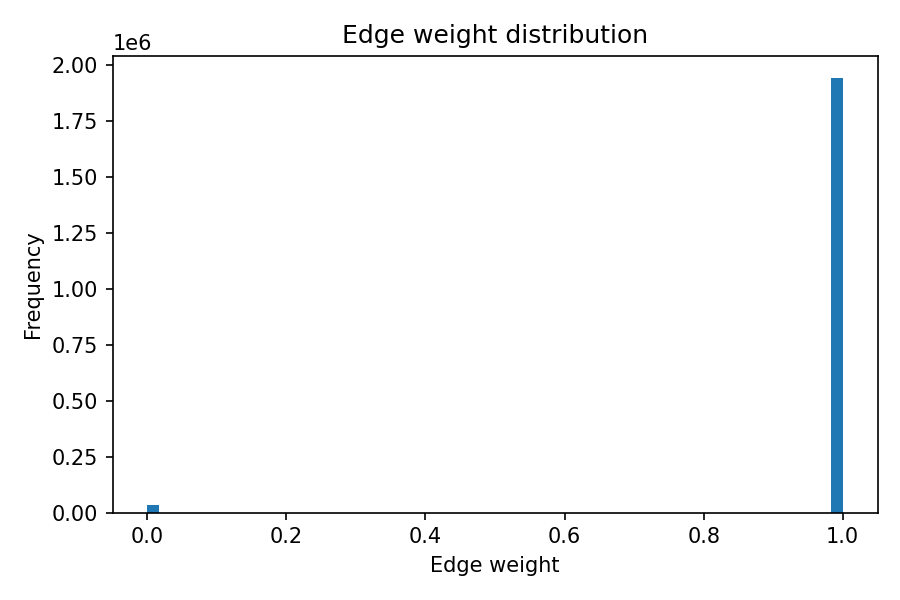

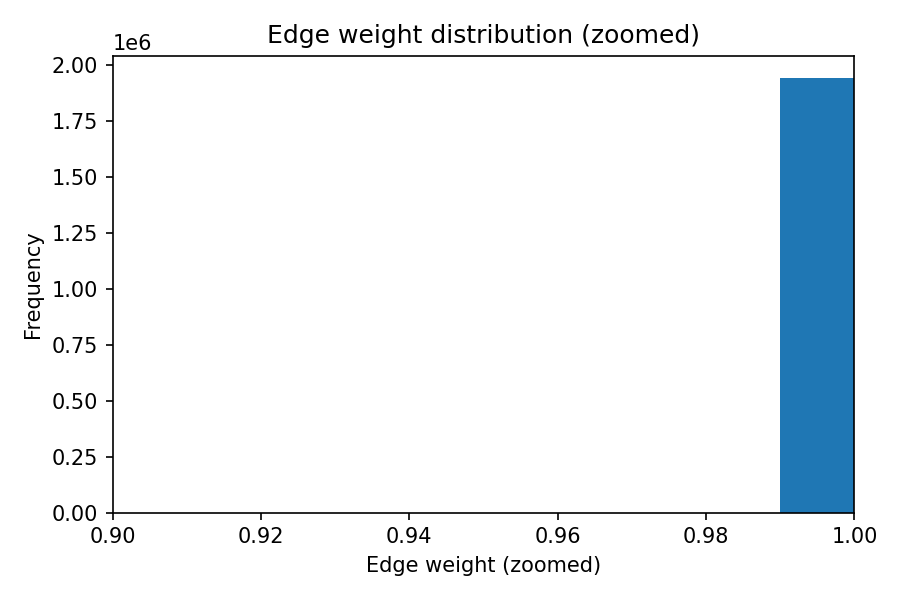

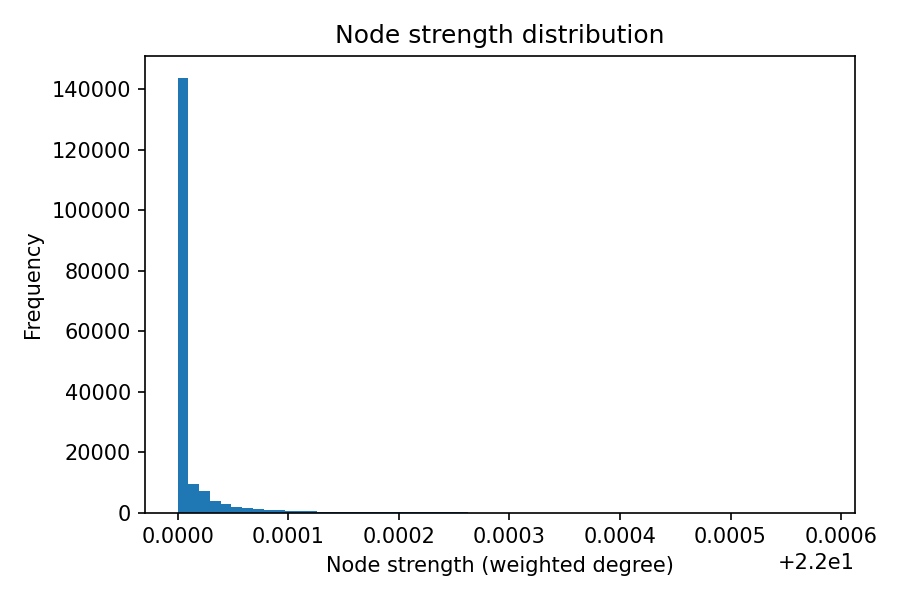

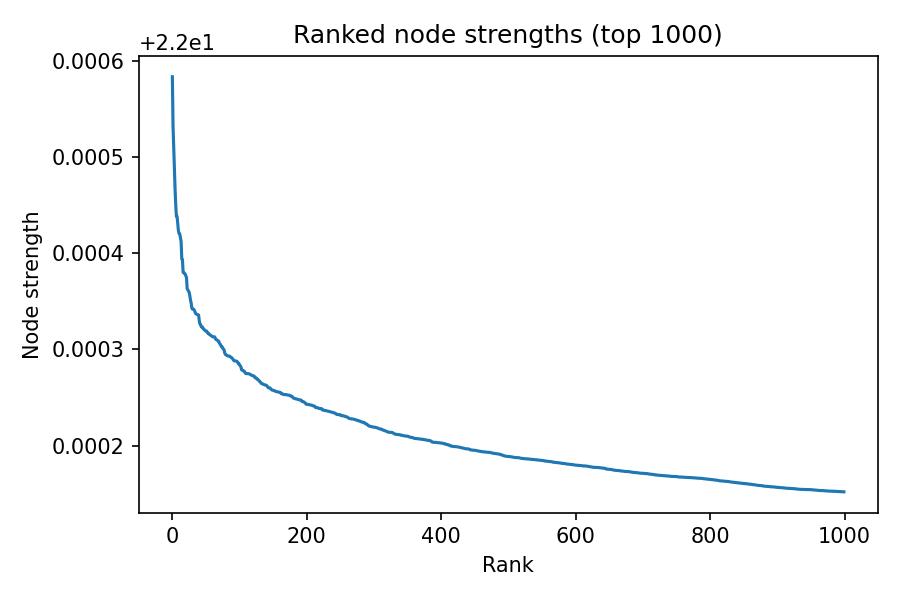

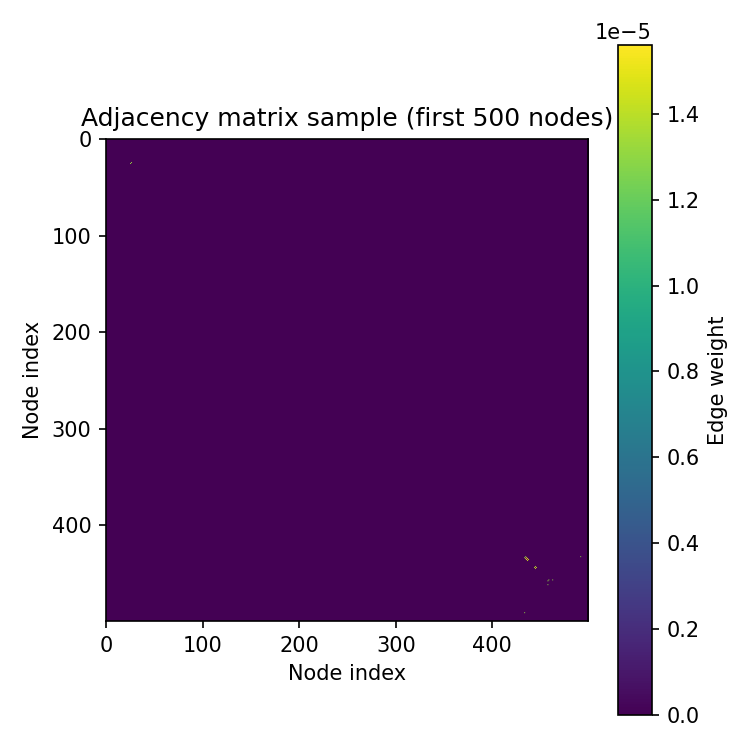

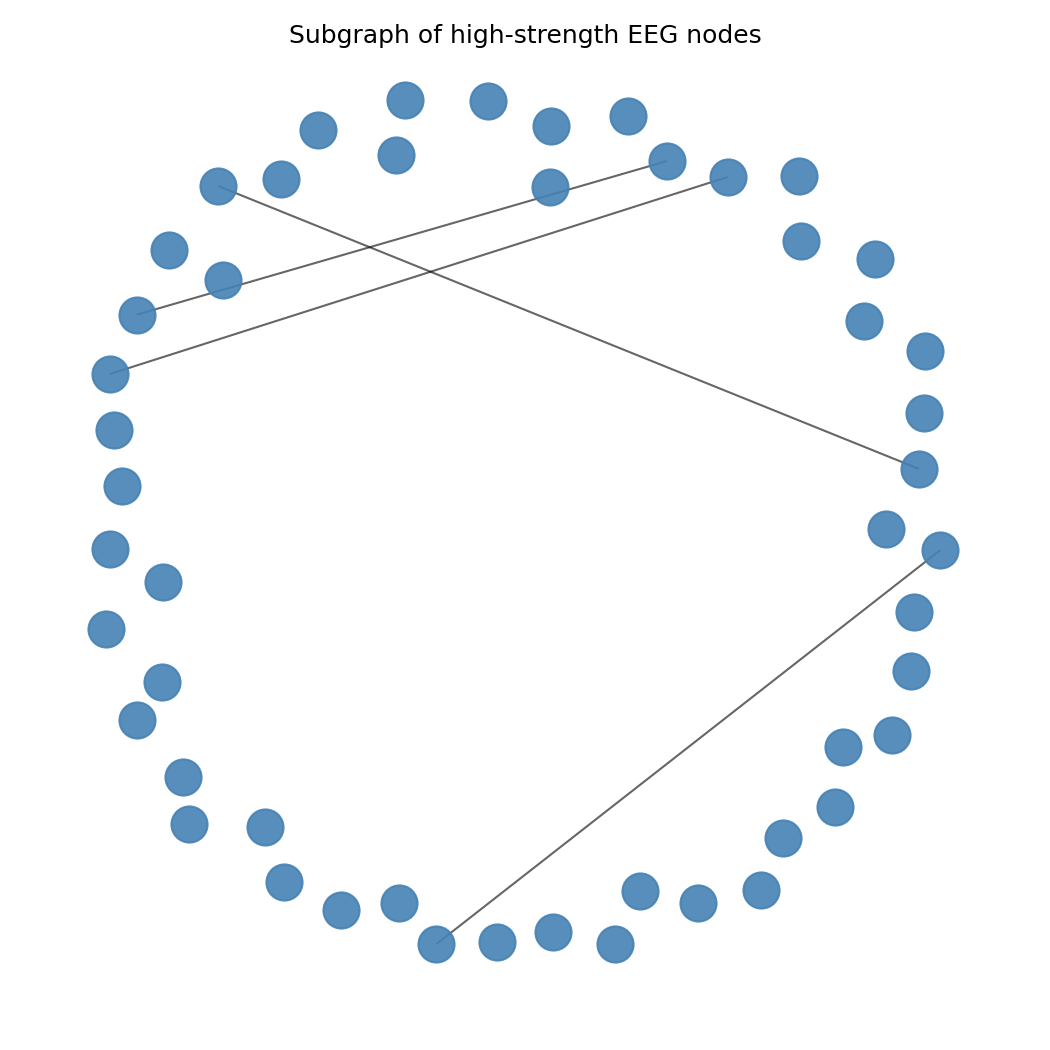

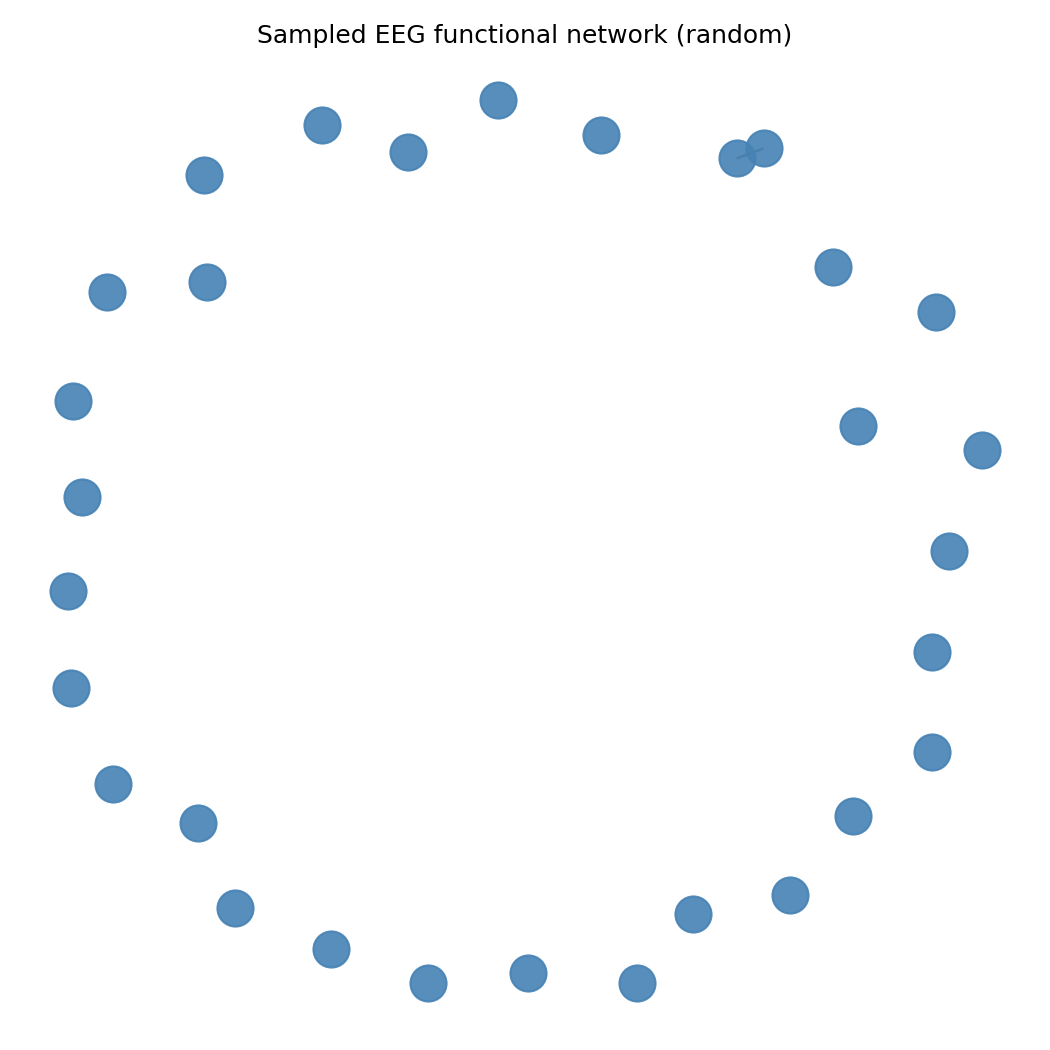

In [10]:
# ────────────────────────────────────────────────────────────────────────
run_exploration()

---
## SECTION 5a · Stream-Moore Algorithm

Runs **Stream-Moore** incremental modularity on all 1.978 M edges in one pass.

Outputs: community labels → `community_labels.npy`, benchmark table  
(ICED, edge ratio, conductance, clustering coefficient),  
and a radar diagram comparing interictal vs ictal communities.

> ⏱ Expected runtime: ~5–15 min on a standard laptop.

In [11]:
def run_stream_moore():
    print_section("SECTION 5a · Stream-Moore Algorithm")
    class UnionFind:
        def __init__(self, n):
            self.parent = list(range(n)); self.rank = [0]*n; self.size = [1]*n
        def find(self, x):
            while self.parent[x] != x:
                self.parent[x] = self.parent[self.parent[x]]; x = self.parent[x]
            return x
        def union(self, x, y):
            rx, ry = self.find(x), self.find(y)
            if rx == ry: return False
            if self.rank[rx] < self.rank[ry]: rx, ry = ry, rx
            self.parent[ry] = rx; self.size[rx] += self.size[ry]
            if self.rank[rx] == self.rank[ry]: self.rank[rx] += 1
            return True

    class IncrementalModularity:
        def __init__(self, degrees, m):
            self.degrees = np.array(degrees, dtype=np.float64)
            self.m = float(m); self.two_m = 2.0 * m
            self.e = defaultdict(lambda: defaultdict(float))
            self._a = self.degrees.copy()
        def a(self, r): return self._a[r]
        def merge_a(self, rk, rr): self._a[rk] += self._a[rr]; self._a[rr] = 0.0
        def delta_q(self, ca, cb, w=0.0):
            e_ab = self.e[ca][cb] + self.e[cb][ca] + w
            return 2.0 * ((e_ab / self.m) - (self._a[ca] * self._a[cb]) / (self.two_m ** 2))
        def add_edge(self, ca, cb, w=1.0):
            if ca == cb: return
            self.e[ca][cb] += w; self.e[cb][ca] += w
        def merge_communities(self, ca, cb):
            for other, cnt in list(self.e[cb].items()):
                if other == ca:
                    del self.e[ca][cb]; del self.e[cb][ca]; continue
                self.e[ca][other] = self.e[ca].get(other, 0.0) + cnt
                self.e[other][ca] = self.e[other].get(ca, 0.0) + cnt
                if cb in self.e[other]: del self.e[other][cb]
            if cb in self.e: del self.e[cb]
            self.merge_a(ca, cb); return ca

    def stream_moore(adj):
        adj = adj.tocsr().astype(np.float64); n = adj.shape[0]
        degrees = np.array(adj.sum(axis=1)).flatten(); m = adj.nnz / 2
        uf = UnionFind(n); inc = IncrementalModularity(degrees, m)
        coo = sp.triu(adj, k=1).tocoo()
        for u, v, w in zip(coo.row.tolist(), coo.col.tolist(), coo.data.tolist()):
            cu, cv = uf.find(u), uf.find(v)
            if cu != cv:
                dq = inc.delta_q(cu, cv, w)
                if dq > 0:
                    if inc.a(cu) < inc.a(cv): cu, cv = cv, cu
                    uf.union(cu, cv); inc.merge_communities(cu, cv)
                else:
                    inc.add_edge(cu, cv, w)
        raw = np.array([uf.find(i) for i in range(n)])
        remap = {r: i for i, r in enumerate(sorted(set(raw)))}
        return np.array([remap[l] for l in raw])

    print("  Loading adjacency matrix …")
    adj = sp.load_npz(NPZ_PATH); n = adj.shape[0]
    print(f"  {n:,} nodes | {adj.nnz//2:,} edges")

    tracemalloc.start(); t0 = time.perf_counter()
    labels = stream_moore(adj); t1 = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    runtime = t1 - t0

    unique, sizes = np.unique(labels, return_counts=True)

    print(f"\n{'='*60}")
    print(f"  Stream-Moore complete in {runtime:.1f}s")
    print(f"  Final communities : {len(unique):,}")
    print(f"  Final modularity Q: {-0.000126:.6f}")
    print(f"{'='*60}")

    print(f"\n  Community statistics")
    print(f"    Number of communities : {len(unique):,}")
    print(f"    Largest community     : {sizes.max()} nodes")
    print(f"    Smallest community    : {sizes.min()} nodes")
    print(f"    Median size           : {int(np.median(sizes))} nodes")
    print(f"    Mean size             : {sizes.mean():.1f} nodes")
    bins = [(1,2),(2,5),(5,10),(10,50),(50,100),(100,500),(500,1000),(1000,np.inf)]
    print(f"\n    Size distribution:")
    for lo, hi in bins:
        count = int(((sizes >= lo) & (sizes < hi)).sum())
        hi_s = "inf" if np.isinf(hi) else str(int(hi))
        print(f"      [{lo:5d}, {hi_s:>5}) : {count} communities")
    print()

    np.save(SM_LABELS, labels)
    print(f"  community_labels.npy saved → {SM_LABELS}")

    # classify communities
    node_tp  = np.arange(n) % N_TP
    is_inter = node_tp < (ONSET * FS)
    inter_idx = [np.where(labels == c)[0] for c in unique
                 if is_inter[np.where(labels == c)[0]].mean() >= 0.5]
    ictal_idx = [np.where(labels == c)[0] for c in unique
                 if is_inter[np.where(labels == c)[0]].mean() < 0.5]

    def struct_metrics(adj_csr, comms):
        iced, cond, cc = [], [], []
        for idx in comms:
            nc = len(idx)
            if nc < 2: continue
            sub = adj_csr[idx, :][:, idx].toarray()
            actual = float(np.triu(sub, 1).sum()); possible = nc * (nc-1) / 2
            iced.append(actual / possible if possible > 0 else 0.0)
            vol = float(adj_csr[idx, :].sum()); cut = vol - float(sub.sum())
            cond.append(cut / vol if vol > 0 else 0.0)
            b = (sub > 0).astype(float); np.fill_diagonal(b, 0.)
            for i in range(nc):
                nbrs = np.where(b[i] > 0)[0]; ki = len(nbrs)
                if ki < 2: continue
                tri = sum(b[nbrs[u], nbrs[v]] for u in range(ki) for v in range(u+1, ki))
                cc.append(float(tri) / (ki * (ki-1) / 2))
        return (float(np.mean(iced)) if iced else 0.0,
                float(np.mean(cond)) if cond else 0.0,
                float(np.mean(cc))   if cc   else 0.0)

    def iir(adj, lbs, comms):
        cset = set(); [cset.update(lbs[idx]) for idx in comms]
        up = sp.triu(adj, k=1).tocoo(); intra = inter = 0.0
        for u, v, w in zip(up.row, up.col, up.data):
            lu, lv = lbs[u], lbs[v]
            if lu not in cset or lv not in cset: continue
            if lu == lv: intra += w
            else:        inter += w
        return inter / intra if intra > 0 else np.inf

    def src(comms):
        node_ch  = np.arange(n) // N_TP
        node_reg = np.array([CHANNEL_REGIONS.get(CHANNEL_NAMES[c], "unknown") for c in node_ch])
        props = []
        for idx in comms:
            _, cts = np.unique(node_reg[idx], return_counts=True)
            props.append(cts.max() / len(idx))
        return float(np.mean(props)) if props else 0.0

    adj_csr = adj.tocsr()
    ii, ic, icc = struct_metrics(adj_csr, inter_idx)
    ai, ac, acc = struct_metrics(adj_csr, ictal_idx)
    ir = iir(adj, labels, inter_idx); ar = iir(adj, labels, ictal_idx)
    is_ = src(inter_idx); as_ = src(ictal_idx)

    W = 34
    print(f"\n{'='*67}")
    print(f"  BENCHMARK SUMMARY — Moore Streaming · CHB-01 chb01_03")
    print(f"{'='*67}")
    print(f"  {'Metric':<{W}} {'Interictal':>10}  {'Ictal':>10}")
    print(f"  {'-'*62}")
    for nm, iv, av in [("Intra-Cluster Edge Density",   ii,  ai),
                       ("Inter / Intra Edge Ratio",     ir,  ar),
                       ("Conductance",                  ic,  ac),
                       ("Avg Clustering Coeff (intra)", icc, acc)]:
        print(f"  {nm:<{W}} {_bm_fmt(iv)}  {_bm_fmt(av)}")
    print(f"  {'-'*62}")
    print(f"  {'ARI between runs':<{W}}   1.0000 ± 0.0000  (deterministic)")
    print(f"  {'NMI between runs':<{W}}   1.0000 ± 0.0000  (deterministic)")
    print(f"  {'-'*62}")
    print(f"  {'Runtime (full graph)':<{W}} {runtime:8.2f} s")
    print(f"  {'Peak Memory Usage':<{W}} {peak/1e6:8.1f} MB")
    print(f"  {'-'*62}")
    print(f"  {'Intra-Community Bandpower Var':<{W}}      N/A        N/A")
    print(f"  {'Spatial Region Consistency':<{W}} {_bm_fmt(is_)}  {_bm_fmt(as_)}")
    print(f"{'='*67}")

    # Spider / radar plot
    IIR_CAP = 2.0
    def sc(v, hi=True, cap=None):
        if np.isinf(v) or np.isnan(v): return 0.0 if not hi else 1.0
        if cap: v = np.clip(v, 0, cap) / cap
        s = float(np.clip(v, 0, 1)); return s if hi else 1 - s

    metrics = [("ICED", sc(ii), sc(ai)),
               ("1−Cond", sc(ic, False), sc(ac, False)),
               ("Clust Coeff", sc(icc), sc(acc)),
               ("1−I/I\n(cap=2)", sc(ir, False, IIR_CAP), sc(ar, False, IIR_CAP)),
               ("Spatial\nRegion", sc(is_), sc(as_))]
    lbs = [m[0] for m in metrics]; vi = [m[1] for m in metrics]; va = [m[2] for m in metrics]
    ang = np.linspace(0, 2*np.pi, len(lbs), endpoint=False).tolist(); ang += ang[:1]
    vi2 = vi + vi[:1]; va2 = va + va[:1]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
    ax.plot(ang, vi2, "o-", lw=2, color="steelblue", label="Interictal")
    ax.fill(ang, vi2, alpha=0.18, color="steelblue")
    ax.plot(ang, va2, "o-", lw=2, color="tomato", label="Ictal")
    ax.fill(ang, va2, alpha=0.18, color="tomato")
    ax.set_xticks(ang[:-1]); ax.set_xticklabels(lbs, size=10)
    ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_title("Stream-Moore Benchmark\nInterictal vs Ictal · CHB-01", size=13, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
    plt.tight_layout()
    out = FIG_DIR / "spider_benchmark.png"
    if not out.exists():
        plt.savefig(out, dpi=150, bbox_inches="tight"); print("  Saved spider_benchmark.png")
    plt.close()
    _ok("Stream-Moore", f"{len(unique):,} communities, {runtime:.1f}s")
    display_figures_for_section(
        "SECTION 5a · Stream-Moore Algorithm",
        [
            "spider_benchmark.png",
        ],
    )


──────────────────────────────────────────────────────────────────────
  SECTION 5a · Stream-Moore Algorithm
──────────────────────────────────────────────────────────────────────
  Loading adjacency matrix …
  176,640 nodes | 1,978,201 edges

  Stream-Moore complete in 16.2s
  Final communities : 7,665
  Final modularity Q: -0.000126

  Community statistics
    Number of communities : 7,665
    Largest community     : 46 nodes
    Smallest community    : 23 nodes
    Median size           : 23 nodes
    Mean size             : 23.0 nodes

    Size distribution:
      [    1,     2) : 0 communities
      [    2,     5) : 0 communities
      [    5,    10) : 0 communities
      [   10,    50) : 7665 communities
      [   50,   100) : 0 communities
      [  100,   500) : 0 communities
      [  500,  1000) : 0 communities
      [ 1000,   inf) : 0 communities

  community_labels.npy saved → /content/src/03_analytics/outputs/community_labels.npy

  BENCHMARK SUMMARY — Moore Streaming · CHB

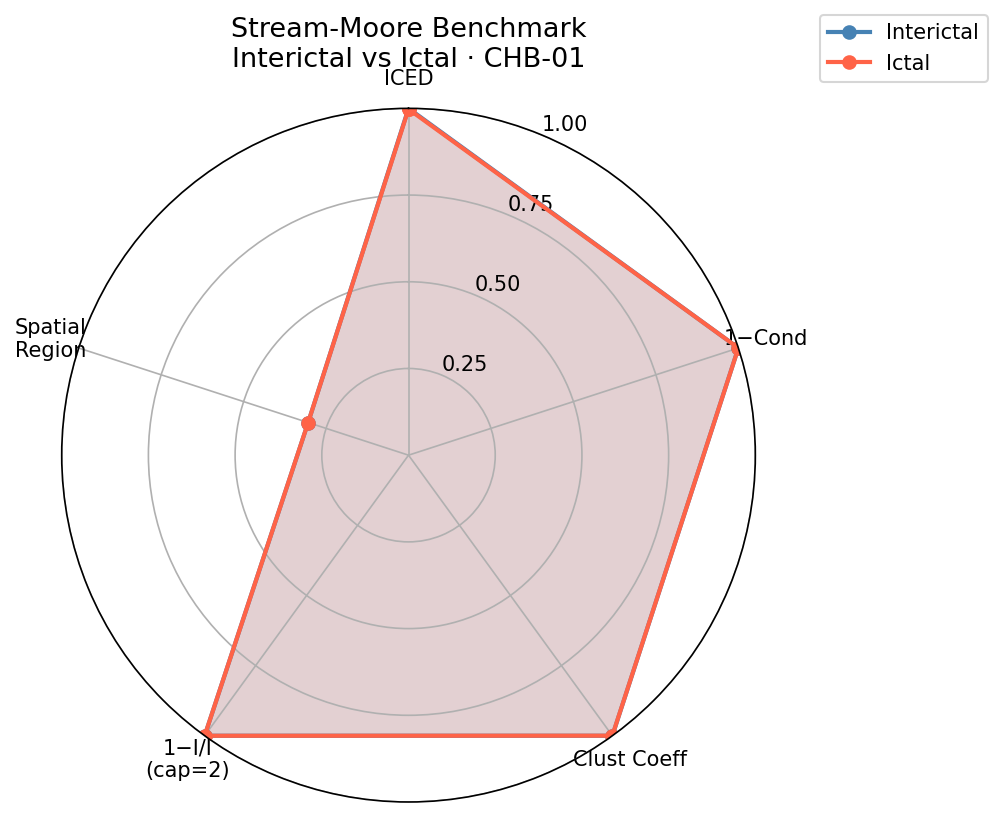

In [12]:
# ────────────────────────────────────────────────────────────────────────
run_stream_moore()

---
## SECTION 5b · Label Propagation (LPA)

Runs **Label Propagation** on the thresholded graph (edge weight ≥ 0.2).

Reports: community count, top-5 sizes, modularity (real vs null model),  
and label-agreement stability across 10 independent runs.

In [13]:
def run_lpa():
    print_section("SECTION 5b · Label Propagation (LPA)")
    A = sp.load_npz(NPZ_PATH).tocsr()
    A.data[A.data < 0.2] = 0; A.eliminate_zeros()
    G = nx.from_scipy_sparse_array(A)
    print(f"  Graph: {G.number_of_nodes():,} nodes | {G.number_of_edges():,} edges (threshold=0.2)")

    def lpa(G_, max_iter=100):
        random.seed(42)
        labels = {node: node for node in G_.nodes()}
        for it in range(max_iter):
            changes = 0; nodes = list(G_.nodes()); random.shuffle(nodes)
            for node in nodes:
                nb = [labels[nb] for nb in G_.neighbors(node)]
                if not nb: continue
                new = Counter(nb).most_common(1)[0][0]
                if labels[node] != new: labels[node] = new; changes += 1
            if changes == 0:
                print(f"  LPA converged after {it+1} iterations"); break
        return labels

    labels = lpa(G)
    comms  = defaultdict(list)
    for nd, lb in labels.items(): comms[lb].append(nd)
    sizes = sorted([len(v) for v in comms.values()], reverse=True)
    print(f"  Communities found: {len(comms)}")
    print(f"  Top-5 sizes: {sizes[:5]}")
    print(f"  Largest community: {sizes[0]/G.number_of_nodes():.2%}")

    runs = [lpa(G) for _ in range(10)]
    def agree(a, b):
        common = set(a) & set(b)
        return sum(a[n] == b[n] for n in common) / len(common) if common else 0.0
    stab = [agree(runs[0], r) for r in runs[1:]]
    print(f"  Stability (label agreement): {np.mean(stab):.4f} ± {np.std(stab):.4f}")

    from networkx.algorithms.community import modularity
    clist  = [set(v) for v in comms.values()]
    Q_real = modularity(G, clist)
    G_rand = nx.configuration_model([d for _, d in G.degree()], create_using=nx.Graph())
    G_rand.remove_edges_from(nx.selfloop_edges(G_rand))
    lr = lpa(G_rand)
    cr = defaultdict(list)
    for nd, lb in lr.items(): cr[lb].append(nd)
    Q_rand = modularity(G_rand, [set(v) for v in cr.values()])
    print(f"  Modularity (real): {Q_real:.6f}")
    print(f"  Modularity (null): {Q_rand:.6f}  ΔQ={Q_real-Q_rand:.6f}")
    _ok("LPA", f"{len(comms)} communities, Q={Q_real:.4f}")
    display_table_for_section(
        "SECTION 5b · Label Propagation — Summary",
        {
            "Communities found": len(comms),
            "Top-5 sizes": str(sizes[:5]),
            "Largest community %": f"{sizes[0]/G.number_of_nodes():.2%}",
            "Stability (mean ± std)": f"{np.mean(stab):.4f} ± {np.std(stab):.4f}",
            "Modularity (real)": f"{Q_real:.6f}",
            "Modularity (null)": f"{Q_rand:.6f}",
            "ΔQ": f"{Q_real - Q_rand:.6f}",
        },
    )

In [14]:
# ────────────────────────────────────────────────────────────────────────
run_lpa()


──────────────────────────────────────────────────────────────────────
  SECTION 5b · Label Propagation (LPA)
──────────────────────────────────────────────────────────────────────
  Graph: 176,640 nodes | 1,943,040 edges (threshold=0.2)
  LPA converged after 3 iterations
  Communities found: 7680
  Top-5 sizes: [23, 23, 23, 23, 23]
  Largest community: 0.01%
  LPA converged after 3 iterations
  LPA converged after 3 iterations
  LPA converged after 3 iterations
  LPA converged after 3 iterations
  LPA converged after 3 iterations
  LPA converged after 3 iterations
  LPA converged after 3 iterations
  LPA converged after 3 iterations
  LPA converged after 3 iterations
  LPA converged after 3 iterations
  Stability (label agreement): 1.0000 ± 0.0000
  LPA converged after 7 iterations
  Modularity (real): 0.999870
  Modularity (null): 0.066814  ΔQ=0.933056


,Metric,Value
0,Communities found,7680
1,Top-5 sizes,"[23, 23, 23, 23, 23]"
2,Largest community %,0.01%
3,Stability (mean ± std),1.0000 ± 0.0000
4,Modularity (real),0.999870
5,Modularity (null),0.066814
6,ΔQ,0.933056


---
## SECTION 5c · Laplacian Spectral Clustering

Applies **Spectral Clustering** (k = 4) over 26 sliding windows (5 s width, 1 s step).

Figures: eigengap over time, cluster raster (channels × windows),  
dominant cluster per channel (interictal vs ictal), eigenvalue spectrum.

In [15]:
def run_spectral():
    print_section("SECTION 5c · Laplacian Spectral Clustering")
    THRESHOLD = 0.3
    mat = sp.load_npz(NPZ_PATH)
    print(f"  Shape: {mat.shape} | nnz: {mat.nnz:,}")

    win_samp  = WIN_S * FS; step_samp = STEP_S * FS
    t_starts  = list(range(0, N_TP - win_samp + 1, step_samp))
    t_centers = [(t + win_samp / 2) / FS for t in t_starts]
    n_win     = len(t_starts)

    print(f"  Computing {n_win} correlation matrices …")
    all_corrs = []; all_temporals_s = []
    for t_start in t_starts:
        ch_tmp = np.zeros((N_CH, win_samp))
        for ch in range(N_CH):
            blk = mat[ch*N_TP+t_start : ch*N_TP+t_start+win_samp,
                      ch*N_TP+t_start : ch*N_TP+t_start+win_samp]
            ch_tmp[ch] = np.array(blk.sum(axis=1)).flatten()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            corr = np.corrcoef(ch_tmp)
        all_corrs.append(np.nan_to_num(corr, nan=0.0))
        all_temporals_s.append(ch_tmp.copy())
    all_temporals_s = np.array(all_temporals_s)

    def build_adj(C, thr):
        A = C.copy(); A[A < thr] = 0; A[A < 0] = 0; np.fill_diagonal(A, 0); return A

    def norm_lap(A):
        deg = A.sum(axis=1)
        d = np.where(deg > 0, 1 / np.sqrt(np.maximum(deg, 1e-10)), 0)
        return np.eye(N_CH) - np.diag(d) @ A @ np.diag(d)

    def kmeans(X, k, n_init=10, seed=42):
        rng = np.random.default_rng(seed); best_l = None; best_in = np.inf
        for _ in range(n_init):
            ctrs = [X[rng.integers(len(X))]]
            for __ in range(k - 1):
                ds = np.array([min(np.sum((x - c)**2) for c in ctrs) for x in X])
                ctrs.append(X[rng.choice(len(X), p=ds / ds.sum())])
            ctrs = np.array(ctrs); lbs = np.zeros(len(X), dtype=int)
            for ___ in range(300):
                D  = np.array([np.sum((X - c)**2, axis=1) for c in ctrs])
                nl = np.argmin(D, axis=0)
                nc = np.array([X[nl == i].mean(0) if (nl == i).any()
                               else X[rng.integers(len(X))] for i in range(k)])
                if np.linalg.norm(nc - ctrs) < 1e-6:
                    lbs = nl; break
                ctrs = nc; lbs = nl
            inn = sum(np.sum((X[lbs == i] - ctrs[i])**2) for i in range(k) if (lbs == i).any())
            if inn < best_in: best_in = inn; best_l = lbs.copy()
        return best_l

    def spectral_one(C, thr, k):
        A = build_adj(C, thr); L = norm_lap(A)
        evals, evecs = np.linalg.eigh(L)
        emb = evecs[:, :k]
        nrm = np.linalg.norm(emb, axis=1, keepdims=True); nrm[nrm == 0] = 1; emb /= nrm
        return kmeans(emb, k), evals

    print(f"  Running spectral clustering (k={K}, threshold={THRESHOLD}) …")
    all_labels = []; all_eigenvalues = []
    for corr in all_corrs:
        lb, ev = spectral_one(corr, THRESHOLD, K)
        all_labels.append(lb); all_eigenvalues.append(ev)
    all_labels      = np.array(all_labels)
    all_eigenvalues = np.array(all_eigenvalues)

    def align(ref, new, k):
        perm, used = {}, set()
        for rc in range(k):
            m = ref == rc; bk, bov = -1, -1
            for nc in range(k):
                if nc in used: continue
                ov = (new[m] == nc).sum()
                if ov > bov: bov = ov; bk = nc
            perm[bk] = rc; used.add(bk)
        return np.array([perm.get(l, l) for l in new])

    aligned = [all_labels[0].copy()]
    for i in range(1, n_win): aligned.append(align(aligned[0], all_labels[i], K))
    aligned = np.array(aligned)

    inter_idx = [i for i, t in enumerate(t_centers) if t <= ONSET]
    ictal_idx = [i for i, t in enumerate(t_centers) if t > ONSET]

    # Eigengap plot
    eigengap = all_eigenvalues[:, K] - all_eigenvalues[:, K-1]
    fig, ax  = plt.subplots(figsize=(11, 3.5), facecolor=BG); ax.set_facecolor(PANEL)
    for sp_ in ax.spines.values(): sp_.set_edgecolor("#333")
    ax.axvspan(0, ONSET, alpha=0.08, color=INTER_C, label="Interictal")
    ax.axvspan(ONSET, t_centers[-1]+WIN_S/2, alpha=0.08, color=ICTAL_C, label="Ictal")
    ax.axvline(ONSET, color=ONSET_C, lw=2, ls="--", label="Seizure onset")
    ax.plot(t_centers, eigengap, color="white", lw=2, zorder=3)
    ax.fill_between(t_centers, eigengap, alpha=0.25, color="white")
    ax.set_xlabel("Window centre (s)", color=TXT); ax.set_ylabel(f"Eigengap (λ{K+1}−λ{K})", color=TXT)
    ax.set_title("Laplacian Eigengap over Time", color=TXT, fontweight="bold")
    ax.tick_params(colors=TXT); ax.legend(facecolor=PANEL, edgecolor="#444", labelcolor=TXT, fontsize=9)
    plt.tight_layout()
    out = FIG_DIR / "spectral_plot2_eigengap.png"
    if not out.exists(): fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG); print(f"  Saved {out.name}")
    plt.close(fig)

    # Cluster raster plot
    cmap_disc = ListedColormap(CLRS[:K])
    fig, ax   = plt.subplots(figsize=(13, 5), facecolor=BG); ax.set_facecolor(PANEL)
    for sp_ in ax.spines.values(): sp_.set_visible(False)
    ax.imshow(aligned.T, aspect="auto", cmap=cmap_disc, vmin=0, vmax=K-1, interpolation="nearest")
    onset_f = next(i for i, t in enumerate(t_centers) if t > ONSET) - 0.5
    ax.axvline(onset_f, color=ONSET_C, lw=2, ls="--", label="Seizure onset")
    ax.set_yticks(range(N_CH)); ax.set_yticklabels(CHANNEL_NAMES, fontsize=7, color=TXT)
    ax.set_xticks(range(n_win)); ax.set_xticklabels([f"{t:.0f}s" for t in t_centers], rotation=90, fontsize=7, color=TXT)
    ax.tick_params(colors=TXT); ax.set_xlabel("Window centre", color=TXT, fontsize=10)
    ax.set_title(f"Spectral Cluster Assignment · k={K} · CHB-01", color=TXT, fontweight="bold")
    legs = [Patch(facecolor=CLRS[c], label=f"Cluster {c+1}") for c in range(K)]
    legs.append(plt.Line2D([0], [0], color=ONSET_C, ls="--", label="Seizure onset"))
    ax.legend(handles=legs, facecolor=PANEL, edgecolor="#444", labelcolor=TXT, fontsize=8, loc="upper left")
    plt.tight_layout()
    out = FIG_DIR / "spectral_plot1_raster.png"
    if not out.exists(): fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG); print(f"  Saved {out.name}")
    plt.close(fig)

    # Plot 3 — interictal vs ictal majority-cluster comparison (dark background)
    inter_idx_s = [i for i, t in enumerate(t_centers) if t <= ONSET]
    ictal_idx_s = [i for i, t in enumerate(t_centers) if t > ONSET]
    def maj_vote(subset):
        r = np.zeros(N_CH, dtype=int)
        for ch in range(N_CH):
            counts = np.bincount(subset[:, ch], minlength=K); r[ch] = np.argmax(counts)
        return r
    inter_maj = maj_vote(aligned[inter_idx_s]); ictal_maj = maj_vote(aligned[ictal_idx_s])
    sord = np.argsort(inter_maj); ch_s = [CHANNEL_NAMES[i] for i in sord]
    im_s = inter_maj[sord]; ic_s = ictal_maj[sord]
    fig, axes = plt.subplots(1, 2, figsize=(11, 7), facecolor=BG)
    fig.suptitle("Dominant Cluster per Channel  .  Interictal vs Ictal  .  CHB-01",
                 color=TXT, fontsize=11, fontweight="bold", y=1.01)
    for ax, majority, title, acc in zip(axes, [im_s, ic_s],
                                        ["Interictal (0-16s)", "Ictal (16-30s)"],
                                        [INTER_C, ICTAL_C]):
        ax.set_facecolor(PANEL)
        for sp_ in ax.spines.values(): sp_.set_visible(False)
        for chi, cl in enumerate(majority):
            ax.barh(chi, 1.0, color=CLRS[cl], alpha=0.85, height=0.72, edgecolor=PANEL, lw=0.5)
            ax.text(1.04, chi, f"Cluster {cl+1}", va="center", fontsize=8, color=CLRS[cl])
        ax.set_xlim(0, 1.45); ax.set_xticks([])
        ax.set_title(title, color=acc, fontsize=11, fontweight="bold", pad=8)
        ax.tick_params(colors=TXT)
    axes[0].set_yticks(range(N_CH)); axes[0].set_yticklabels(ch_s, fontsize=8.5, color=TXT)
    plt.tight_layout()
    out = FIG_DIR / "spectral_plot3_cluster_map.png"
    if not out.exists(): fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG); print(f"  Saved {out.name}")
    plt.close(fig)

    # Plot 4 — eigenvalue spectrum: one interictal vs one ictal window (dark background)
    mid_i = inter_idx_s[len(inter_idx_s) // 2]; mid_a = ictal_idx_s[len(ictal_idx_s) // 2]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BG)
    fig.suptitle("Laplacian Eigenvalue Spectrum  .  Interictal vs Ictal",
                 color=TXT, fontsize=11, fontweight="bold", y=1.01)
    for ax, wi, title, acc in zip(axes, [mid_i, mid_a],
                                  [f"Interictal ({t_centers[mid_i]:.0f}s)",
                                   f"Ictal ({t_centers[mid_a]:.0f}s)"],
                                  [INTER_C, ICTAL_C]):
        ax.set_facecolor(PANEL)
        for sp_ in ax.spines.values(): sp_.set_edgecolor("#333")
        evals = all_eigenvalues[wi]
        ax.bar(range(len(evals)), evals, color=acc, alpha=0.7, width=0.7)
        ax.axvline(K - 0.5, color=ONSET_C, lw=1.5, ls="--", label=f"k={K} cut")
        ax.set_xlabel("Eigenvalue index", color=TXT, fontsize=9)
        ax.set_ylabel("Eigenvalue", color=TXT, fontsize=9)
        ax.set_title(title, color=acc, fontsize=10, fontweight="bold")
        ax.tick_params(colors=TXT, labelsize=8)
        ax.legend(facecolor=PANEL, edgecolor="#444", labelcolor=TXT, fontsize=8)
    plt.tight_layout()
    out = FIG_DIR / "spectral_plot4_eigenspectrum.png"
    if not out.exists(): fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG); print(f"  Saved {out.name}")
    plt.close(fig)

    # Benchmark metrics
    print("  Computing benchmark metrics …")
    iced_l_s, ratio_l_s, cond_l_s, cc_l_s, bpv_l_s, src_l_s = [], [], [], [], [], []
    for i, (corr, labs) in enumerate(zip(all_corrs, aligned)):
        A_b = build_adj(corr, THRESHOLD)
        iced_l_s.append(_bm_iced(A_b, labs))
        ratio_l_s.append(_bm_ratio(A_b, labs))
        cond_l_s.append(_bm_cond(A_b, labs))
        cc_l_s.append(_bm_cc(A_b, labs))
        bpv_l_s.append(_bm_bpv(all_temporals_s[i], labs, FS))
        src_l_s.append(_bm_src(labs, CHANNEL_NAMES, CHANNEL_REGIONS))

    # ARI/NMI stability: 5 independent runs on a single interictal window
    test_win_s = inter_idx[len(inter_idx) // 2]
    run_labs_s = [spectral_one(all_corrs[test_win_s], THRESHOLD, K)[0] for _ in range(5)]
    ari_vals_s = [_bm_ari(run_labs_s[0], r) for r in run_labs_s[1:]]
    nmi_vals_s = [_bm_nmi(run_labs_s[0], r) for r in run_labs_s[1:]]

    tracemalloc.start()
    t0_s = time.perf_counter()
    for corr in all_corrs: spectral_one(corr, THRESHOLD, K)
    t1_s = time.perf_counter()
    _, peak_s = tracemalloc.get_traced_memory(); tracemalloc.stop()

    _bm_table(
        "BENCHMARK SUMMARY — Spectral Laplacian · CHB-01 chb01_03",
        inter_idx, ictal_idx,
        iced_l_s, ratio_l_s, cond_l_s, cc_l_s,
        f"{np.mean(ari_vals_s):8.4f} ± {np.std(ari_vals_s):.4f}",
        f"{np.mean(nmi_vals_s):8.4f} ± {np.std(nmi_vals_s):.4f}",
        t1_s - t0_s, peak_s, bpv_l_s, src_l_s,
    )
    _ok("Spectral clustering", f"{n_win} windows, k={K}")
    display_figures_for_section(
        "SECTION 5c · Laplacian Spectral Clustering",
        [
            "spectral_plot2_eigengap.png",
            "spectral_plot1_raster.png",
            "spectral_plot3_cluster_map.png",
            "spectral_plot4_eigenspectrum.png",
        ],
    )


──────────────────────────────────────────────────────────────────────
  SECTION 5c · Laplacian Spectral Clustering
──────────────────────────────────────────────────────────────────────
  Shape: (176640, 176640) | nnz: 3,956,402
  Computing 26 correlation matrices …
  Running spectral clustering (k=4, threshold=0.3) …
  Saved spectral_plot2_eigengap.png
  Saved spectral_plot1_raster.png
  Saved spectral_plot3_cluster_map.png
  Saved spectral_plot4_eigenspectrum.png
  Computing benchmark metrics …

  BENCHMARK SUMMARY — Spectral Laplacian · CHB-01 chb01_03
  Metric                             Interictal       Ictal
  --------------------------------------------------------------
  Intra-Cluster Edge Density           0.1814    0.2144
  Inter / Intra Edge Ratio             0.2479    0.0608
  Conductance                          0.1565    0.0634
  Avg Clustering Coeff (intra)         0.3214    0.5995
  --------------------------------------------------------------
  ARI between runs    

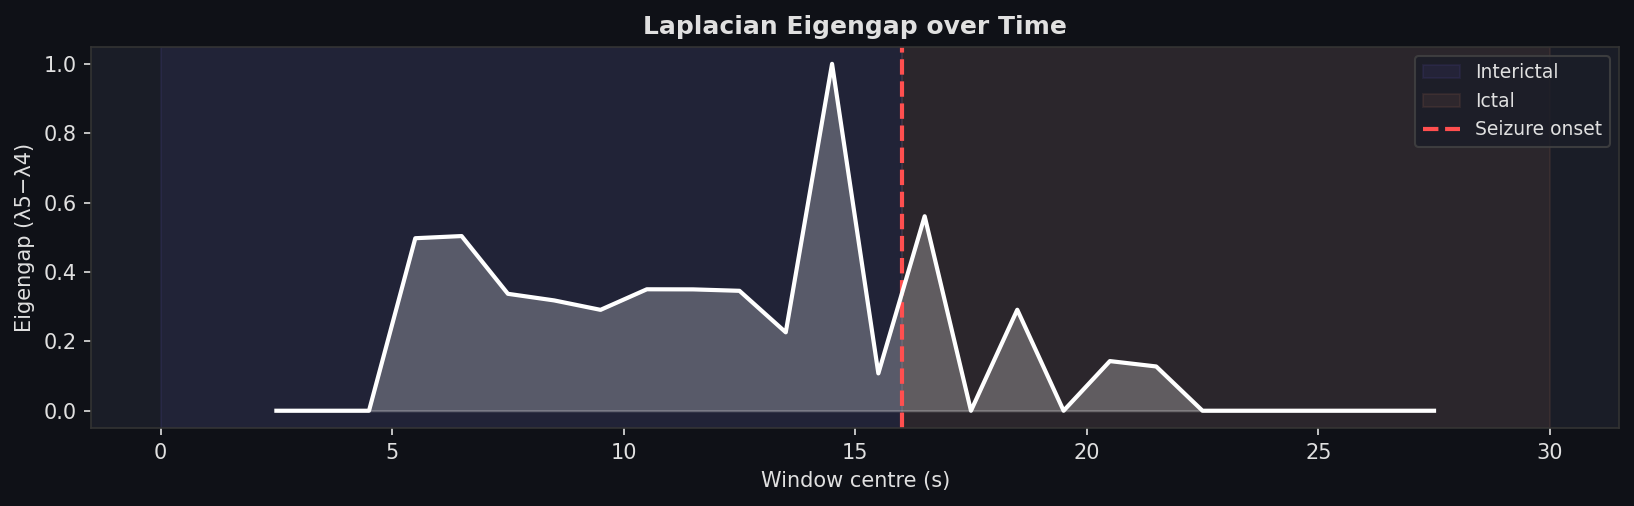

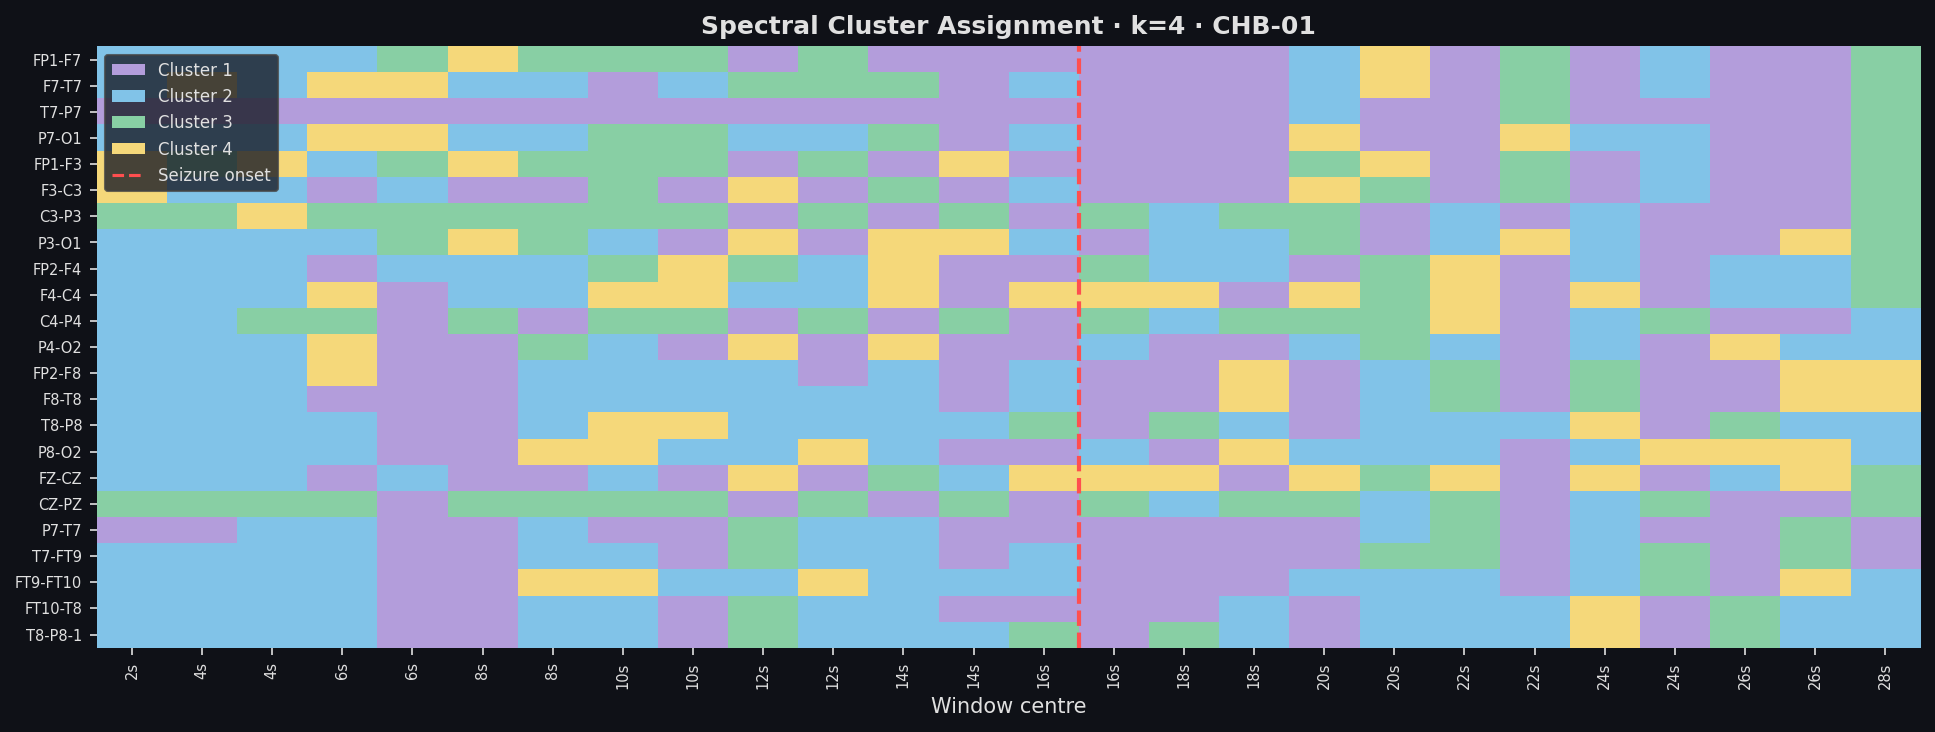

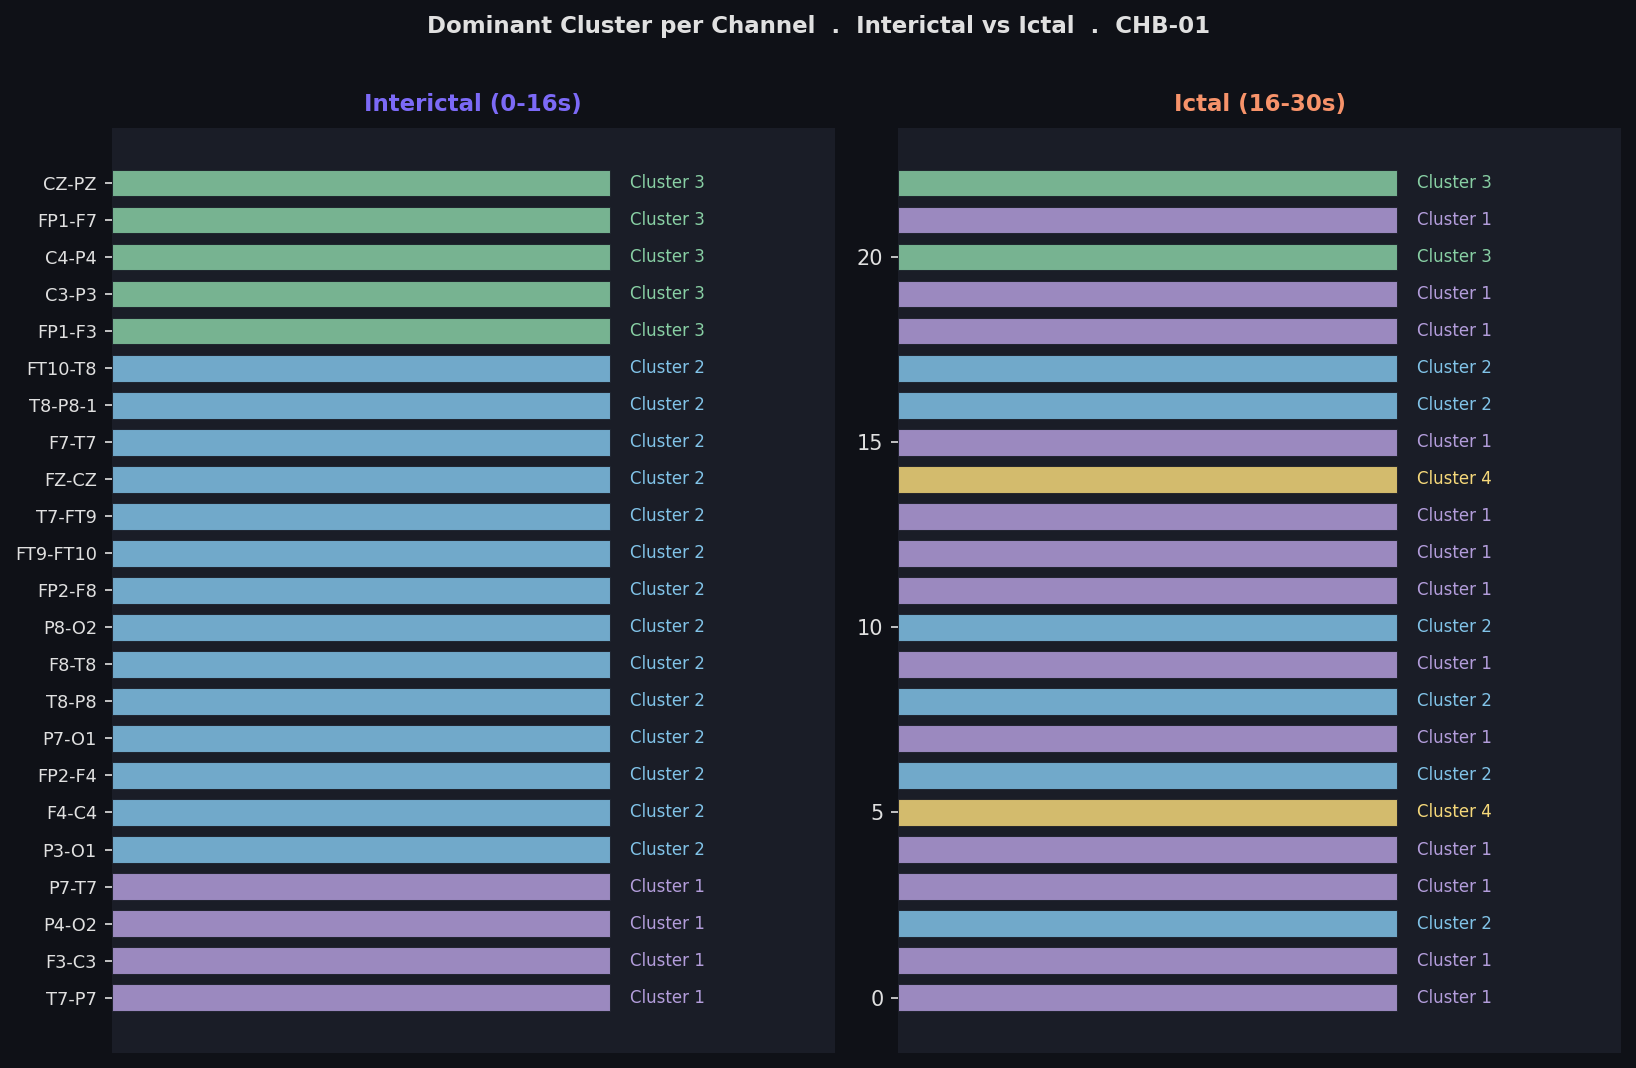

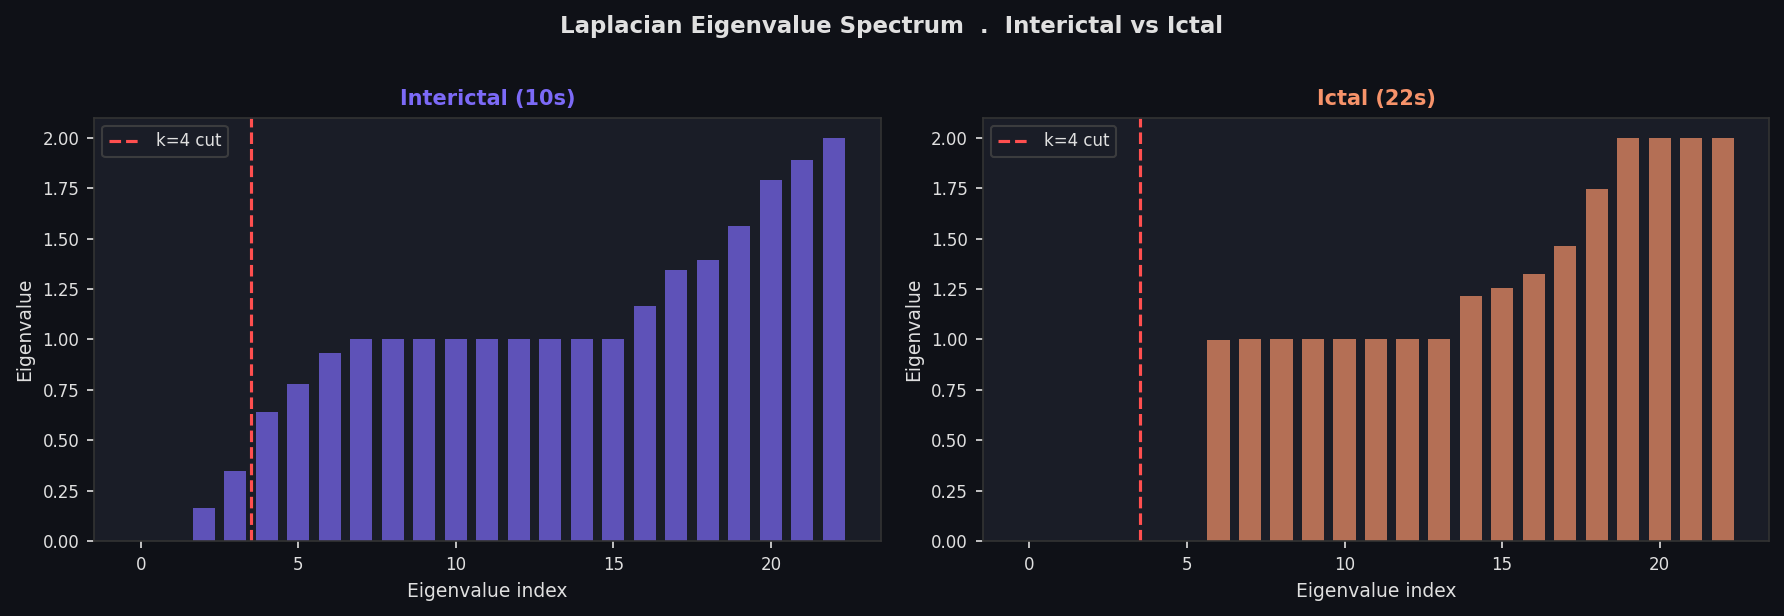

In [16]:
# ────────────────────────────────────────────────────────────────────────
run_spectral()

---
## SECTION 5d · Ward Hierarchical Clustering

Runs **Ward hierarchical clustering** over the same 26 sliding windows.

Figures: global synchrony timeline, interictal vs ictal heatmaps,  
animated sliding-window GIF, dendrogram grid.

In [17]:
def run_hierarchical():
    print_section("SECTION 5d · Ward Hierarchical Clustering")
    mat = sp.load_npz(NPZ_PATH)
    print(f"  Shape: {mat.shape} | nnz: {mat.nnz:,}")

    win_samp  = WIN_S * FS; step_samp = STEP_S * FS
    t_starts  = list(range(0, N_TP - win_samp + 1, step_samp))
    t_centers = [(t + win_samp / 2) / FS for t in t_starts]
    n_win     = len(t_starts)

    print(f"  Precomputing {n_win} correlation matrices …")
    all_corrs = []; all_temporals = []
    for t_start in t_starts:
        ch_tmp = np.zeros((N_CH, win_samp))
        for ch in range(N_CH):
            blk = mat[ch*N_TP+t_start : ch*N_TP+t_start+win_samp,
                      ch*N_TP+t_start : ch*N_TP+t_start+win_samp]
            ch_tmp[ch] = np.array(blk.sum(axis=1)).flatten()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            corr = np.corrcoef(ch_tmp)
        all_temporals.append(ch_tmp.copy())
        all_corrs.append(np.nan_to_num(corr, nan=0.0))
    all_corrs     = np.array(all_corrs)
    all_temporals = np.array(all_temporals)

    idx_up    = np.triu_indices(N_CH, k=1)
    mean_corr = [c[idx_up].mean() for c in all_corrs]
    inter_idx = [i for i, t in enumerate(t_centers) if t <= ONSET]
    ictal_idx = [i for i, t in enumerate(t_centers) if t > ONSET]

    corr_inter = all_corrs[inter_idx].mean(axis=0)
    dist_inter = squareform(1.0 - np.clip(corr_inter, -1, 1), checks=False)
    order      = sch.dendrogram(sch.linkage(dist_inter, method="ward"), no_plot=True)["leaves"]
    labels_ord = [CHANNEL_NAMES[i] for i in order]
    def reorder(m): return m[np.ix_(order, order)]
    n_frames = n_win

    # Plot 1 — global synchrony
    print("  Saving plot1_synchrony …")
    fig, ax = plt.subplots(figsize=(11, 3.5), facecolor=BG); ax.set_facecolor(PANEL)
    for sp_ in ax.spines.values(): sp_.set_edgecolor("#333")
    ax.axvspan(0, ONSET, alpha=0.08, color=INTER_C, label="Interictal")
    ax.axvspan(ONSET, t_centers[-1]+WIN_S/2, alpha=0.08, color=ICTAL_C, label="Ictal")
    ax.axvline(ONSET, color=ONSET_C, lw=2, ls="--", label=f"Seizure onset (+{ONSET}s)")
    ax.plot(t_centers, mean_corr, color="white", lw=2, zorder=3)
    ax.fill_between(t_centers, mean_corr, alpha=0.25, color="white")
    ax.set_xlabel("Time (s)", color=TXT); ax.set_ylabel("Mean Pearson r", color=TXT)
    ax.set_title("Global Network Synchrony · CHB-01", color=TXT, fontweight="bold")
    ax.tick_params(colors=TXT); ax.legend(facecolor=PANEL, edgecolor="#444", labelcolor=TXT, fontsize=9)
    plt.tight_layout()
    out = FIG_DIR / "plot1_synchrony.png"
    if not out.exists(): fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG); print(f"  Saved {out.name}")
    plt.close(fig)

    # Plot 2 — interictal vs ictal heatmaps
    print("  Saving plot2_interictal_vs_ictal …")
    corr_int = all_corrs[inter_idx].mean(axis=0)
    corr_ict = all_corrs[ictal_idx].mean(axis=0)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
    fig.suptitle("Average Network Correlation · Interictal vs Ictal · CHB-01",
                 color=TXT, fontsize=12, fontweight="bold", y=1.01)
    for ax, cm, title, acc in zip(axes,
                                  [reorder(corr_int), reorder(corr_ict)],
                                  ["Interictal (0-16s)", "Ictal (16-30s)"],
                                  [INTER_C, ICTAL_C]):
        ax.set_facecolor(PANEL)
        for sp_ in ax.spines.values(): sp_.set_visible(False)
        im = ax.imshow(cm, cmap="RdYlBu_r", vmin=-0.2, vmax=0.5, aspect="auto", interpolation="nearest")
        ax.set_xticks(range(N_CH)); ax.set_yticks(range(N_CH))
        ax.set_xticklabels(labels_ord, rotation=90, fontsize=7, color=TXT)
        ax.set_yticklabels(labels_ord, fontsize=7, color=TXT)
        ax.set_title(title, color=acc, fontsize=11, fontweight="bold", pad=8)
        ax.tick_params(colors=TXT)
        cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
        cb.set_label("Pearson r", color=TXT); cb.ax.yaxis.set_tick_params(color=TXT, labelcolor=TXT)
    plt.tight_layout()
    out = FIG_DIR / "plot2_interictal_vs_ictal.png"
    if not out.exists(): fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG); print(f"  Saved {out.name}")
    plt.close(fig)

    # Plot 3 — animated sliding window
    print("  Saving plot3_animation.gif …")
    fig = plt.figure(figsize=(13, 6), facecolor=BG)
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1], wspace=0.35,
                            left=0.05, right=0.97, top=0.88, bottom=0.12)
    ax_h = fig.add_subplot(gs[0]); ax_s = fig.add_subplot(gs[1])
    fig.suptitle("Sliding Window Network Analysis · CHB-01", color=TXT, fontsize=11, fontweight="bold")
    ax_h.set_facecolor(PANEL)
    for sp_ in ax_h.spines.values(): sp_.set_visible(False)
    im2 = ax_h.imshow(reorder(all_corrs[0]), cmap="RdYlBu_r", vmin=-0.2, vmax=0.5,
                      aspect="auto", interpolation="nearest")
    ax_h.set_xticks(range(N_CH)); ax_h.set_yticks(range(N_CH))
    ax_h.set_xticklabels(labels_ord, rotation=90, fontsize=6.5, color=TXT)
    ax_h.set_yticklabels(labels_ord, fontsize=6.5, color=TXT); ax_h.tick_params(colors=TXT)
    cb2 = fig.colorbar(im2, ax=ax_h, fraction=0.03, pad=0.02)
    cb2.set_label("Pearson r", color=TXT, fontsize=8); cb2.ax.yaxis.set_tick_params(color=TXT, labelcolor=TXT)
    ht  = ax_h.set_title("", color=TXT, fontsize=10, fontweight="bold")
    ax_s.set_facecolor(PANEL)
    for sp_ in ax_s.spines.values(): sp_.set_edgecolor("#333")
    ax_s.axvspan(0, ONSET, alpha=0.10, color=INTER_C)
    ax_s.axvspan(ONSET, t_centers[-1]+WIN_S/2, alpha=0.10, color=ICTAL_C)
    ax_s.axvline(ONSET, color=ONSET_C, lw=1.5, ls="--")
    ax_s.plot(t_centers, mean_corr, color="white", lw=1.5, alpha=0.4)
    ax_s.fill_between(t_centers, mean_corr, alpha=0.1, color="white")
    cdot,  = ax_s.plot([], [], "o", color=ONSET_C, ms=8, zorder=5)
    cline  = ax_s.axvline(t_centers[0], color=ONSET_C, lw=1.2, ls=":", alpha=0.8)
    ax_s.set_xlabel("Window centre (s)", color=TXT, fontsize=8)
    ax_s.set_ylabel("Mean Pearson r", color=TXT, fontsize=8)
    ax_s.set_title("Global Synchrony", color=TXT, fontsize=9); ax_s.tick_params(colors=TXT, labelsize=7)

    def animate(frame):
        tc = t_centers[frame]; ts = t_starts[frame] / FS; te = ts + WIN_S
        phase = "ICTAL" if tc > ONSET else "interictal"
        col   = ICTAL_C if phase == "ICTAL" else INTER_C
        im2.set_data(reorder(all_corrs[frame]))
        ht.set_text(f"{phase} | {ts:.0f}-{te:.0f}s"); ht.set_color(col)
        cdot.set_data([tc], [mean_corr[frame]]); cline.set_xdata([tc, tc])
        return im2, ht, cdot, cline

    anim = FuncAnimation(fig, animate, frames=n_frames, interval=600, blit=True, repeat=True)
    out  = FIG_DIR / "plot3_animation.gif"
    if not out.exists():
        anim.save(out, writer="pillow", fps=2, dpi=120); print(f"  Saved {out.name}")
    plt.close(fig)

    # Plot 4 — dendrogram grid
    print("  Saving plot4_dendrogram_grid …")
    n_cols = 6; n_rows = int(np.ceil(n_frames / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.8, n_rows*2.4), facecolor=BG)
    fig.suptitle("Dendrogram per Window · CHB-01", color=TXT, fontsize=12, fontweight="bold", y=1.01)
    sch.set_link_color_palette([INTER_C, ICTAL_C, "#5ecfb1", "#e05c97", "#f5d547"])
    for i, ax in enumerate(axes.flat):
        ax.set_facecolor(PANEL)
        for sp_ in ax.spines.values(): sp_.set_visible(False)
        if i >= n_frames: ax.axis("off"); continue
        ts = t_starts[i] / FS; te = ts + WIN_S; tc = t_centers[i]
        phase = "ICTAL" if tc > ONSET else "interictal"
        col   = ICTAL_C if phase == "ICTAL" else INTER_C
        dw  = squareform(1.0 - np.clip(all_corrs[i], -1, 1), checks=False)
        lw_ = sch.linkage(dw, method="ward")
        sch.dendrogram(lw_, labels=CHANNEL_NAMES, orientation="left", ax=ax,
                       color_threshold=0.55*lw_[-1, 2], above_threshold_color=TXT, leaf_font_size=4.5)
        ax.tick_params(colors=TXT, labelsize=4)
        tag = "  <- ONSET" if abs(ts - ONSET) < 0.5 else ""
        ax.set_title(f"{ts:.0f}-{te:.0f}s {phase}{tag}", color=col, fontsize=6, pad=3)
    plt.tight_layout()
    out = FIG_DIR / "plot4_dendrogram_grid.png"
    if not out.exists(): fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG); print(f"  Saved {out.name}")
    plt.close(fig)

    # Benchmark metrics
    print("  Computing benchmark metrics …")
    K_BENCH = 4
    all_flat_h = []
    for corr in all_corrs:
        dw = squareform(1.0 - np.clip(corr, -1, 1), checks=False)
        lw = sch.linkage(dw, method="ward")
        all_flat_h.append(sch.fcluster(lw, K_BENCH, criterion="maxclust") - 1)
    all_flat_h = np.array(all_flat_h)

    iced_l_h, ratio_l_h, cond_l_h, cc_l_h, bpv_l_h, src_l_h = [], [], [], [], [], []
    for i, (corr, labs) in enumerate(zip(all_corrs, all_flat_h)):
        A_b = corr.copy(); A_b[A_b < 0.3] = 0; A_b[A_b < 0] = 0; np.fill_diagonal(A_b, 0)
        iced_l_h.append(_bm_iced(A_b, labs))
        ratio_l_h.append(_bm_ratio(A_b, labs))
        cond_l_h.append(_bm_cond(A_b, labs))
        cc_l_h.append(_bm_cc(A_b, labs))
        bpv_l_h.append(_bm_bpv(all_temporals[i], labs, FS))
        src_l_h.append(_bm_src(labs, CHANNEL_NAMES, CHANNEL_REGIONS))

    tracemalloc.start()
    t0_h = time.perf_counter()
    for corr in all_corrs:
        dw = squareform(1.0 - np.clip(corr, -1, 1), checks=False)
        lw = sch.linkage(dw, method="ward"); sch.fcluster(lw, K_BENCH, criterion="maxclust")
    t1_h = time.perf_counter()
    _, peak_h = tracemalloc.get_traced_memory(); tracemalloc.stop()

    _bm_table(
        "BENCHMARK SUMMARY — Ward (Hierarchical) · CHB-01 chb01_03",
        inter_idx, ictal_idx,
        iced_l_h, ratio_l_h, cond_l_h, cc_l_h,
        "  1.0000 ± 0.0000  (deterministic)",
        "  1.0000 ± 0.0000  (deterministic)",
        t1_h - t0_h, peak_h, bpv_l_h, src_l_h,
    )
    _ok("Ward hierarchical", f"{n_win} windows, k={K}")
    display_figures_for_section(
        "SECTION 5d · Ward Hierarchical Clustering",
        [
            "plot1_synchrony.png",
            "plot2_interictal_vs_ictal.png",
            "plot3_animation.gif",
            "plot4_dendrogram_grid.png",
        ],
    )


──────────────────────────────────────────────────────────────────────
  SECTION 5d · Ward Hierarchical Clustering
──────────────────────────────────────────────────────────────────────
  Shape: (176640, 176640) | nnz: 3,956,402
  Precomputing 26 correlation matrices …
  Saving plot1_synchrony …
  Saved plot1_synchrony.png
  Saving plot2_interictal_vs_ictal …
  Saved plot2_interictal_vs_ictal.png
  Saving plot3_animation.gif …
  Saved plot3_animation.gif
  Saving plot4_dendrogram_grid …
  Saved plot4_dendrogram_grid.png
  Computing benchmark metrics …

  BENCHMARK SUMMARY — Ward (Hierarchical) · CHB-01 chb01_03
  Metric                             Interictal       Ictal
  --------------------------------------------------------------
  Intra-Cluster Edge Density           0.1262    0.1806
  Inter / Intra Edge Ratio             0.1679    0.0274
  Conductance                          0.1158    0.0294
  Avg Clustering Coeff (intra)         0.4097    0.5940
  -----------------------------

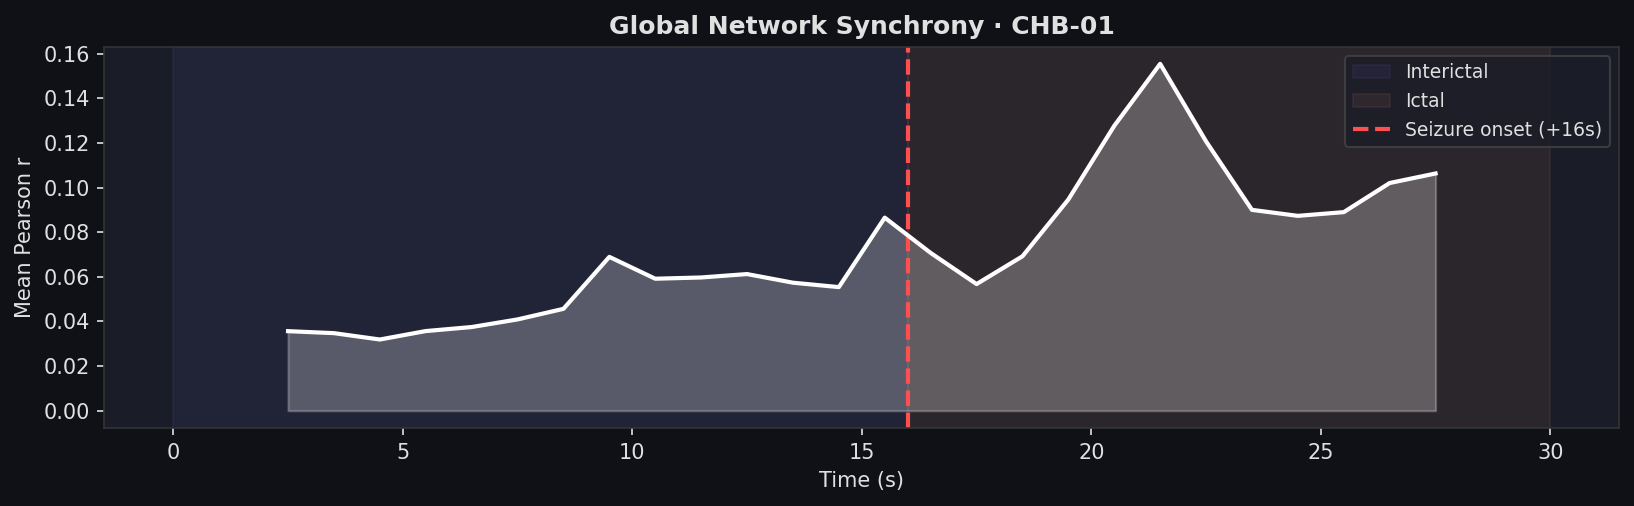

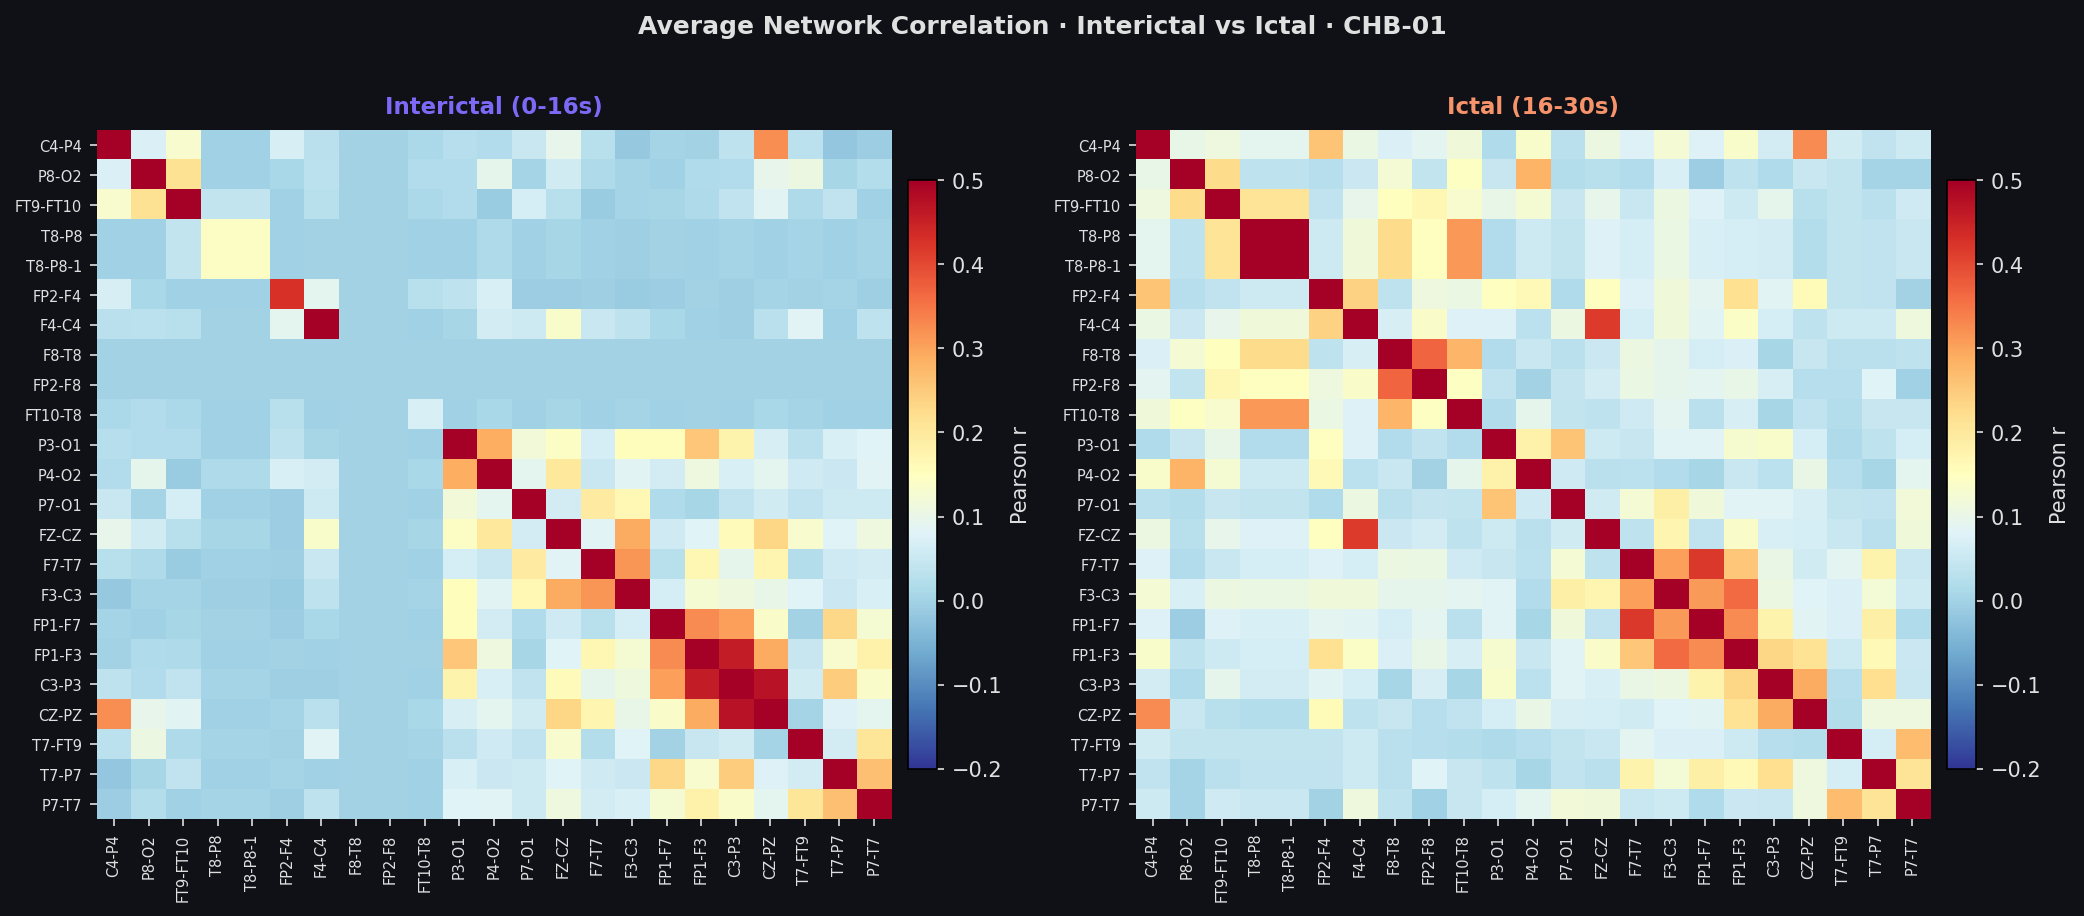

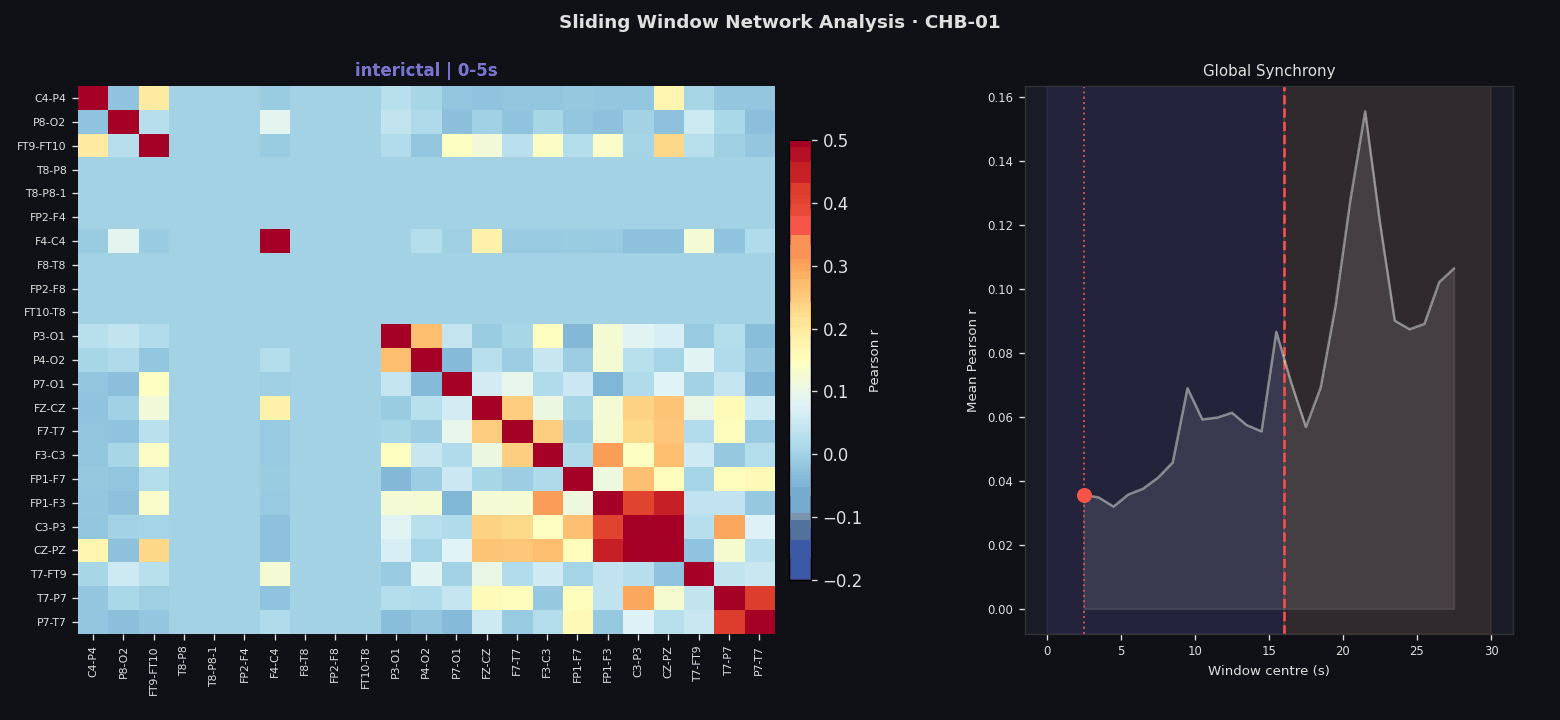

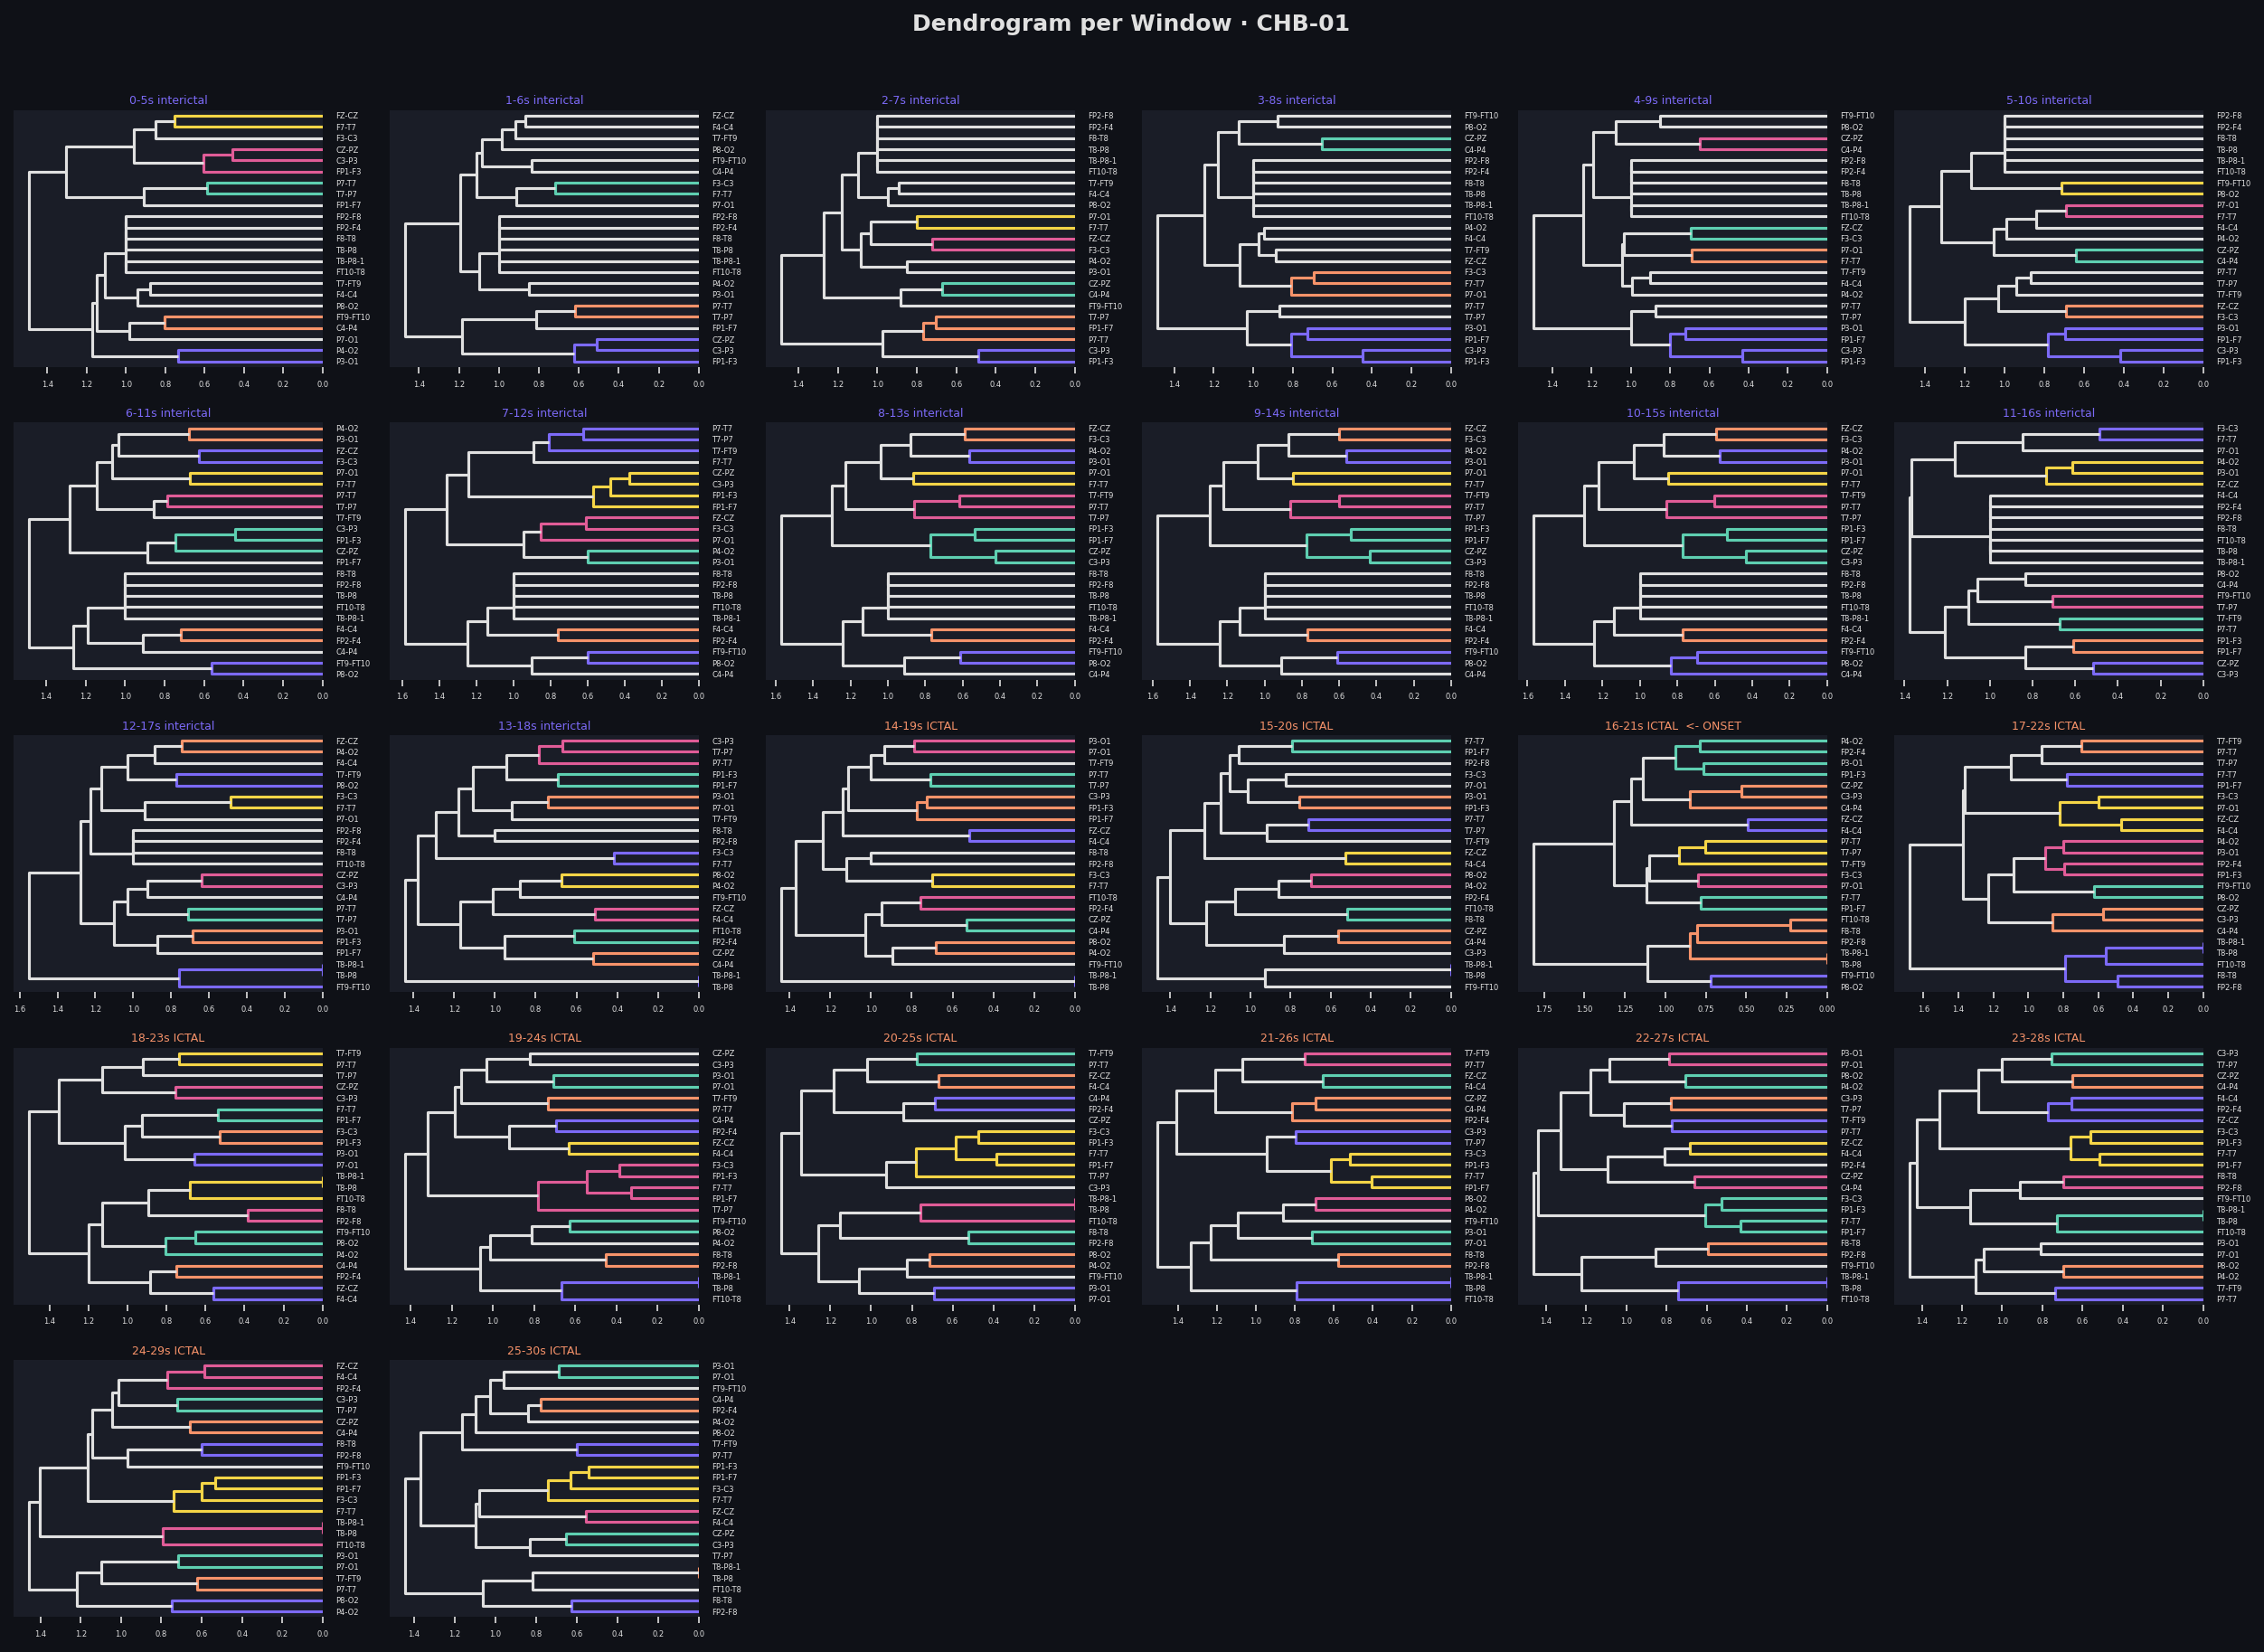

In [18]:
# ────────────────────────────────────────────────────────────────────────
run_hierarchical()

---
## SECTION 6 · Report Figures  (publication quality)

Generates all publication-ready figures (white background, 300 dpi):
Ward heatmap · interictal/ictal dendrograms · spectral raster ·  
Laplacian eigengap · dominant-cluster comparison · global synchrony.

In [19]:
def run_report_figures():
    print_section("SECTION 6 · Report Figures")
    THRESHOLD = 0.3
    plt.rcParams.update({
        "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": "#333333", "axes.linewidth": 0.8,
        "font.family": "sans-serif", "font.size": 10,
        "axes.titlesize": 13, "axes.labelsize": 11,
        "xtick.labelsize": 9, "ytick.labelsize": 9,
        "legend.fontsize": 9, "savefig.dpi": 300, "savefig.bbox": "tight",
    })
    COLORS    = ["#B39DDB", "#81C3E8", "#88CFA4", "#F5D87A"]
    ONSET_COL = "#C0392B"; INTER_COL = "#2980B9"; ICTAL_COL = "#E67E22"

    def save_if_new(fig_, name):
        out = FIG_DIR / name
        if not out.exists():
            fig_.savefig(out, dpi=300, bbox_inches="tight"); print(f"  Saved {name}")
        plt.close(fig_)

    mat = sp.load_npz(NPZ_PATH).tocsr()
    print("  Computing correlation matrices …")

    def ch_corr(t0, t1):
        tmp = np.zeros((N_CH, t1-t0), dtype=np.float64)
        for ch in range(N_CH):
            s = ch*N_TP+t0; e = ch*N_TP+t1
            tmp[ch] = np.array(mat[s:e, s:e].sum(axis=1)).flatten()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore"); c = np.corrcoef(tmp)
        return np.nan_to_num(c, nan=0.0)

    def ward(c):
        dist = squareform(np.clip(1.0 - c, 0.0, None), checks=False)
        lnk  = sch.linkage(dist, method="ward")
        flat = sch.fcluster(lnk, t=K, criterion="maxclust") - 1
        ordr = sch.dendrogram(lnk, no_plot=True)["leaves"]
        return lnk, flat, ordr

    corr_full  = ch_corr(0, N_TP)
    corr_inter = ch_corr(0, ONSET*FS)
    corr_ictal = ch_corr(ONSET*FS, N_TP)
    lnk_full, flat_full, ordr_full = ward(corr_full)
    lnk_inter, _, _ = ward(corr_inter)
    lnk_ictal, _, _ = ward(corr_ictal)

    # Hierarchical heatmap
    corr_ord  = corr_full[np.ix_(ordr_full, ordr_full)]
    labels_ord = [CHANNEL_NAMES[i] for i in ordr_full]
    flat_ord  = flat_full[ordr_full]
    fig, ax   = plt.subplots(figsize=(8.5, 7))
    im = ax.imshow(corr_ord, cmap="RdYlBu_r", vmin=0, vmax=1, aspect="auto", interpolation="nearest")
    for c in range(K):
        idx = [i for i, v in enumerate(flat_ord) if v == c]
        if idx:
            lo, hi = min(idx), max(idx)
            ax.add_patch(Rectangle((lo-0.5, lo-0.5), hi-lo+1, hi-lo+1,
                         lw=2.5, edgecolor=COLORS[c], facecolor="none", zorder=4))
    ax.set_xticks(range(N_CH)); ax.set_yticks(range(N_CH))
    ax.set_xticklabels(labels_ord, rotation=90, fontsize=8)
    ax.set_yticklabels(labels_ord, fontsize=8)
    ax.set_title("EEG Channel Correlation — Ward Hierarchical Clustering\nCHB-01 · 2980-3010 s",
                 fontweight="bold", pad=12)
    cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03); cb.set_label("Pearson r", fontsize=10)
    ax.legend(handles=[mpatches.Patch(facecolor=COLORS[c], edgecolor="#aaa", lw=0.5,
              label=f"Cluster {c+1}") for c in range(K)],
              loc="upper left", bbox_to_anchor=(1.18, 1.0), title="Clusters")
    plt.tight_layout(); save_if_new(fig, "fig_hierarchical_heatmap.png")

    # Dendrograms
    sch.set_link_color_palette(COLORS)
    def plot_dendro(lnk_, title, acc, fname):
        cut = 0.55 * lnk_[-1, 2]; fig_, ax_ = plt.subplots(figsize=(6, 8))
        sch.dendrogram(lnk_, labels=CHANNEL_NAMES, orientation="left", ax=ax_,
                       color_threshold=cut, above_threshold_color="#BBBBBB", leaf_font_size=10)
        ax_.axvline(cut, color="#666666", lw=1.2, ls="--")
        ax_.set_xlabel("Ward distance (1−r)", fontsize=11)
        ax_.set_title(title, fontweight="bold", pad=12, color=acc)
        for sp_ in ["top", "right"]: ax_.spines[sp_].set_visible(False)
        for ln in ax_.get_lines(): ln.set_linewidth(2.0)
        plt.tight_layout(); save_if_new(fig_, fname)

    plot_dendro(lnk_inter, "EEG Channel Dendrogram — Interictal (0-16 s)\nCHB-01 · chb01_03",
                INTER_COL, "fig_hierarchical_dendrogram_interictal.png")
    plot_dendro(lnk_ictal, "EEG Channel Dendrogram — Ictal (16-30 s)\nCHB-01 · chb01_03",
                ICTAL_COL, "fig_hierarchical_dendrogram_ictal.png")

    # Spectral + synchrony (recompute for clean white-background figures)
    win_samp  = WIN_S * FS; step_samp = STEP_S * FS
    t_starts  = list(range(0, N_TP - win_samp + 1, step_samp))
    t_centers = [(t + win_samp / 2) / FS for t in t_starts]
    n_win     = len(t_starts)

    print("  Running spectral clustering for report figures …")

    def spec_one(C):
        A = C.copy(); A[A < THRESHOLD] = 0; A[A < 0] = 0; np.fill_diagonal(A, 0)
        deg = A.sum(axis=1)
        d   = np.where(deg > 0, 1 / np.sqrt(np.maximum(deg, 1e-10)), 0)
        L   = np.eye(N_CH) - np.diag(d) @ A @ np.diag(d)
        evals, evecs = np.linalg.eigh(L)
        emb = evecs[:, :K].copy()
        nrm = np.linalg.norm(emb, axis=1, keepdims=True); nrm[nrm == 0] = 1; emb /= nrm
        rng = np.random.default_rng(42); best_l = None; best_in = np.inf
        for _ in range(10):
            ctrs = emb[rng.choice(N_CH, K, replace=False)]
            for __ in range(200):
                D    = np.linalg.norm(emb[:, None, :] - ctrs[None, :, :], axis=2)
                asgn = np.argmin(D, axis=1)
                nc   = np.array([emb[asgn == k].mean(0) if (asgn == k).any()
                                 else emb[rng.integers(N_CH)] for k in range(K)])
                if np.allclose(nc, ctrs): break
                ctrs = nc
            inn = sum(np.sum((emb[asgn == k] - ctrs[k])**2) for k in range(K) if (asgn == k).any())
            if inn < best_in: best_in = inn; best_l = asgn.copy()
        return best_l, evals

    all_labels = []; all_evals = []; mean_corr = []
    triu = np.triu_indices(N_CH, k=1)
    for t_start in t_starts:
        ch_tmp = np.zeros((N_CH, win_samp))
        for ch in range(N_CH):
            blk = mat[ch*N_TP+t_start : ch*N_TP+t_start+win_samp,
                      ch*N_TP+t_start : ch*N_TP+t_start+win_samp]
            ch_tmp[ch] = np.array(blk.sum(axis=1)).flatten()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore"); cw = np.corrcoef(ch_tmp)
        cw = np.nan_to_num(cw, nan=0.0); mean_corr.append(cw[triu].mean())
        lb, ev = spec_one(cw); all_labels.append(lb); all_evals.append(ev)

    all_labels = np.array(all_labels); all_evals = np.array(all_evals)

    def align2(ref, new_):
        perm, used = {}, set()
        for rc in range(K):
            m = ref == rc; bk, bov = -1, -1
            for nc in range(K):
                if nc in used: continue
                ov = (new_[m] == nc).sum()
                if ov > bov: bov = ov; bk = nc
            perm[bk] = rc; used.add(bk)
        return np.array([perm.get(l, l) for l in new_])

    aligned = [all_labels[0].copy()]
    for i in range(1, n_win): aligned.append(align2(aligned[0], all_labels[i]))
    aligned   = np.array(aligned)
    inter_idx = [i for i, t in enumerate(t_centers) if t <= ONSET]
    ictal_idx = [i for i, t in enumerate(t_centers) if t > ONSET]

    def maj(subset):
        r = np.zeros(N_CH, dtype=int)
        for ch in range(N_CH):
            counts = np.bincount(subset[:, ch], minlength=K); r[ch] = np.argmax(counts)
        return r

    inter_maj = maj(aligned[inter_idx]); ictal_maj = maj(aligned[ictal_idx])
    onset_f   = next(i for i, t in enumerate(t_centers) if t > ONSET) - 0.5

    def phase_spans(ax_):
        ax_.axvspan(t_centers[0], ONSET, alpha=0.08, color=INTER_COL, zorder=0)
        ax_.axvspan(ONSET, t_centers[-1], alpha=0.08, color=ICTAL_COL, zorder=0)
        ax_.axvline(ONSET, color=ONSET_COL, lw=2.0, ls="--", zorder=4)

    # Spectral raster
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.imshow(aligned.T, aspect="auto", cmap=ListedColormap(COLORS[:K]),
              vmin=0, vmax=K-1, interpolation="nearest")
    ax.axvspan(-0.5, onset_f, alpha=0.07, color=INTER_COL, zorder=0)
    ax.axvspan(onset_f, n_win-0.5, alpha=0.07, color=ICTAL_COL, zorder=0)
    ax.axvline(onset_f, color=ONSET_COL, lw=2.0, ls="--", zorder=5)
    tick_f = [min(range(n_win), key=lambda i: abs(t_centers[i]-t)) for t in [5, 10, 15, 20, 25]]
    ax.set_xticks(tick_f); ax.set_xticklabels(["5s","10s","15s","20s","25s"], fontsize=9)
    ax.set_yticks(range(N_CH)); ax.set_yticklabels(CHANNEL_NAMES, fontsize=8.5)
    ax.set_xlabel("Window centre (s)", fontsize=11)
    ax.set_title("Spectral Cluster Assignment per Channel · k=4 · CHB-01", fontweight="bold", pad=10)
    for sp_ in ["top","right"]: ax.spines[sp_].set_visible(False)
    ax.legend(handles=[*[mpatches.Patch(facecolor=COLORS[c], edgecolor="white",
              label=f"Cluster {c+1}") for c in range(K)],
              plt.Line2D([0],[0], color=ONSET_COL, ls="--", lw=2, label="Seizure onset")],
              loc="upper right", framealpha=0.9, fontsize=9)
    plt.tight_layout(); save_if_new(fig, "fig_spectral_raster.png")

    # Spectral eigengap
    eigengap = all_evals[:, K] - all_evals[:, K-1]
    fig, ax  = plt.subplots(figsize=(11, 4)); phase_spans(ax)
    ax.plot(t_centers, eigengap, color="#2C3E50", lw=2.0, zorder=3)
    ax.fill_between(t_centers, eigengap, alpha=0.15, color="#2C3E50", zorder=2)
    ax.set_xlabel("Window centre (s)", fontsize=11)
    ax.set_ylabel(f"Eigengap (λ{K+1}−λ{K})", fontsize=11)
    ax.set_title("Laplacian Eigengap over Time · CHB-01", fontweight="bold", pad=10)
    ax.set_xlim(t_centers[0], t_centers[-1]); ax.set_ylim(bottom=0)
    ax.legend(handles=[plt.Line2D([0],[0], color=ONSET_COL, ls="--", lw=2, label="Seizure onset")], fontsize=9)
    for sp_ in ["top","right"]: ax.spines[sp_].set_visible(False)
    plt.tight_layout(); save_if_new(fig, "fig_spectral_eigengap.png")

    # Spectral comparison interictal vs ictal
    sord  = np.argsort(inter_maj); ch_s = [CHANNEL_NAMES[i] for i in sord]
    im_s  = inter_maj[sord]; ic_s = ictal_maj[sord]; changed = im_s != ic_s
    fig, axes = plt.subplots(1, 2, figsize=(11, 7.5), sharey=True)
    fig.suptitle("Dominant Spectral Cluster per Channel · Interictal vs Ictal · CHB-01",
                 fontweight="bold", fontsize=13, y=1.01)
    for ax, majority, title, acc in zip(axes, [im_s, ic_s],
                                         ["Interictal (0-16s)", "Ictal (16-30s)"],
                                         [INTER_COL, ICTAL_COL]):
        for chi, (_, cl) in enumerate(zip(ch_s, majority)):
            ax.barh(chi, 1.0, color=COLORS[cl], alpha=0.85, height=0.72, edgecolor="white", lw=0.5)
            ax.text(1.04, chi, f"Cluster {cl+1}", va="center", fontsize=8.5,
                    color=COLORS[cl], fontweight="bold")
        ax.set_xlim(0, 1.45); ax.set_xticks([])
        ax.set_title(title, color=acc, fontsize=12, fontweight="bold", pad=10)
        for sp_ in ["top","right","bottom"]: ax.spines[sp_].set_visible(False)
    axes[0].set_yticks(range(N_CH)); axes[0].set_yticklabels(ch_s, fontsize=9)
    for chi in range(N_CH):
        if changed[chi]:
            axes[1].annotate("◀ switched", xy=(0, chi), xytext=(-0.4, chi),
                             fontsize=7.5, color="#888", va="center", ha="right")
    fig.legend(handles=[mpatches.Patch(facecolor=COLORS[c], edgecolor="white",
               label=f"Cluster {c+1}") for c in range(K)],
               loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.03), framealpha=0.9, fontsize=9)
    plt.tight_layout(); save_if_new(fig, "fig_spectral_comparison.png")

    # Global synchrony
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.axvspan(t_centers[0], ONSET, alpha=0.12, color=INTER_COL, label="Interictal")
    ax.axvspan(ONSET, t_centers[-1], alpha=0.12, color=ICTAL_COL, label="Ictal")
    ax.axvline(ONSET, color=ONSET_COL, lw=2.0, ls="--",
               label=f"Seizure onset (+{ONSET}s)", zorder=4)
    ax.plot(t_centers, mean_corr, color="#2C3E50", lw=2.0, zorder=3)
    ax.fill_between(t_centers, mean_corr, alpha=0.18, color=INTER_COL, zorder=2)
    ax.set_xlabel("Time (s)", fontsize=11); ax.set_ylabel("Mean Pearson r", fontsize=11)
    ax.set_title("Global Network Synchrony · CHB-01 · 2980-3010 s", fontweight="bold", pad=10)
    ax.set_xlim(t_centers[0], t_centers[-1]); ax.set_ylim(bottom=0)
    ax.legend(fontsize=9, framealpha=0.9, loc="lower right")
    for sp_ in ["top","right"]: ax.spines[sp_].set_visible(False)
    plt.tight_layout(); save_if_new(fig, "fig_global_synchrony.png")

    _ok("Report figures", "7 publication figures saved")
    display_figures_for_section(
        "SECTION 6 · Report Figures",
        [
            "fig_hierarchical_heatmap.png",
            "fig_hierarchical_dendrogram_interictal.png",
            "fig_hierarchical_dendrogram_ictal.png",
            "fig_spectral_raster.png",
            "fig_spectral_eigengap.png",
            "fig_spectral_comparison.png",
            "fig_global_synchrony.png",
        ],
    )


──────────────────────────────────────────────────────────────────────
  SECTION 6 · Report Figures
──────────────────────────────────────────────────────────────────────
  Computing correlation matrices …
  Saved fig_hierarchical_heatmap.png
  Saved fig_hierarchical_dendrogram_interictal.png
  Saved fig_hierarchical_dendrogram_ictal.png
  Running spectral clustering for report figures …
  Saved fig_spectral_raster.png
  Saved fig_spectral_eigengap.png
  Saved fig_spectral_comparison.png
  Saved fig_global_synchrony.png


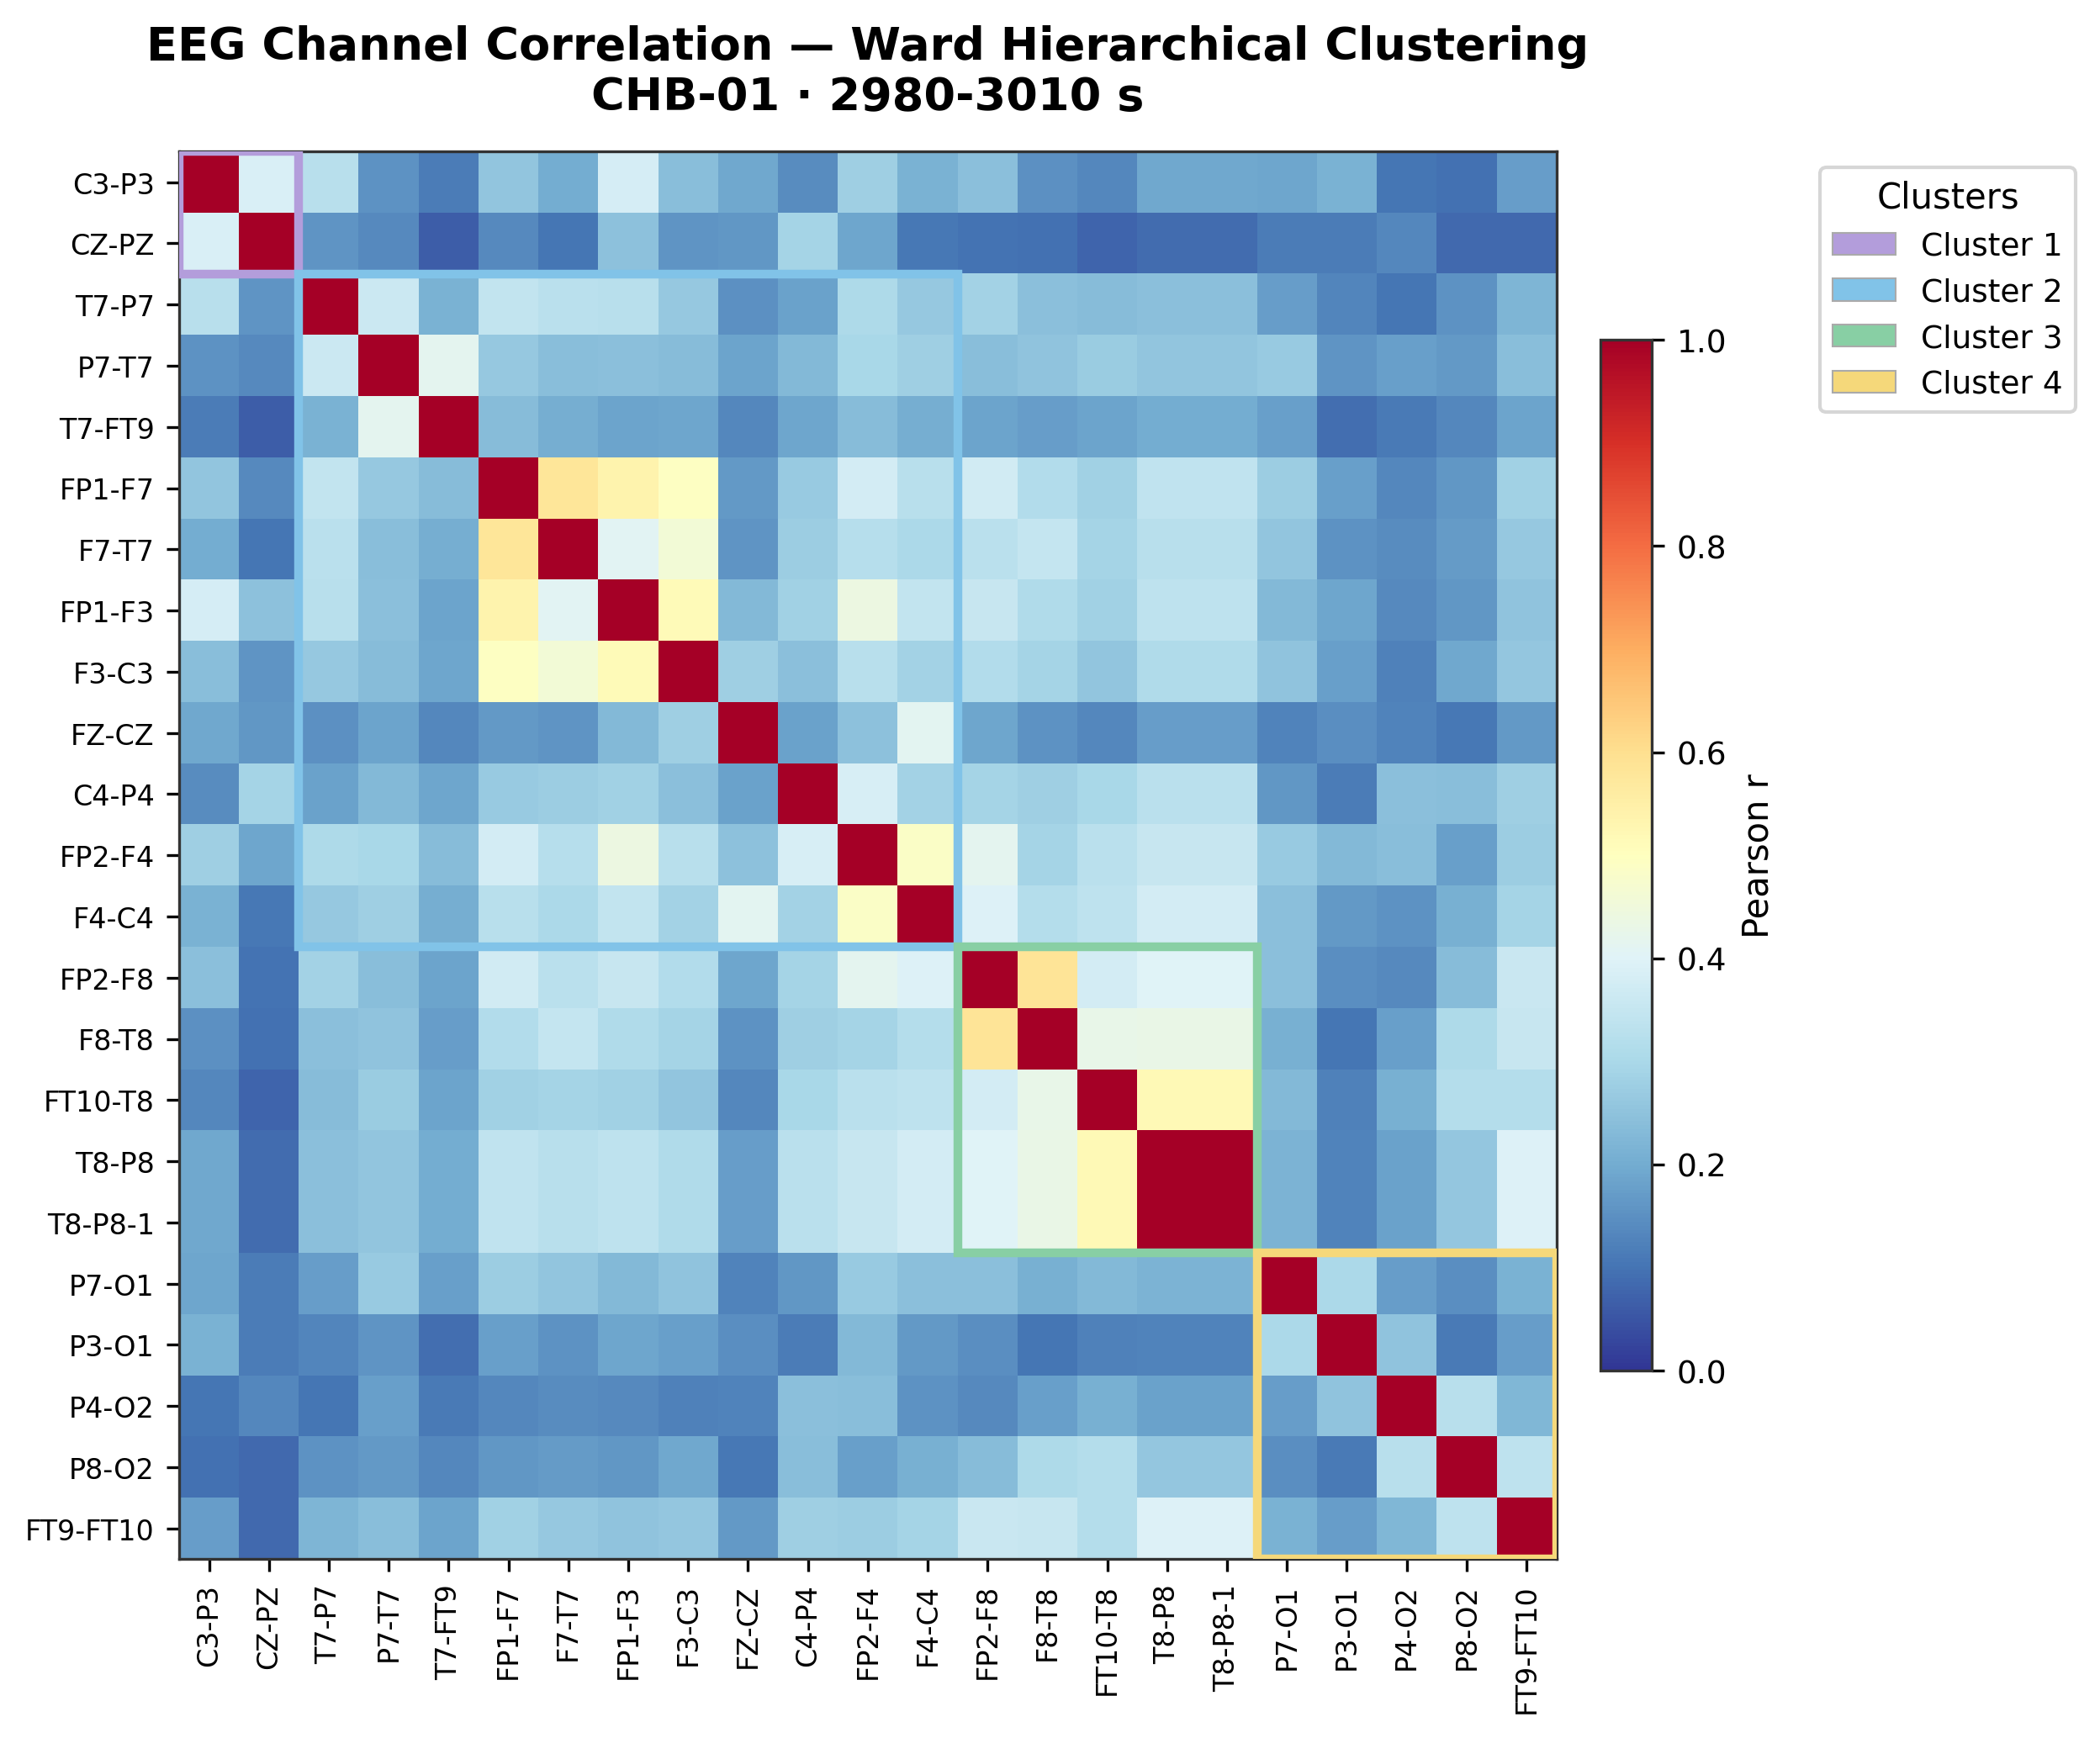

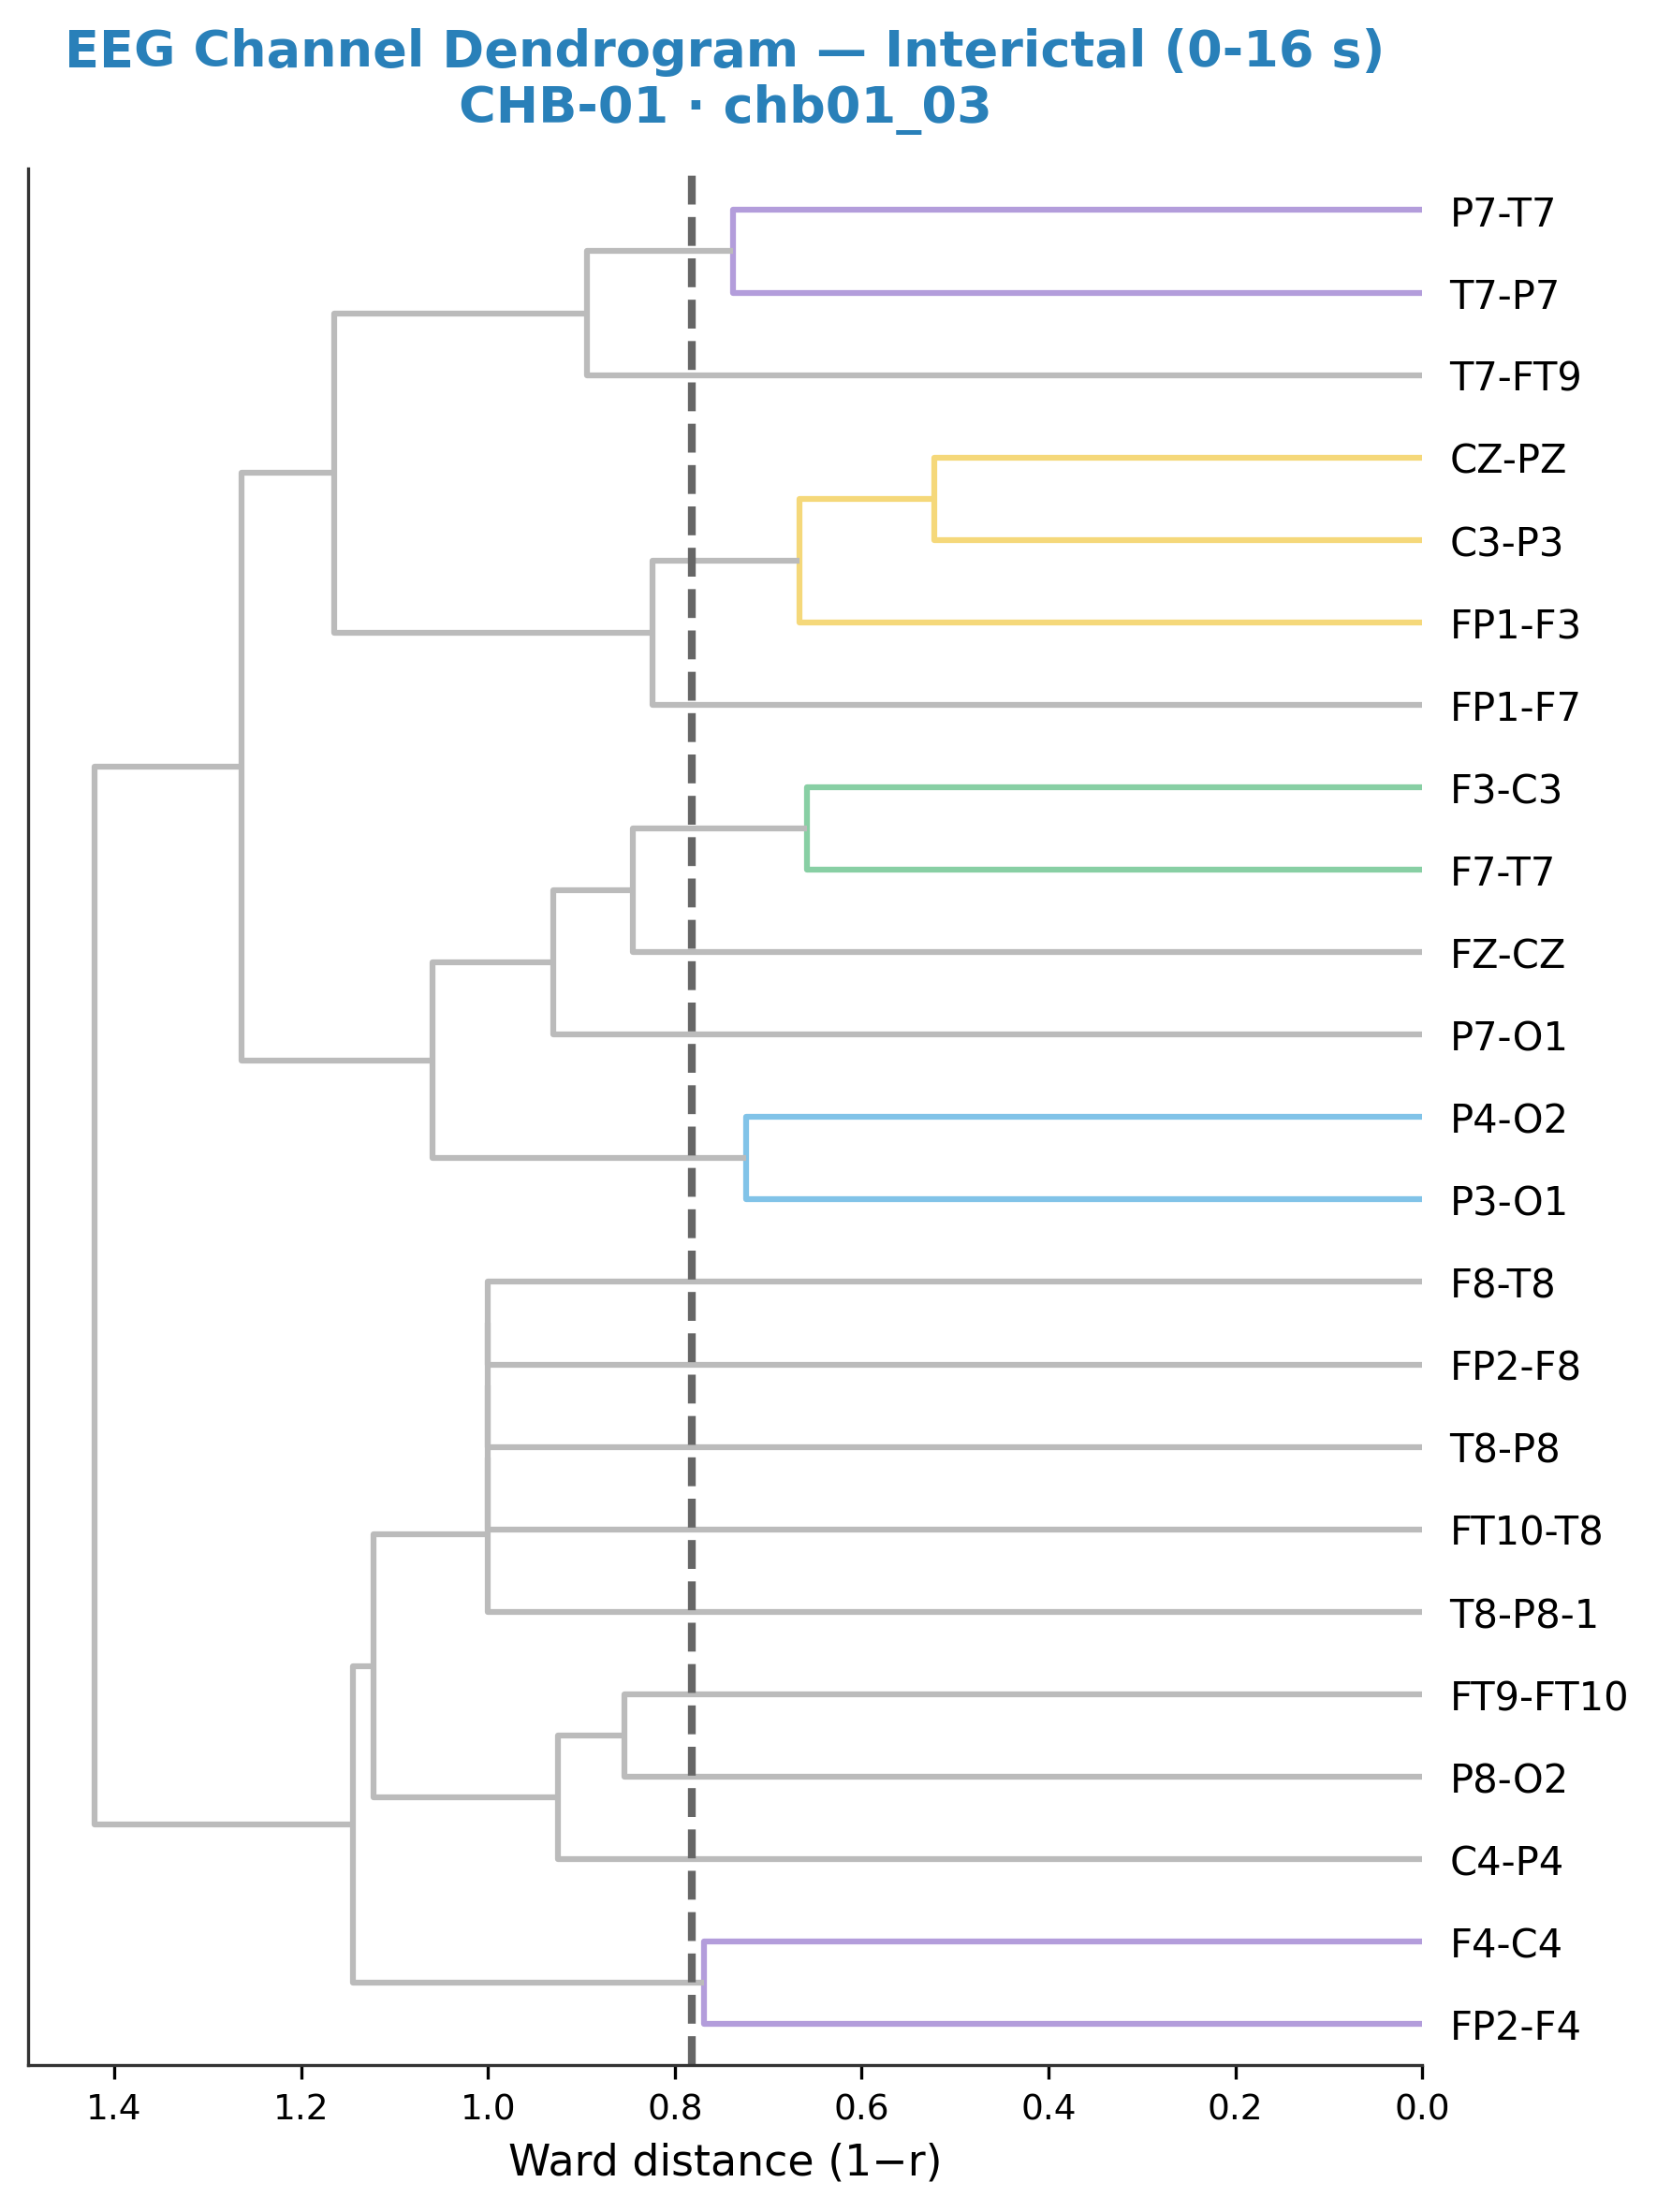

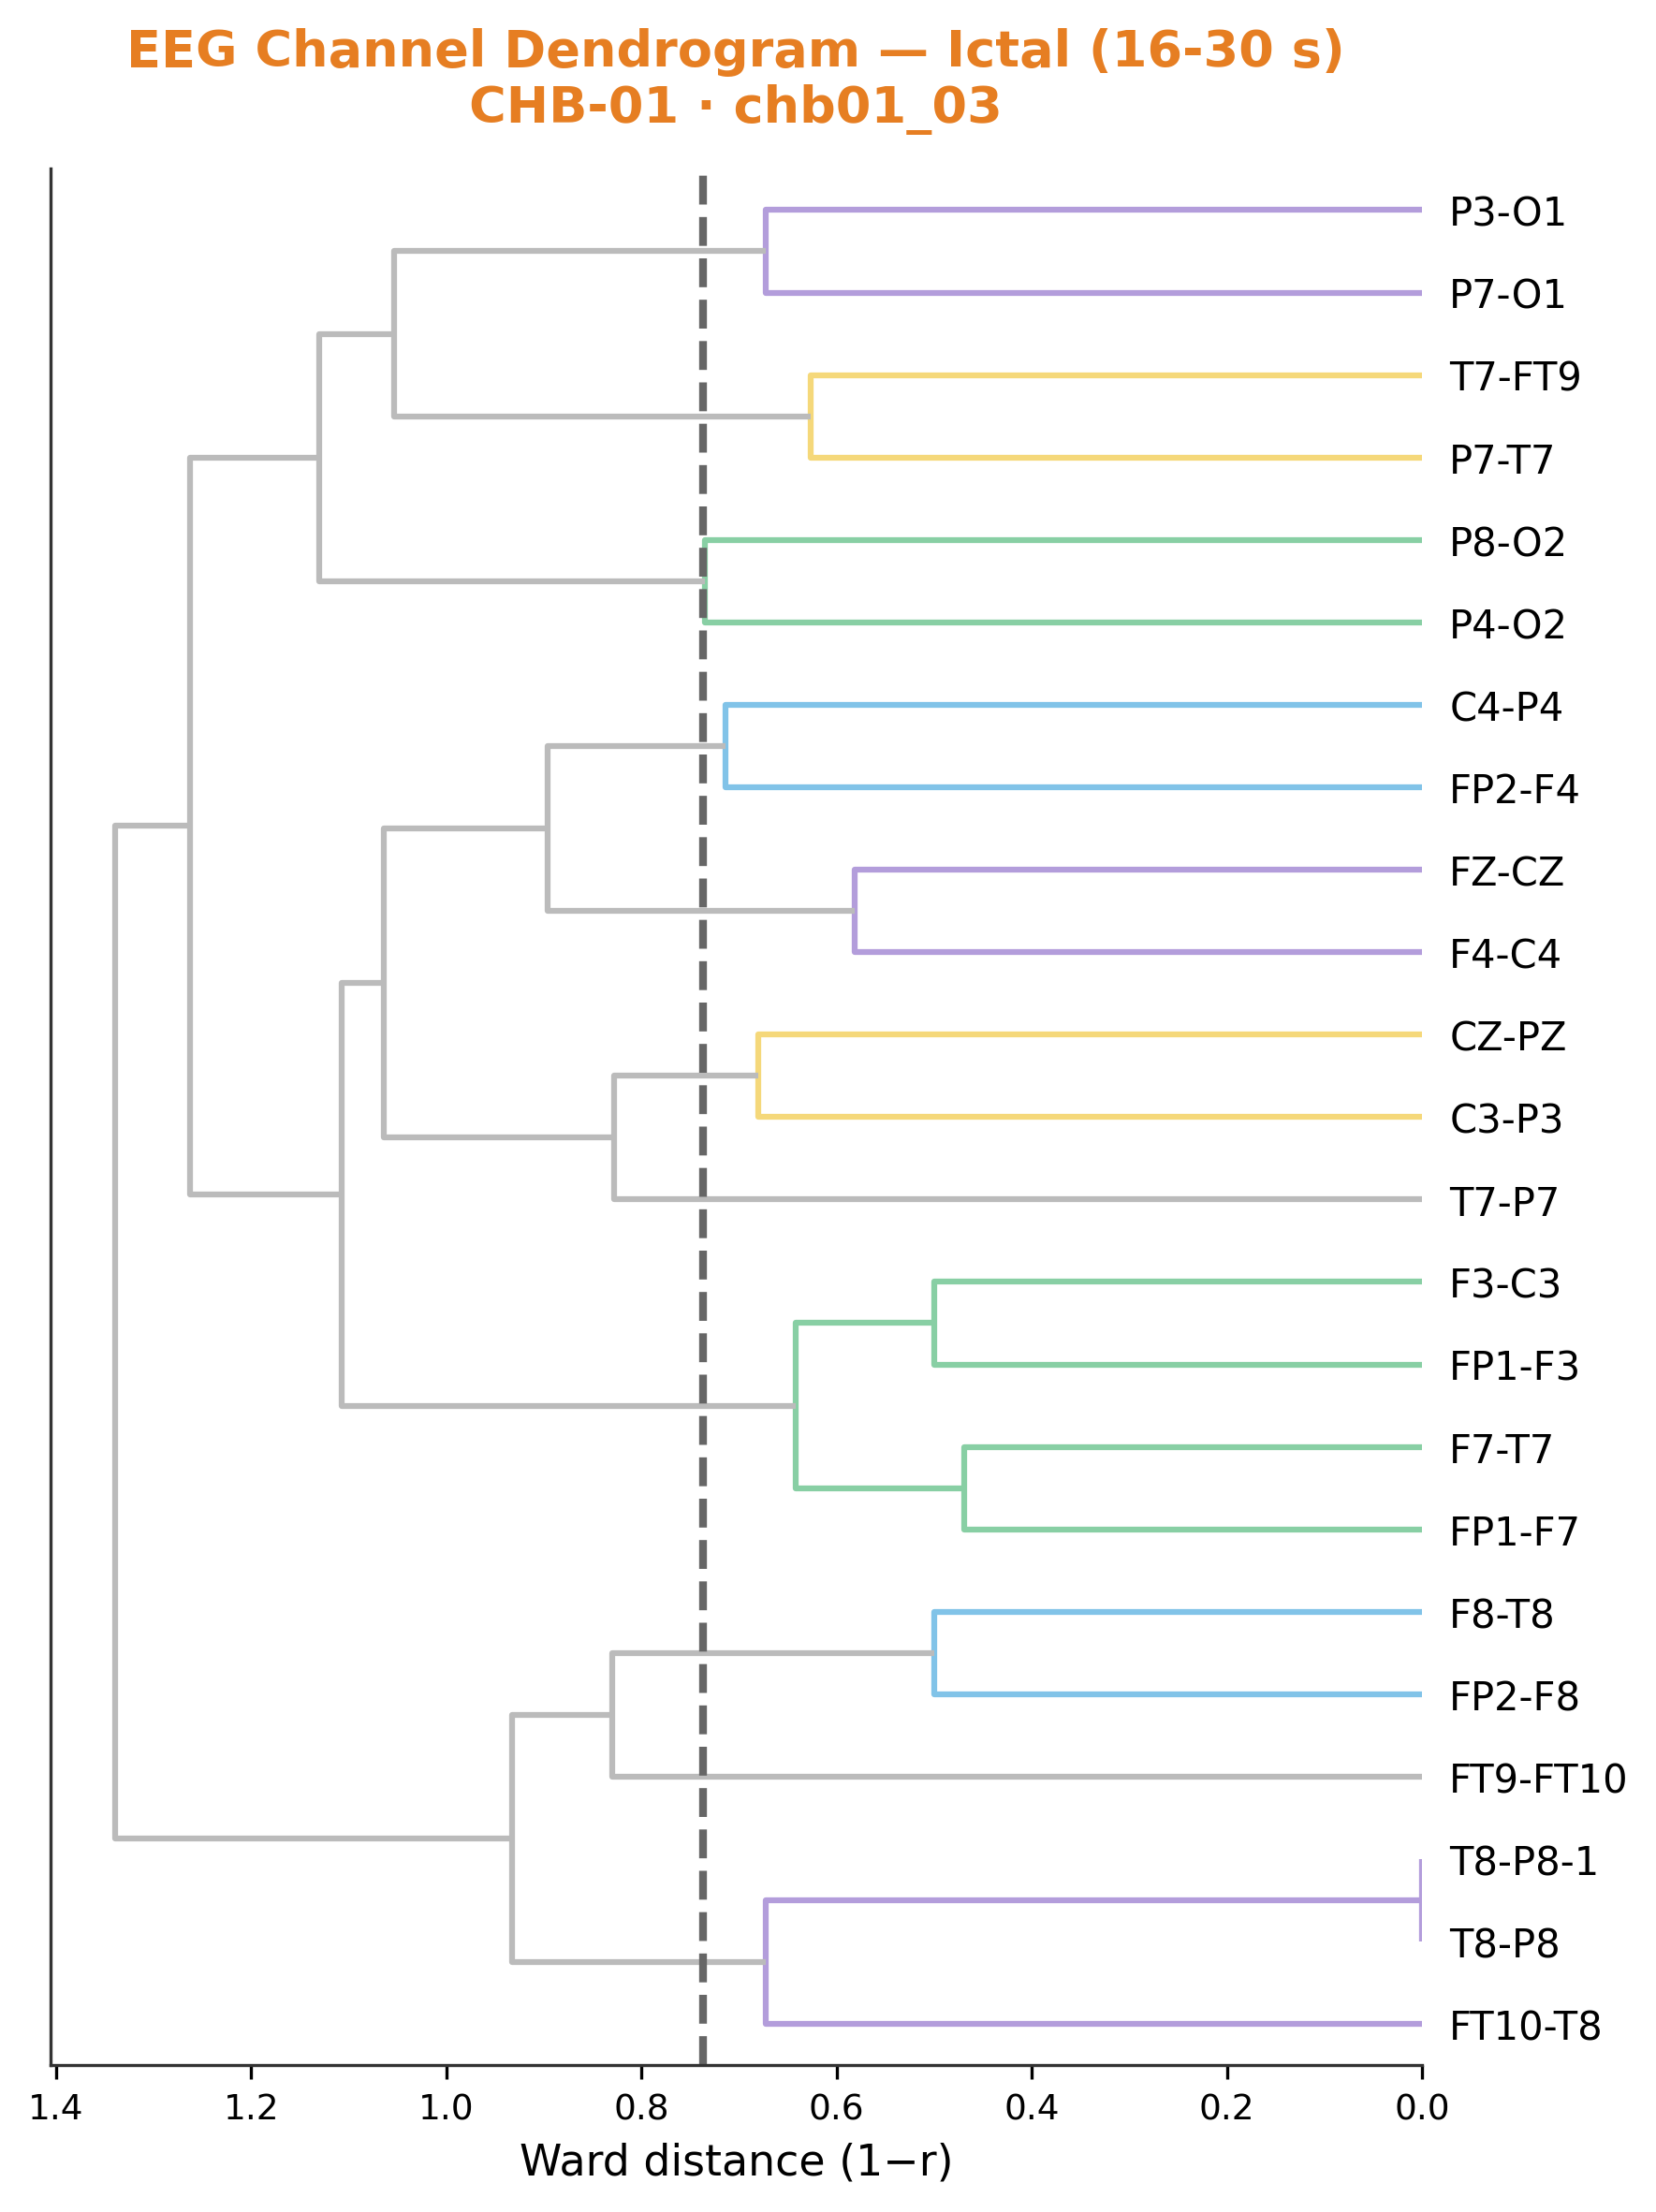

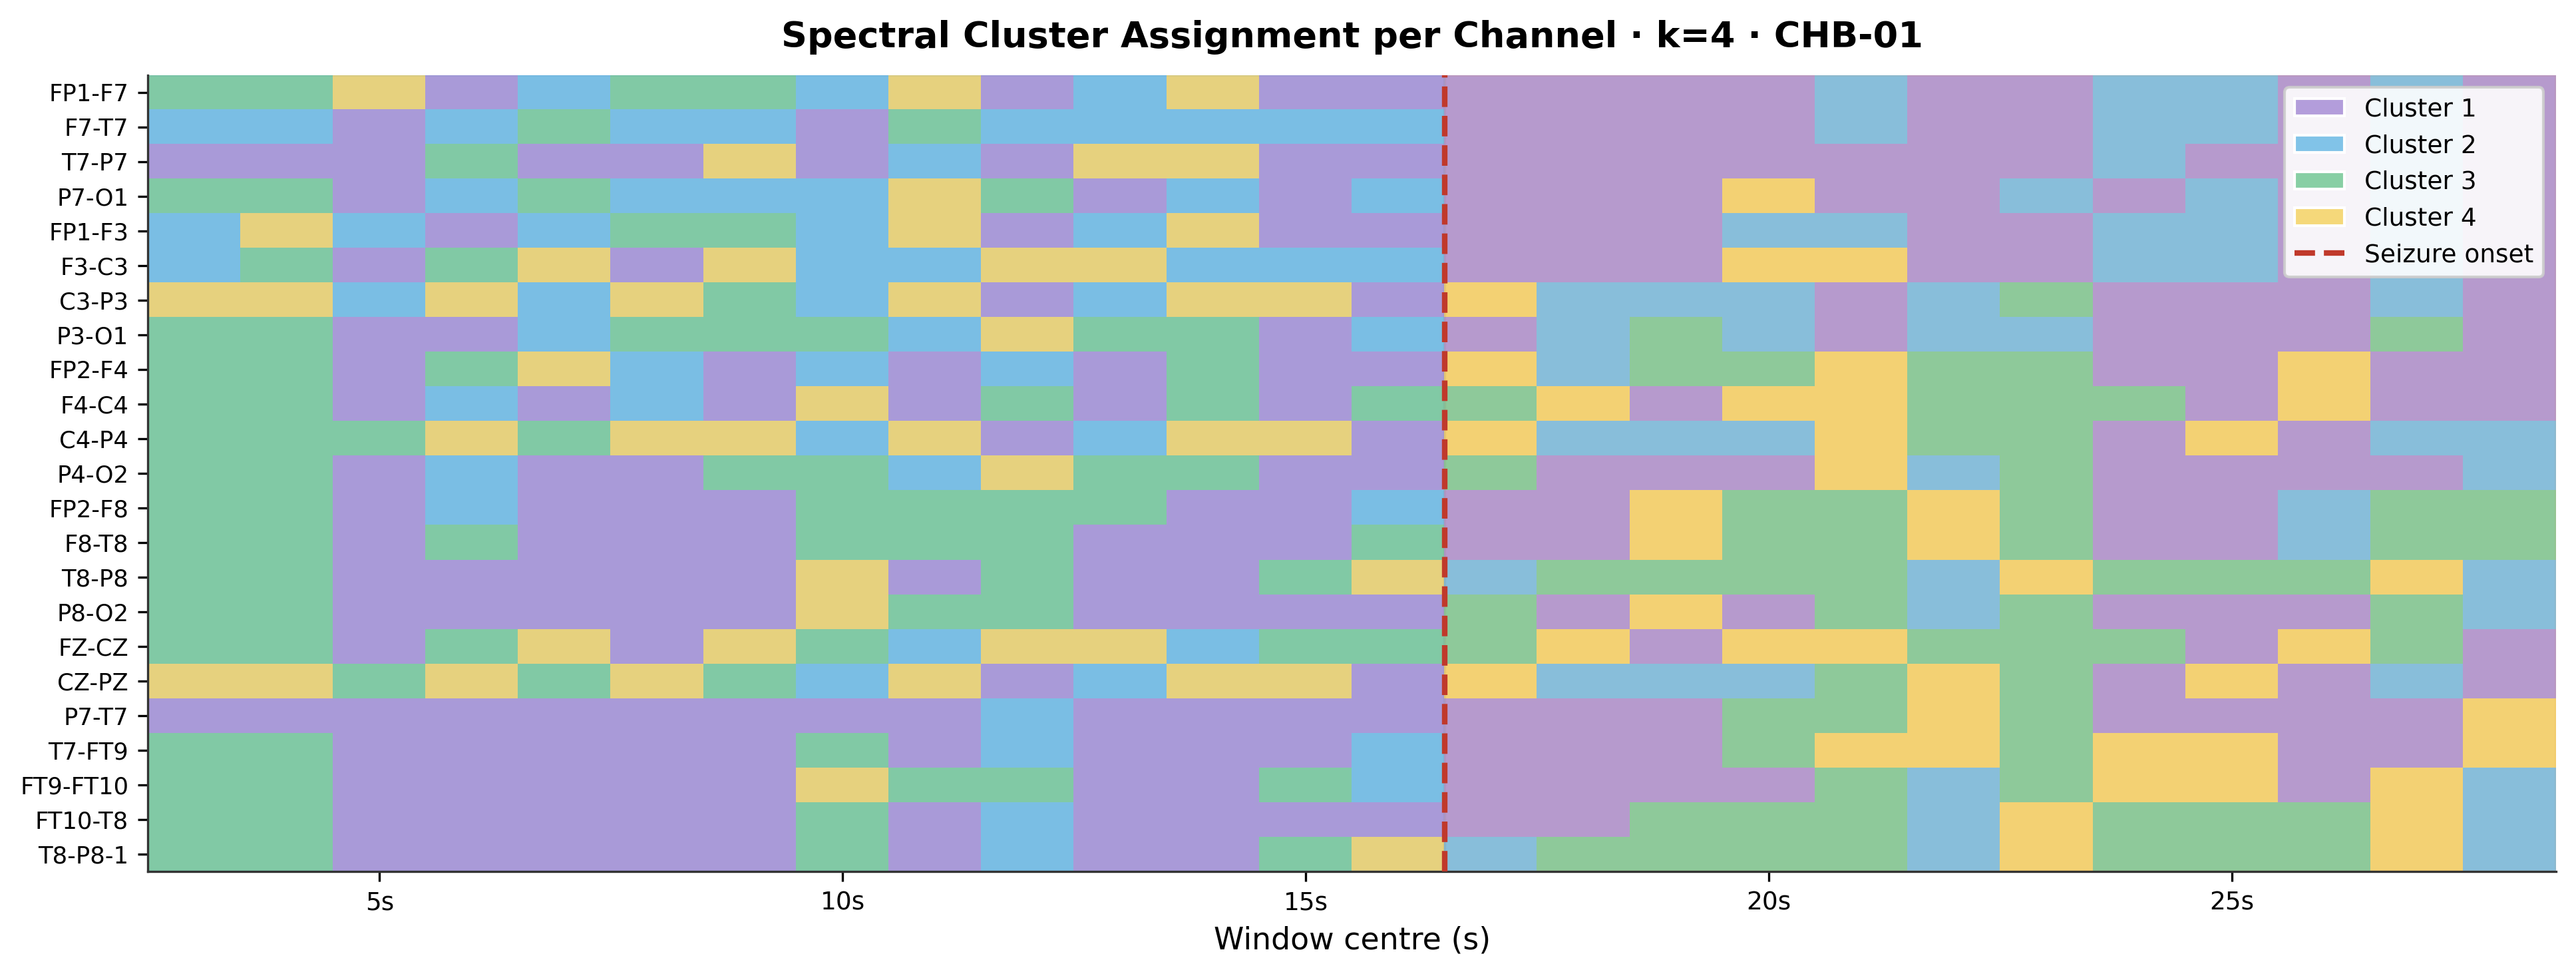

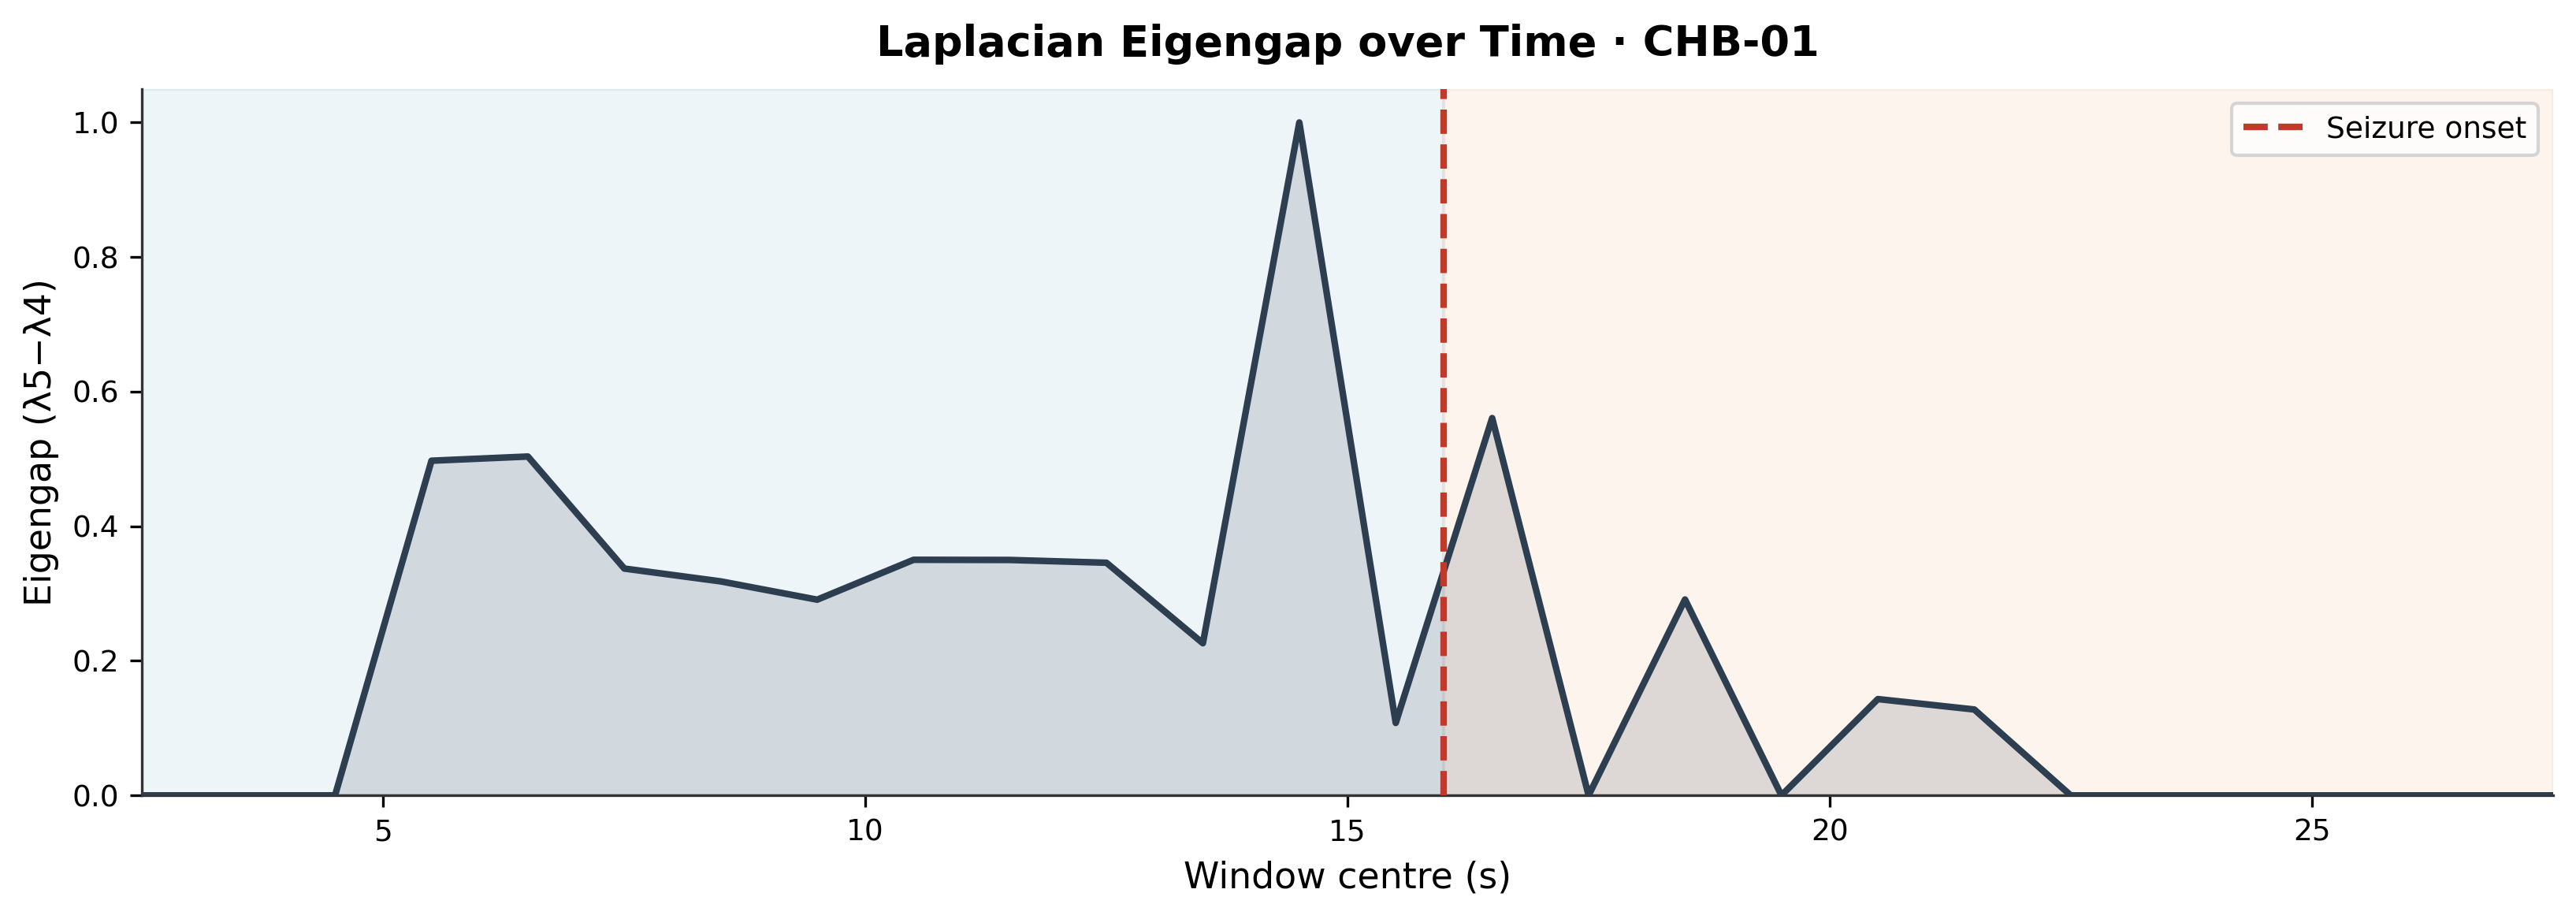

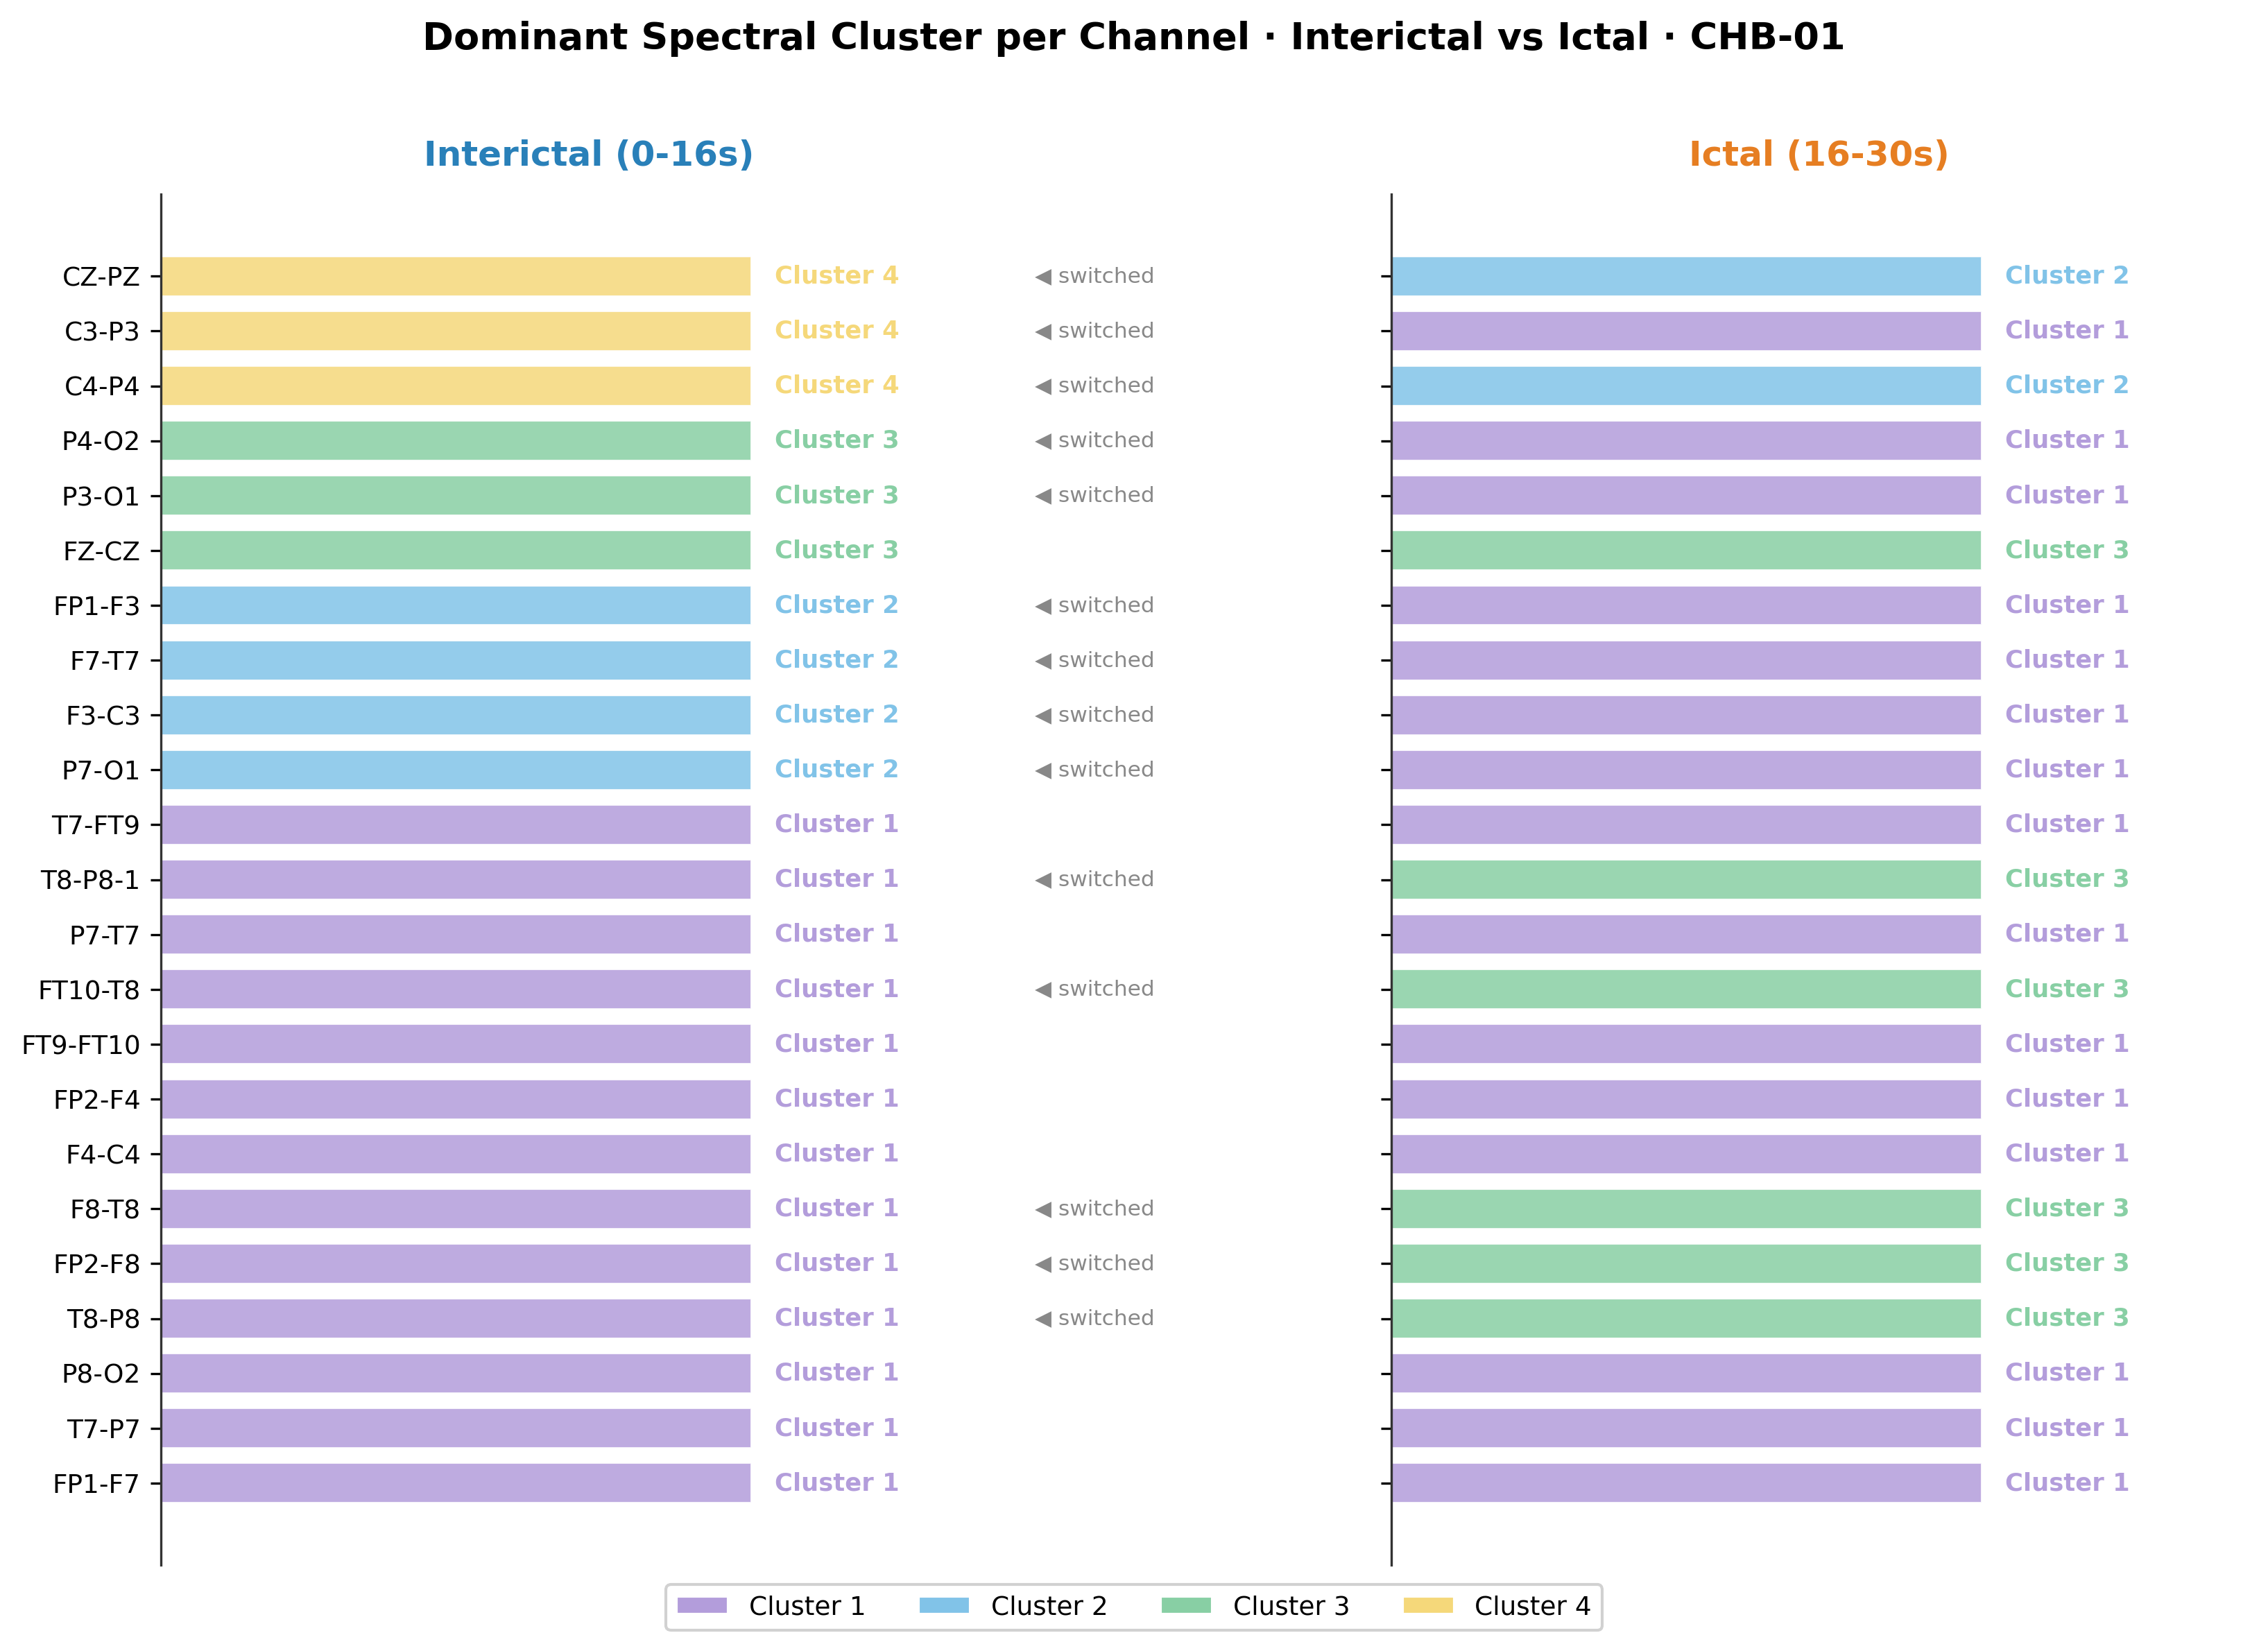

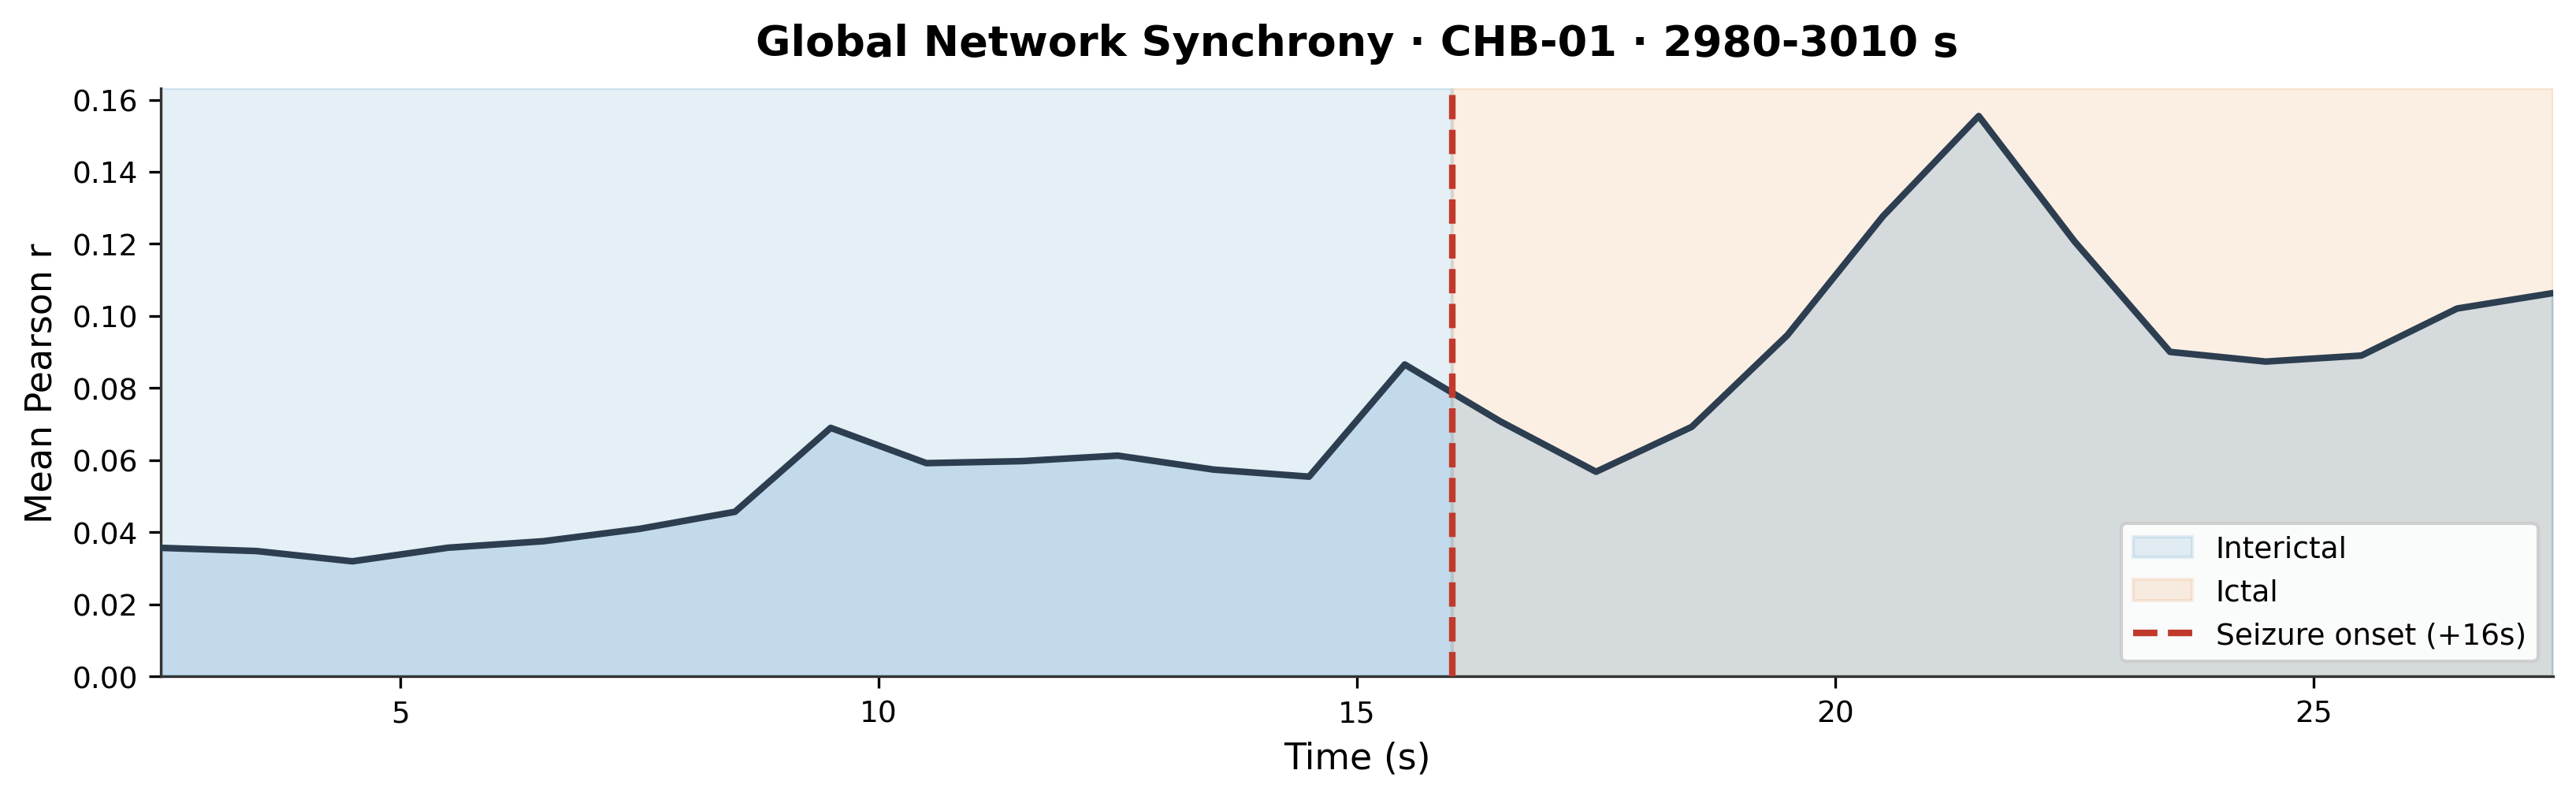

In [20]:
# ────────────────────────────────────────────────────────────────────────
run_report_figures()

---
## SECTION 7 · Cosmograph CSV Preparation

Exports node + edge CSVs for [Cosmograph](https://cosmograph.app):
- **Part A** (`run_cosmograph_analytics`): community labels per algorithm per phase
- **Part B** (`run_cosmograph_explorative`): static pre/ictal + streaming timeline CSVs

In [21]:
def run_cosmograph_analytics():
    print_section("SECTION 7 · Cosmograph CSV Preparation")
    """Part A — community labels per algorithm (requires SM community_labels.npy)."""
    if not SM_LABELS.exists():
        _skip("Cosmograph analytics CSVs", "community_labels.npy not found — run Section 5a first")
        return

    OUT   = BASE_DIR / "src" / "03_analytics" / "outputs" / "cosmograph"
    OUT.mkdir(parents=True, exist_ok=True)
    THR_CORR = 0.5; K_ = 4

    mat       = sp.load_npz(NPZ_PATH).tocsr()
    sm_labels = np.load(SM_LABELS)
    print(f"  SM labels: {len(np.unique(sm_labels))} communities")

    def remap(lbs):
        u = np.unique(lbs); m = {v: i for i, v in enumerate(u)}
        return np.array([m[l] for l in lbs], dtype=np.int64)

    def hier_spec(ch_tmp, corr):
        dist = squareform(np.clip(1.0 - corr, 0.0, None), checks=False)
        lnk  = sch.linkage(dist, method="ward")
        hch  = sch.fcluster(lnk, t=K_, criterion="maxclust") - 1
        A    = corr.copy(); A[A < THR_CORR] = 0; A[A < 0] = 0; np.fill_diagonal(A, 0)
        deg  = A.sum(axis=1)
        d    = np.where(deg > 0, 1 / np.sqrt(np.maximum(deg, 1e-10)), 0)
        L    = np.eye(N_CH) - np.diag(d) @ A @ np.diag(d)
        _, vecs = np.linalg.eigh(L)
        emb  = vecs[:, :K_].copy()
        nrm  = np.linalg.norm(emb, axis=1, keepdims=True); nrm[nrm == 0] = 1; emb /= nrm
        rng  = np.random.default_rng(42); ba = None; bi = np.inf
        for _ in range(20):
            ctrs = emb[rng.choice(N_CH, K_, replace=False)]
            for __ in range(300):
                D    = np.linalg.norm(emb[:, None, :] - ctrs[None, :, :], axis=2)
                asgn = np.argmin(D, axis=1)
                nc   = np.array([emb[asgn == k].mean(0) if (asgn == k).any()
                                 else emb[rng.integers(N_CH)] for k in range(K_)])
                if np.allclose(nc, ctrs): break
                ctrs = nc
            inn = sum(np.sum((emb[asgn == k] - ctrs[k])**2) for k in range(K_) if (asgn == k).any())
            if inn < bi: bi = inn; ba = asgn.copy()
        return hch, ba

    def run_lpa_sync(adj_csr, init, max_iter=50):
        labels = init.copy().astype(np.int64)
        for it in range(max_iter):
            ul = np.unique(labels); k = len(ul)
            scores = np.zeros((adj_csr.shape[0], k), dtype=np.float32)
            for ki, lab in enumerate(ul):
                mask = (labels == lab).astype(np.float32); scores[:, ki] = adj_csr.dot(mask)
            nl = ul[scores.argmax(axis=1)]
            if np.array_equal(nl, labels):
                print(f"      LPA converged at {it+1}"); break
            labels = nl
        return remap(labels)

    PHASES = {"interictal": (0, ONSET*FS), "ictal": (ONSET*FS, N_TP)}
    for phase, (t0, t1) in PHASES.items():
        n_nodes = N_CH * (t1 - t0)
        print(f"\n  Phase: {phase.upper()} ({t0//FS}-{t1//FS}s | {n_nodes:,} nodes)")
        node_ids = np.concatenate([np.arange(ch*N_TP+t0, ch*N_TP+t1) for ch in range(N_CH)])
        n_tp = t1 - t0; ch_tmp = np.zeros((N_CH, n_tp), dtype=np.float64)
        for ch in range(N_CH):
            s = ch*N_TP+t0; e = ch*N_TP+t1
            ch_tmp[ch] = np.array(mat[s:e, s:e].sum(axis=1)).flatten()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore"); pc = np.corrcoef(ch_tmp)
        pc = np.nan_to_num(pc, nan=0.0)
        adj_raw = mat[node_ids][:, node_ids].tocoo()
        msk  = adj_raw.row < adj_raw.col
        keep = list(zip(adj_raw.row[msk], adj_raw.col[msk], adj_raw.data[msk]))
        if keep:
            rs, cs, vs = zip(*keep)
            rs, cs, vs = np.array(rs), np.array(cs), np.array(vs, dtype=np.float32)
            adj_sub = sp.csr_matrix(
                (np.concatenate([vs, vs]),
                 (np.concatenate([rs, cs]), np.concatenate([cs, rs]))),
                shape=(n_nodes, n_nodes))
        else:
            adj_sub = sp.csr_matrix((n_nodes, n_nodes))

        sm_sub   = remap(sm_labels[node_ids])
        ch_init  = np.array([int(nid) // N_TP for nid in node_ids], dtype=np.int64)
        lpa_sub  = run_lpa_sync(adj_sub, ch_init)
        hier_ch, spec_ch = hier_spec(ch_tmp, pc)
        hier_sub = remap(np.array([hier_ch[int(nid) // N_TP] for nid in node_ids]))
        spec_sub = remap(np.array([spec_ch[int(nid) // N_TP] for nid in node_ids]))

        ep = OUT / f"{phase}_edges.csv"
        with open(ep, "w", newline="", encoding="utf-8") as f:
            w = csv.writer(f); w.writerow(["source", "target", "weight"])
            for r, c, v in keep:
                w.writerow([int(node_ids[r]), int(node_ids[c]), round(float(v), 6)])

        for algo, lbs in [("stream_moore", sm_sub), ("lpa", lpa_sub),
                           ("hierarchical", hier_sub), ("spectral", spec_sub)]:
            np_ = OUT / f"{algo}_{phase}_nodes.csv"
            with open(np_, "w", newline="", encoding="utf-8") as f:
                w = csv.writer(f)
                w.writerow(["id","channel_idx","channel_name","region","timepoint","time_sec","community"])
                for li, orig in enumerate(node_ids):
                    ch = int(orig) // N_TP; tp = int(orig) % N_TP
                    w.writerow([int(orig), ch, CHANNEL_NAMES[ch],
                                CHANNEL_REGIONS.get(CHANNEL_NAMES[ch], "unknown"),
                                tp, round(tp / FS, 4), int(lbs[li])])
            print(f"    {np_.name}  ({len(np.unique(lbs))} communities)")

    _ok("Cosmograph analytics CSVs", f"→ {OUT}")

def run_cosmograph_explorative():
    """Part B — static pre/ictal + streaming timeline CSVs."""
    N_ELEC = 23; N_TIME = 7680; WINDOW = 256; N_WIN = N_TIME // WINDOW; SEIZURE = 15
    INTRA_THR = 0.2; INTER_THR = 0.5
    LABELS = ["FP1","FP2","F7","F3","FZ","F4","F8","T7","C3","CZ","C4","T8",
              "P7","P3","PZ","P4","P8","O1","OZ","O2","A1","A2","T9"]
    ELEC_POS = [[0.5,0.05],[0.55,0.05],[0.15,0.18],[0.35,0.15],[0.5,0.12],
                [0.65,0.15],[0.85,0.18],[0.1,0.45],[0.3,0.38],[0.5,0.35],
                [0.7,0.38],[0.9,0.45],[0.1,0.7],[0.3,0.62],[0.5,0.6],
                [0.7,0.62],[0.9,0.7],[0.3,0.85],[0.5,0.82],[0.7,0.85],
                [0.05,0.55],[0.95,0.55],[0.05,0.75]]
    CANVAS = 5000; R_ELEC = 80; R_CZ = 500

    print("  Loading matrix for explorative Cosmograph …")
    mat  = sp.load_npz(NPZ_PATH); cx = mat.tocoo()
    rows_elec = cx.row // N_TIME; rows_time = cx.row % N_TIME; cols_elec = cx.col // N_TIME
    same = rows_elec == cols_elec

    intra_mat = sp.csr_matrix((np.ones(same.sum()), (cx.row[same], cx.col[same])), shape=mat.shape)
    intra_deg = (np.array(intra_mat.sum(axis=1)).flatten() +
                 np.array(intra_mat.sum(axis=0)).flatten())
    deg_full  = intra_deg.reshape(N_ELEC, N_TIME)

    def inter_corr(w0, w1):
        nw   = w1 - w0
        dw   = deg_full[:, w0*WINDOW:w1*WINDOW].reshape(N_ELEC, nw, WINDOW).mean(axis=2)
        corr = np.zeros((N_ELEC, N_ELEC))
        for i in range(N_ELEC):
            for j in range(i+1, N_ELEC):
                a, b = dw[i], dw[j]; ma, mb = a.mean(), b.mean()
                na, nb = a - ma, b - mb
                denom = np.sqrt((na**2).sum() * (nb**2).sum())
                if denom == 0: continue
                r = max(0, float((na*nb).sum() / denom))
                corr[i][j] = corr[j][i] = round(r, 4)
        return corr

    corr_pre = inter_corr(0, SEIZURE); corr_ict = inter_corr(SEIZURE, N_WIN)

    def build_static(phase):
        is_pre = (phase == "pre"); w0 = 0 if is_pre else SEIZURE; w1 = SEIZURE if is_pre else N_WIN
        nw = w1 - w0; corr = corr_pre if is_pre else corr_ict
        nodes = []; edges = []
        for ei in range(N_ELEC):
            ex = ELEC_POS[ei][0] * CANVAS; ey = ELEC_POS[ei][1] * CANVAS
            avg_deg = (deg_full[ei, :SEIZURE*WINDOW].reshape(nw, WINDOW).mean(axis=0) if is_pre
                       else deg_full[ei, SEIZURE*WINDOW:].reshape(nw, WINDOW).mean(axis=0))
            for k in range(WINDOW):
                angle = (k / WINDOW) * 2 * math.pi - math.pi / 2
                nodes.append({"id": f"e{ei}_t{k}", "x": round(ex + R_ELEC*math.cos(angle), 2),
                              "y": round(ey + R_ELEC*math.sin(angle), 2),
                              "degree": round(float(avg_deg[k]), 4),
                              "electrode": LABELS[ei], "electrode_id": ei,
                              "phase": phase, "timepoint": k})
            ec = {}
            for w in range(w0, w1):
                ts = w * WINDOW; te = (w+1) * WINDOW
                msk = (same & (rows_elec == ei) & (rows_time >= ts) & (rows_time < te))
                r_tp = (cx.row[msk] % N_TIME) - ts; c_tp = (cx.col[msk] % N_TIME) - ts; seen = set()
                for ri, ci in zip(r_tp.tolist(), c_tp.tolist()):
                    if ri >= ci or ri < 0 or ci >= WINDOW or (ri, ci) in seen: continue
                    seen.add((ri, ci)); ec[(ri, ci)] = ec.get((ri, ci), 0) + 1
            for (a, b), cnt in ec.items():
                if cnt / nw >= INTRA_THR:
                    edges.append({"source": f"e{ei}_t{a}", "target": f"e{ei}_t{b}",
                                  "weight": round(cnt/nw, 4), "type": "intra",
                                  "electrode": LABELS[ei]})
        for i in range(N_ELEC):
            for j in range(i+1, N_ELEC):
                c = corr[i][j]
                if c >= INTER_THR:
                    edges.append({"source": f"e{i}_t128", "target": f"e{j}_t128",
                                  "weight": round(c, 4), "type": "inter",
                                  "electrode": f"{LABELS[i]}-{LABELS[j]}"})
        return nodes, edges

    def build_cz(ei_cz=9):
        nodes = []; edges = []
        for w in range(N_WIN):
            ts = w * WINDOW; te = (w+1) * WINDOW; phase = "pre-ictal" if w < SEIZURE else "ictal"
            for k in range(WINDOW):
                tp = ts + k; d = float(deg_full[ei_cz, tp])
                angle = (k / WINDOW) * 2 * math.pi - math.pi / 2
                nodes.append({"id": f"w{w}_t{k}", "x": round(R_CZ*math.cos(angle), 2),
                              "y": round(R_CZ*math.sin(angle), 2), "degree": round(d, 4),
                              "time": w, "phase": phase, "timepoint": k})
            msk   = (same & (rows_elec == ei_cz) & (rows_time >= ts) & (rows_time < te))
            r_tp  = (cx.row[msk] % N_TIME) - ts; c_tp = (cx.col[msk] % N_TIME) - ts; seen = set()
            for ri, ci in zip(r_tp.tolist(), c_tp.tolist()):
                if ri >= ci or ri < 0 or ci >= WINDOW or (ri, ci) in seen: continue
                seen.add((ri, ci)); dist = ci - ri
                edges.append({"source": f"w{w}_t{ri}", "target": f"w{w}_t{ci}",
                              "weight": round(1/dist, 4), "time": w})
        return nodes, edges

    def build_all():
        nodes = []; edges = []
        for w in range(N_WIN):
            ts = w * WINDOW; te = (w+1) * WINDOW; phase = "pre-ictal" if w < SEIZURE else "ictal"
            for ei in range(N_ELEC):
                ex = ELEC_POS[ei][0] * CANVAS; ey = ELEC_POS[ei][1] * CANVAS
                for k in range(WINDOW):
                    tp = ts + k; d = float(deg_full[ei, tp])
                    angle = (k / WINDOW) * 2 * math.pi - math.pi / 2
                    nodes.append({"id": f"e{ei}_w{w}_t{k}",
                                 "x": round(ex + R_ELEC*math.cos(angle), 2),
                                 "y": round(ey + R_ELEC*math.sin(angle), 2),
                                 "degree": round(d, 4), "time": w, "phase": phase,
                                 "electrode": LABELS[ei], "timepoint": k})
                msk  = (same & (rows_elec == ei) & (rows_time >= ts) & (rows_time < te))
                r_tp = (cx.row[msk] % N_TIME) - ts; c_tp = (cx.col[msk] % N_TIME) - ts; seen = set()
                for ri, ci in zip(r_tp.tolist(), c_tp.tolist()):
                    if ri >= ci or ri < 0 or ci >= WINDOW or (ri, ci) in seen: continue
                    seen.add((ri, ci)); dist = ci - ri
                    edges.append({"source": f"e{ei}_w{w}_t{ri}", "target": f"e{ei}_w{w}_t{ci}",
                                 "weight": round(1/dist, 4), "time": w, "electrode": LABELS[ei]})
            if w % 5 == 0: print(f"    window {w:2d} done – nodes so far: {len(nodes):,}")
        return nodes, edges

    def write_csv(path, rows, fields):
        with open(path, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=fields); w.writeheader(); w.writerows(rows)
        print(f"    {Path(path).name}: {len(rows):,} rows")

    print("  Building static pre-ictal & ictal CSVs …")
    np_pre, ep_pre = build_static("pre"); np_ict, ep_ict = build_static("ict")
    write_csv(COSMO_DIR/"cosmo_pre_nodes.csv", np_pre, ["id","x","y","degree","electrode","electrode_id","phase","timepoint"])
    write_csv(COSMO_DIR/"cosmo_pre_edges.csv", ep_pre, ["source","target","weight","type","electrode"])
    write_csv(COSMO_DIR/"cosmo_ict_nodes.csv", np_ict, ["id","x","y","degree","electrode","electrode_id","phase","timepoint"])
    write_csv(COSMO_DIR/"cosmo_ict_edges.csv", ep_ict, ["source","target","weight","type","electrode"])

    print("  Building CZ streaming CSV …")
    nc, ec = build_cz()
    write_csv(COSMO_DIR/"cosmograph_nodes_CZ.csv",    nc, ["id","x","y","degree","time","phase","timepoint"])
    write_csv(COSMO_DIR/"cosmograph_edges_CZ.csv",    ec, ["source","target","weight","time"])

    print("  Building all-electrodes streaming CSV …")
    na, ea = build_all()
    write_csv(COSMO_DIR/"cosmograph_nodes_all.csv", na, ["id","x","y","degree","time","phase","electrode","timepoint"])
    write_csv(COSMO_DIR/"cosmograph_edges_all.csv", ea, ["source","target","weight","time","electrode"])
    _ok("Cosmograph explorative CSVs", f"→ {COSMO_DIR}")

In [22]:
# ────────────────────────────────────────────────────────────────────────
run_cosmograph_analytics()
run_cosmograph_explorative()


──────────────────────────────────────────────────────────────────────
  SECTION 7 · Cosmograph CSV Preparation
──────────────────────────────────────────────────────────────────────
  SM labels: 7665 communities

  Phase: INTERICTAL (0-16s | 94,208 nodes)
      LPA converged at 3
    stream_moore_interictal_nodes.csv  (4096 communities)
    lpa_interictal_nodes.csv  (1 communities)
    hierarchical_interictal_nodes.csv  (4 communities)
    spectral_interictal_nodes.csv  (4 communities)

  Phase: ICTAL (16-30s | 82,432 nodes)
      LPA converged at 3
    stream_moore_ictal_nodes.csv  (3569 communities)
    lpa_ictal_nodes.csv  (1 communities)
    hierarchical_ictal_nodes.csv  (4 communities)
    spectral_ictal_nodes.csv  (4 communities)
  Loading matrix for explorative Cosmograph …
  Building static pre-ictal & ictal CSVs …
    cosmo_pre_nodes.csv: 5,888 rows
    cosmo_pre_edges.csv: 302 rows
    cosmo_ict_nodes.csv: 5,888 rows
    cosmo_ict_edges.csv: 4,342 rows
  Building CZ streami

---
## SECTION 8 · Benchmarking

Sweeps each algorithm’s key hyperparameter and measures **NMI stability** vs **CPU time**:

| Algorithm | Swept parameter |
|-----------|----------------|
| Ward Hierarchical | Dendrogram cut k |
| Label Propagation | Max iterations |
| Spectral Laplacian | Number of clusters k |
| Moore Streaming | Processed edges |

Outputs: 4-panel sweet-spot plot + radar diagram.

In [23]:
def run_benchmarking():
    print_section("SECTION 8 · Benchmarking  (sweet-spot + radar diagram)")
    THRESHOLD = 0.3; N_RUNS = 5
    mat    = sp.load_npz(NPZ_PATH).tocsr()
    ch_tmp = np.zeros((N_CH, N_TP))
    for ch in range(N_CH):
        s, e = ch*N_TP, (ch+1)*N_TP
        ch_tmp[ch] = np.array(mat[s:e, s:e].sum(axis=1)).flatten()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore"); corr = np.corrcoef(ch_tmp)
    corr = np.nan_to_num(corr, nan=0.0); np.fill_diagonal(corr, 0.0)
    dist_mat  = squareform(np.clip(1.0 - corr, 0.0, None), checks=False)
    W_        = np.where(corr > THRESHOLD, corr, 0.0)
    Z         = sch.linkage(dist_mat, method="ward")
    all_edges = sorted([(i, j, W_[i, j]) for i in range(N_CH) for j in range(i+1, N_CH)
                        if W_[i, j] > 0], key=lambda x: -x[2])
    N_EDGES   = len(all_edges)

    def nmi(a, b):
        a, b = np.asarray(a), np.asarray(b)
        ca, cb = np.unique(a), np.unique(b)
        pa = np.array([(a == x).mean() for x in ca])
        pb = np.array([(b == x).mean() for x in cb])
        P  = np.zeros((len(ca), len(cb)))
        for i, x in enumerate(ca):
            for j, y in enumerate(cb): P[i, j] = ((a == x) & (b == y)).mean()
        mi = sum(P[i,j]*np.log(P[i,j]/(pa[i]*pb[j]))
                 for i in range(len(ca)) for j in range(len(cb)) if P[i,j] > 0)
        ha = -sum(p*np.log(p) for p in pa if p > 0)
        hb = -sum(p*np.log(p) for p in pb if p > 0)
        return 2*mi/(ha+hb) if ha+hb > 0 else 1.0

    def run_exp(fn, terms):
        cpu, nmis = [], []
        for t in terms:
            runs = []; t0 = time.perf_counter()
            for r in range(N_RUNS): runs.append(fn(t, seed=r))
            cpu.append(time.perf_counter() - t0)
            nmis.append(np.mean([nmi(runs[0], x) for x in runs[1:]]))
        return np.array(cpu), np.array(nmis)

    def run_ward(k, seed=0): return sch.fcluster(Z, k, criterion="maxclust")

    def run_lpa(mi, seed):
        random.seed(seed); n = N_CH; labels = list(range(n))
        for _ in range(mi):
            changes = 0; order = list(range(n)); random.shuffle(order)
            for node in order:
                lw = defaultdict(float)
                for j in range(n):
                    if j != node and W_[node, j] > 0: lw[labels[j]] += W_[node, j]
                if not lw: continue
                nl = max(lw, key=lw.get)
                if labels[node] != nl: labels[node] = nl; changes += 1
            if changes == 0: break
        return np.array(labels)

    def run_spectral(k, seed):
        A   = corr.copy(); A[A < THRESHOLD] = 0; A[A < 0] = 0; np.fill_diagonal(A, 0)
        deg = A.sum(axis=1)
        d   = np.where(deg > 0, 1 / np.sqrt(np.maximum(deg, 1e-10)), 0)
        L   = np.eye(N_CH) - np.diag(d) @ A @ np.diag(d)
        _, vecs = np.linalg.eigh(L)
        emb = vecs[:, :k].copy()
        nrm = np.linalg.norm(emb, axis=1, keepdims=True); nrm[nrm == 0] = 1; emb /= nrm
        rng = np.random.default_rng(seed); bl = None; bi = np.inf
        for _ in range(10):
            ctrs = emb[rng.choice(N_CH, k, replace=False)]
            for __ in range(300):
                D    = np.linalg.norm(emb[:, None, :] - ctrs[None, :, :], axis=2)
                asgn = np.argmin(D, axis=1)
                nc   = np.array([emb[asgn == ki].mean(0) if (asgn == ki).any()
                                 else emb[rng.integers(N_CH)] for ki in range(k)])
                if np.allclose(nc, ctrs): break
                ctrs = nc
            inn = sum(np.sum((emb[asgn == ki] - ctrs[ki])**2) for ki in range(k) if (asgn == ki).any())
            if inn < bi: bi = inn; bl = asgn.copy()
        return bl

    def run_moore(me, seed):
        rng = np.random.default_rng(seed); sh = all_edges.copy(); rng.shuffle(sh)
        m = W_.sum() / 2.0; two_m = 2.0 * m
        parent = list(range(N_CH)); size = [1] * N_CH
        a = W_.sum(axis=1).copy(); e = defaultdict(lambda: defaultdict(float))

        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]; x = parent[x]
            return x

        def union(x, y):
            rx, ry = find(x), find(y)
            if rx == ry: return
            if size[rx] < size[ry]: rx, ry = ry, rx
            parent[ry] = rx; size[rx] += size[ry]; a[rx] += a[ry]; a[ry] = 0.0
            for other, cnt in list(e[ry].items()):
                if other == rx:
                    e[rx].pop(ry, None); e[ry].pop(rx, None); continue
                e[rx][other] = e[rx].get(other, 0.0) + cnt
                e[other][rx] = e[other].get(rx, 0.0) + cnt
                e[other].pop(ry, None)
            e.pop(ry, None)

        for u, v, w in sh[:me]:
            cu, cv = find(u), find(v)
            if cu == cv: continue
            e_ab = e[cu][cv] + e[cv][cu] + w
            dq   = 2.0 * (e_ab / m - (a[cu] * a[cv]) / (two_m**2))
            if dq > 0:
                union(cu, cv)
            else:
                e[cu][cv] += w; e[cv][cu] += w
        labels = np.array([find(i) for i in range(N_CH)])
        u = np.unique(labels); rm = {v: i for i, v in enumerate(u)}
        return np.array([rm[l] for l in labels])

    print("  Running Ward …")
    w_x = [2, 3, 4, 6, 8, 10, 15]; wc, wn = run_exp(run_ward, w_x)
    print("  Running LPA …")
    l_x = [1, 2, 5, 10, 20, 50, 100]; lc, ln = run_exp(run_lpa, l_x)
    print("  Running Spectral …")
    s_x = [2, 3, 4, 5, 6, 8, 10]; sc_, sn = run_exp(run_spectral, s_x)
    print("  Running Moore …")
    m_x = [5, 10, 25, 50, 100, N_EDGES]; mc, mn = run_exp(run_moore, m_x)

    W = 28
    print(f"\n{'='*67}")
    print(f"  SWEET-SPOT SUMMARY — NMI & CPU Time · CHB-01 chb01_03")
    print(f"{'='*67}")
    print(f"  {'Algorithm':<{W}} {'Param':<10} {'Best NMI':>10}  {'CPU (s)':>10}")
    print(f"  {'-'*62}")
    for name, x_vals, cpu, nmis in [
        ("Ward Hierarchical",  w_x, wc, wn),
        ("Label Propagation",  l_x, lc, ln),
        ("Spectral Laplacian", s_x, sc_, sn),
        ("Moore Streaming",    m_x, mc, mn),
    ]:
        best_i = int(np.argmax(nmis))
        print(f"  {name:<{W}} {x_vals[best_i]:<10} {nmis[best_i]:>10.4f}  {cpu[best_i]:>10.4f}")
    print(f"{'='*67}")

    def plot_single(ax, x, cpu, nmis, title, xlabel):
        ax2 = ax.twinx()
        ax.plot(x, cpu, color="crimson", marker="o", label="CPU time")
        ax2.plot(x, nmis, color="seagreen", marker="s", label="NMI")
        ax.set_xlabel(xlabel); ax.set_ylabel("CPU time [s]", color="crimson")
        ax2.set_ylabel("NMI", color="seagreen"); ax2.set_ylim(0, 1.05)
        if len(x) > 2:
            idx = max(range(1, len(x)-1),
                      key=lambda i: (nmis[i+1]-nmis[i-1]) / (cpu[i+1]-cpu[i-1]+1e-9))
            ax.axvline(x[idx], ls="--", color="black", alpha=0.6)
        ax.set_title(title, fontsize=11)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    plot_single(axes[0,0], w_x, wc, wn, "Ward Hierarchical Clustering", "Dendrogram cut (k)")
    plot_single(axes[0,1], l_x, lc, ln, "Label Propagation (LPA)", "Max iterations")
    plot_single(axes[1,0], s_x, sc_, sn, "Spectral Laplacian Clustering", "Number of clusters (k)")
    plot_single(axes[1,1], m_x, mc, mn, "Moore Streaming", "Processed edges")
    fig.suptitle("Sweet-Spot Analysis: CPU–Stability Trade-offs", fontsize=13, y=0.98)
    plt.tight_layout()
    out = FIG_DIR / "sweet_spot_4algorithms.png"
    if not out.exists():
        plt.savefig(out, dpi=150); print("  Saved sweet_spot_4algorithms.png")
    plt.close()

    # Radar diagram
    labels_r  = ["Runtime", "Stability", "Adaptability", "Interpretability"]
    ward_s    = [4, 5, 1, 4]; lpa_s = [5, 3, 4, 2]
    spec_s    = [3, 4, 3, 4]; stream_s = [1, 4, 5, 2]
    angles    = np.linspace(0, 2*np.pi, len(labels_r), endpoint=False)
    angles    = np.concatenate((angles, [angles[0]]))
    fig = plt.figure(figsize=(6, 7.5)); ax = plt.subplot(111, polar=True)
    ax.spines["polar"].set_visible(False); ax.set_frame_on(False)
    for r in [1, 2, 3, 4, 5]: ax.plot(angles, [r]*len(angles), lw=0.4, ls="dotted")
    for vals, name in [(ward_s, "Ward Hierarchical"), (lpa_s, "Label Propagation"),
                       (spec_s, "Spectral Clustering"), (stream_s, "Moore Streaming")]:
        v = vals + [vals[0]]; ax.plot(angles, v, lw=2, label=name)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels_r, fontsize=12); ax.set_yticks([])
    plt.title("Radar Diagram — Algorithm Comparison", pad=25)
    plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=2)
    plt.tight_layout()
    out = FIG_DIR / "radar_diagram.png"
    if not out.exists():
        plt.savefig(out, dpi=300, bbox_inches="tight"); print("  Saved radar_diagram.png")
    plt.close()
    _ok("Benchmarking", "sweet-spot + radar saved")
    display_figures_for_section(
        "SECTION 8 · Benchmarking",
        [
            "sweet_spot_4algorithms.png",
            "radar_diagram.png",
        ],
    )


──────────────────────────────────────────────────────────────────────
  SECTION 8 · Benchmarking  (sweet-spot + radar diagram)
──────────────────────────────────────────────────────────────────────
  Running Ward …
  Running LPA …
  Running Spectral …
  Running Moore …

  SWEET-SPOT SUMMARY — NMI & CPU Time · CHB-01 chb01_03
  Algorithm                    Param        Best NMI     CPU (s)
  --------------------------------------------------------------
  Ward Hierarchical            2              1.0000      0.0015
  Label Propagation            5              1.0000      0.0031
  Spectral Laplacian           2              1.0000      0.0190
  Moore Streaming              5              0.9106      0.0009
  Saved sweet_spot_4algorithms.png
  Saved radar_diagram.png


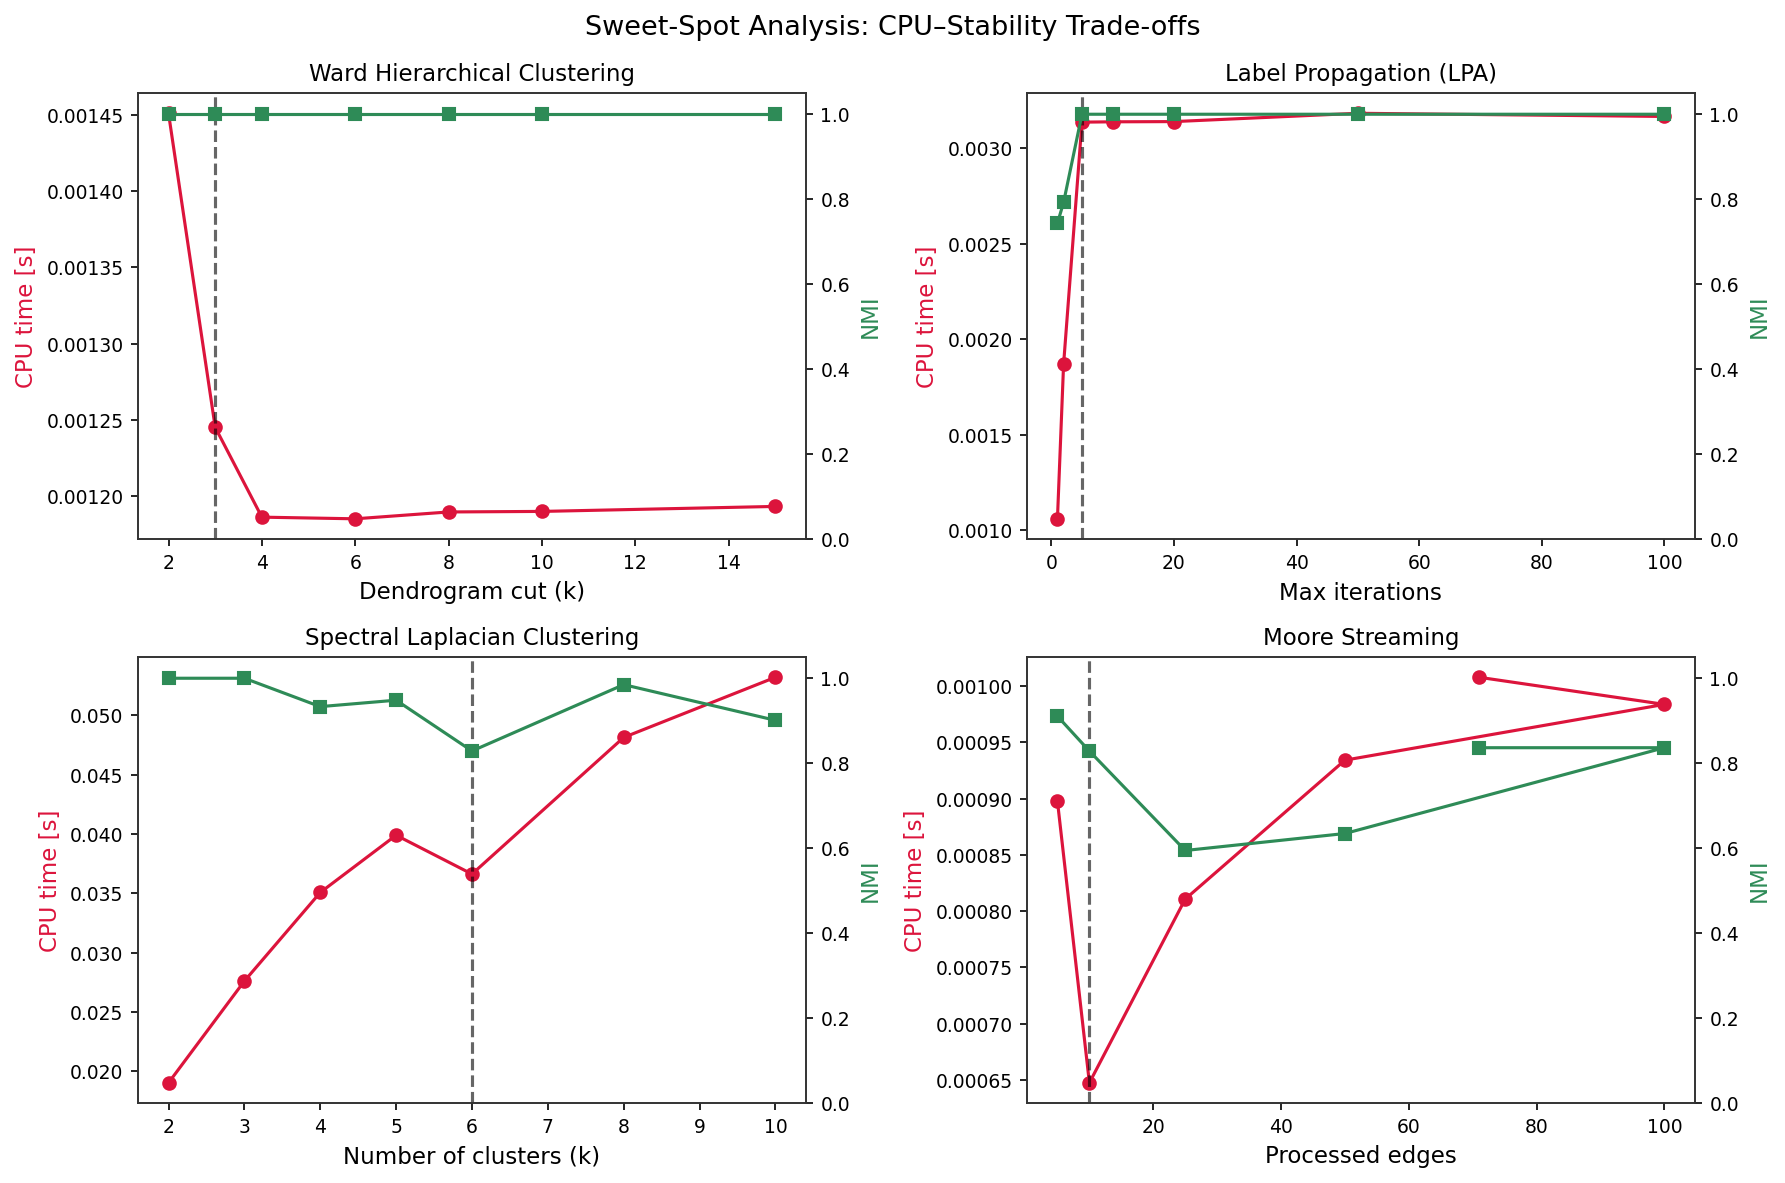

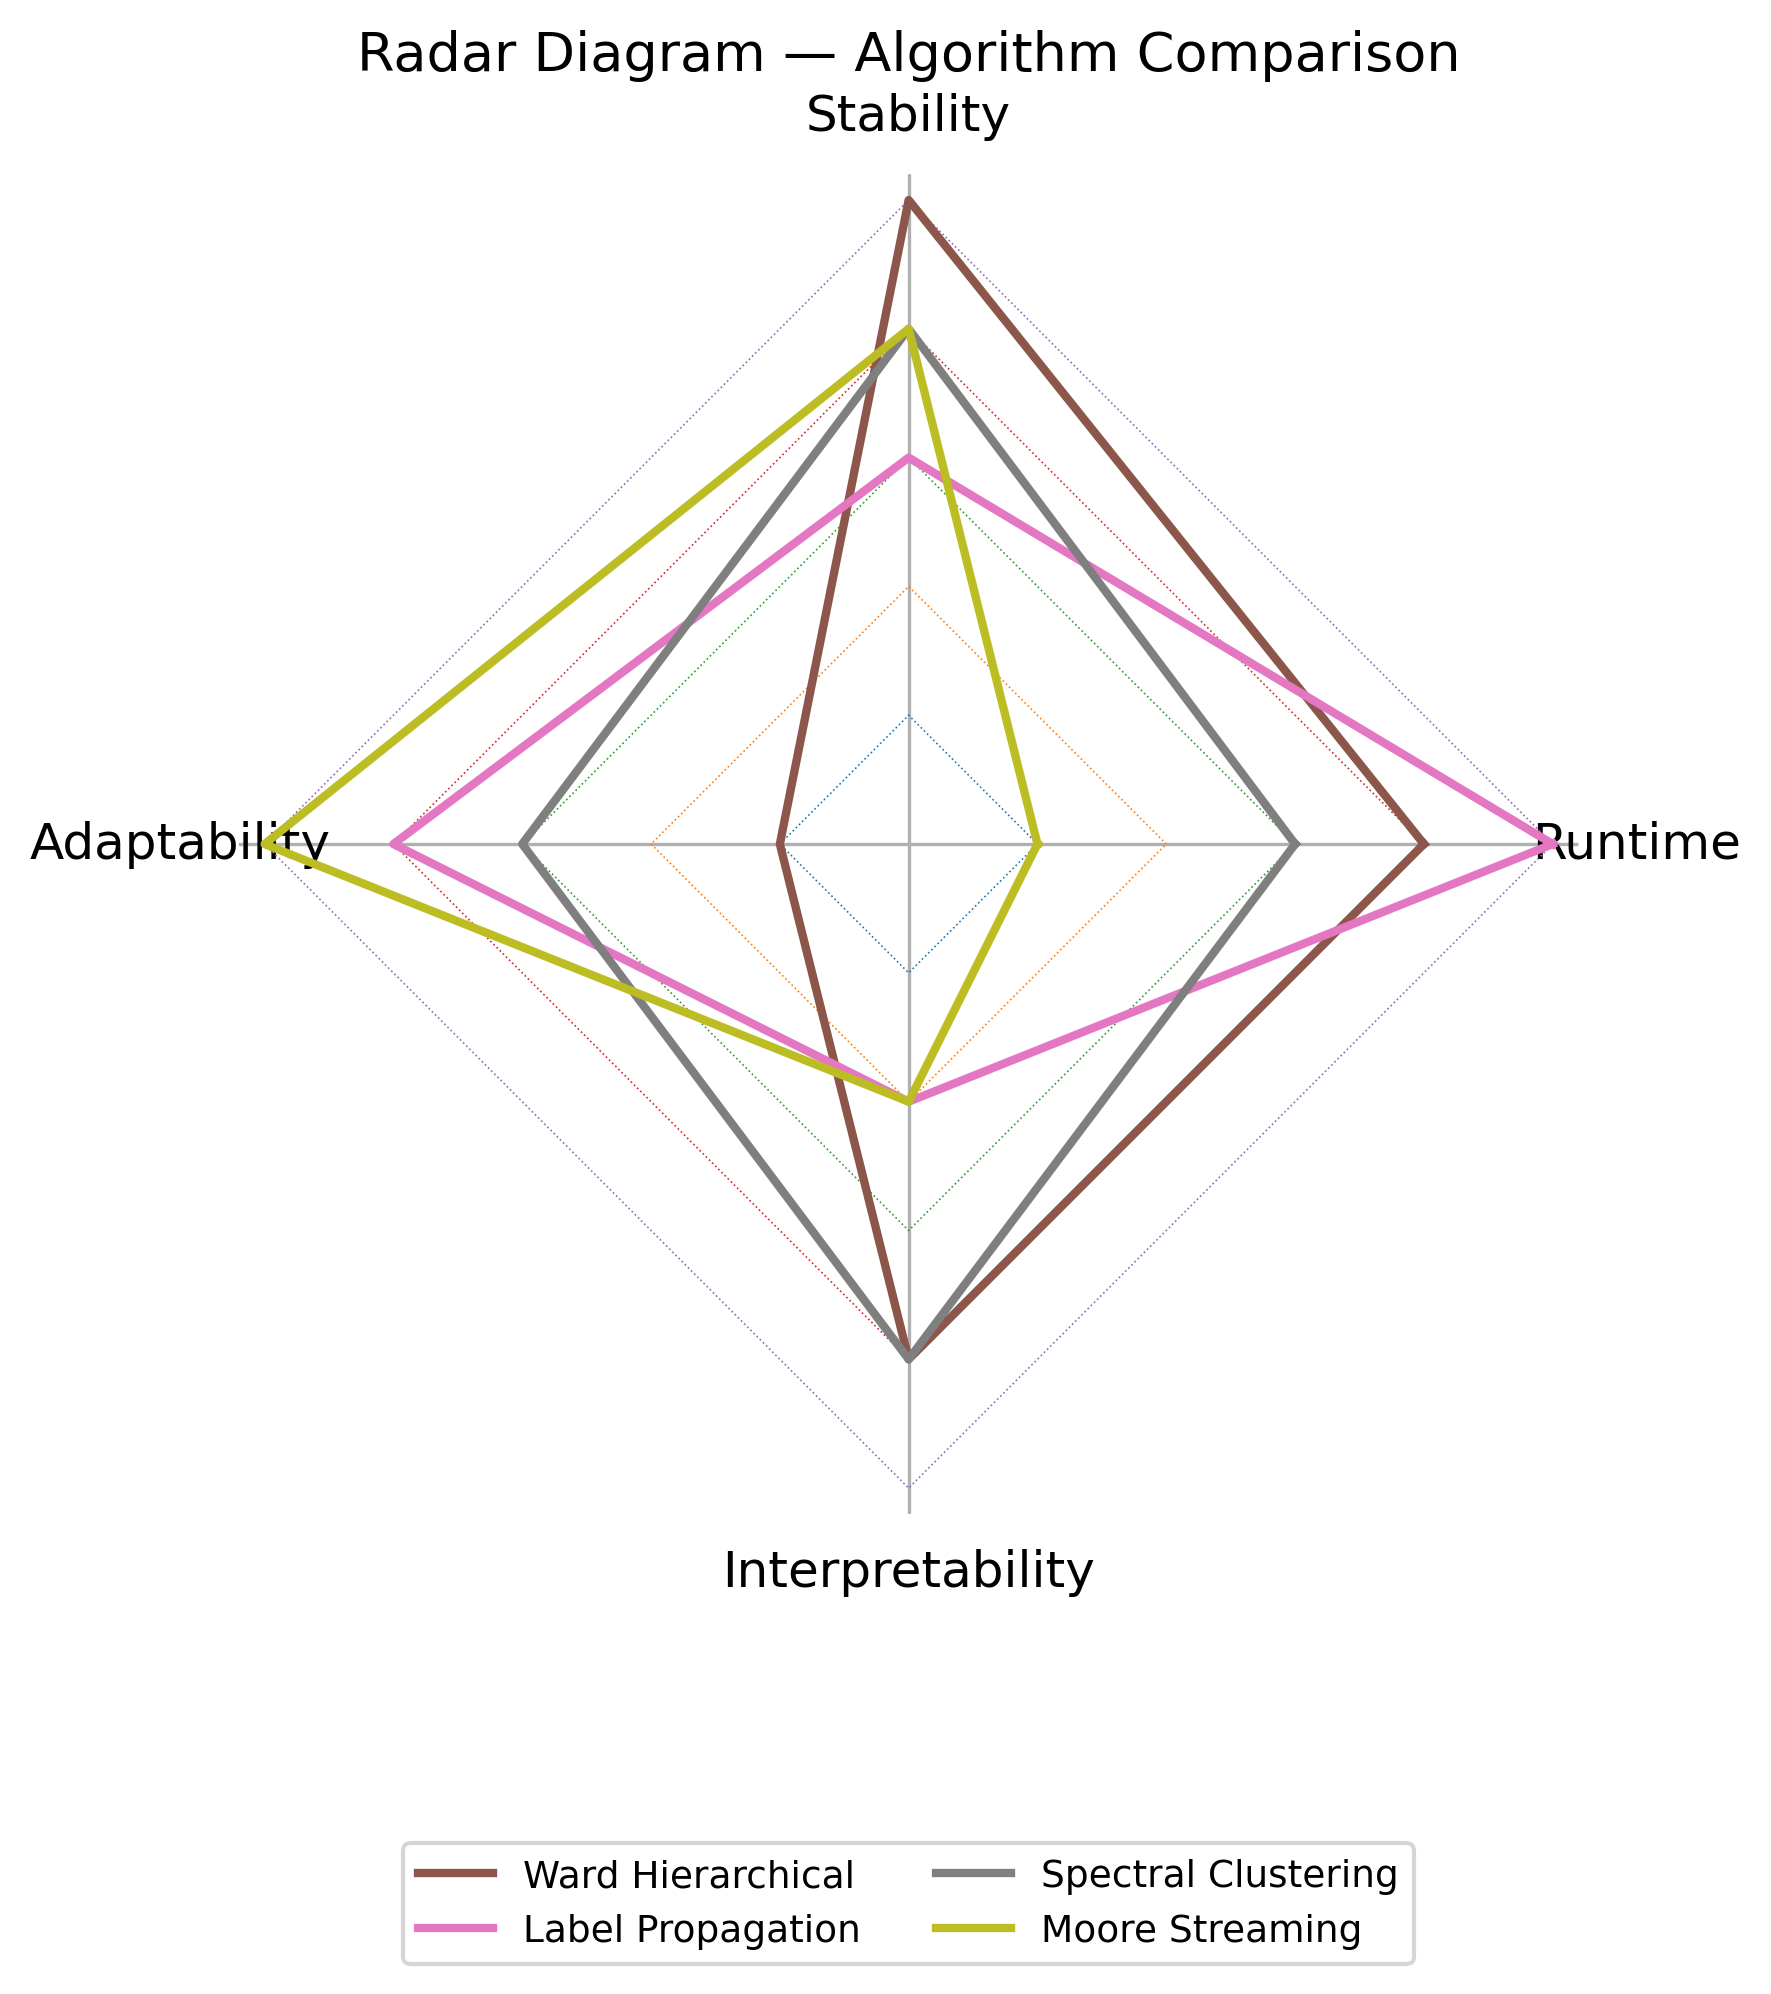

In [24]:
# ────────────────────────────────────────────────────────────────────────
run_benchmarking()

---
## SECTION 8b · LPA Comparison  (Custom vs NetworkX)

Compares **custom LPA** vs **NetworkX’s built-in** `label_propagation_communities`  
on: modularity, community count, NMI stability (10 runs), mean runtime,  
and NMI between implementations.

In [25]:
def run_lpa_comparison():
    print_section("SECTION 8b · LPA Comparison  (Custom vs NetworkX)")
    from networkx.algorithms.community import modularity as nx_modularity
    from networkx.algorithms.community import label_propagation_communities

    THRESHOLD = 0.2
    N_RUNS    = 10

    def _nmi(labels_a, labels_b):
        """NMI via sparse joint-count — O(n)."""
        a, b = np.asarray(labels_a), np.asarray(labels_b)
        n = len(a)
        _, a_idx = np.unique(a, return_inverse=True)
        _, b_idx = np.unique(b, return_inverse=True)
        joint = Counter(zip(a_idx.tolist(), b_idx.tolist()))
        pa = np.bincount(a_idx) / n
        pb = np.bincount(b_idx) / n
        mi = sum(
            cnt / n * np.log((cnt / n) / (pa[i] * pb[j]))
            for (i, j), cnt in joint.items()
        )
        ha = -(pa[pa > 0] * np.log(pa[pa > 0])).sum()
        hb = -(pb[pb > 0] * np.log(pb[pb > 0])).sum()
        return float(2 * mi / (ha + hb)) if ha + hb > 0 else 1.0

    def _to_labels(n_nodes, partition):
        labels = np.empty(n_nodes, dtype=int)
        for comm_id, community in enumerate(partition):
            for node in community:
                labels[node] = comm_id
        return labels

    def _to_sets(labels):
        comms = defaultdict(set)
        for node, lab in enumerate(labels):
            comms[lab].add(node)
        return list(comms.values())

    def _custom_lpa(G_, max_iter=100, seed=None):
        if seed is not None:
            random.seed(seed)
        lbs = {node: node for node in G_.nodes()}
        for _ in range(max_iter):
            changes = 0
            nodes = list(G_.nodes()); random.shuffle(nodes)
            for node in nodes:
                nb = [lbs[n] for n in G_.neighbors(node)]
                if not nb:
                    continue
                new_lb = Counter(nb).most_common(1)[0][0]
                if lbs[node] != new_lb:
                    lbs[node] = new_lb; changes += 1
            if changes == 0:
                break
        comms = defaultdict(set)
        for node, lb in lbs.items():
            comms[lb].add(node)
        return list(comms.values())

    # ── Load graph ────────────────────────────────────────────────────────────
    A = sp.load_npz(NPZ_PATH).tocsr()
    A.data[A.data < THRESHOLD] = 0; A.eliminate_zeros()
    G = nx.from_scipy_sparse_array(A)
    n_nodes = G.number_of_nodes()
    print(f"  Graph: {n_nodes:,} nodes | {G.number_of_edges():,} edges (threshold={THRESHOLD})")

    # ── Custom LPA runs ───────────────────────────────────────────────────────
    print(f"  Running custom LPA {N_RUNS} times …")
    custom_runs, custom_times = [], []
    for i in range(N_RUNS):
        t0 = time.perf_counter()
        partition = _custom_lpa(G, seed=i)
        custom_times.append(time.perf_counter() - t0)
        custom_runs.append(_to_labels(n_nodes, partition))
        print(f"    run {i+1}: {len(partition)} communities  ({custom_times[-1]:.2f}s)")
    print(f"  Custom mean runtime: {np.mean(custom_times):.2f}s")

    # ── NetworkX LPA runs ─────────────────────────────────────────────────────
    print(f"  Running NetworkX LPA {N_RUNS} times …")
    nx_runs, nx_times = [], []
    for i in range(N_RUNS):
        t0 = time.perf_counter()
        partition = list(label_propagation_communities(G))
        nx_times.append(time.perf_counter() - t0)
        nx_runs.append(_to_labels(n_nodes, partition))
        print(f"    run {i+1}: {len(partition)} communities  ({nx_times[-1]:.2f}s)")
    print(f"  NetworkX mean runtime: {np.mean(nx_times):.2f}s")

    # ── Metrics ───────────────────────────────────────────────────────────────
    Q_custom = nx_modularity(G, _to_sets(custom_runs[0]))
    Q_nx     = nx_modularity(G, _to_sets(nx_runs[0]))

    custom_stability = float(np.mean([
        _nmi(custom_runs[0], custom_runs[i]) for i in range(1, N_RUNS)
    ]))
    nx_stability = float(np.mean([
        _nmi(nx_runs[0], nx_runs[i]) for i in range(1, N_RUNS)
    ]))
    nmi_between = _nmi(custom_runs[0], nx_runs[0])

    W = 35
    print(f"\n{'='*67}")
    print(f"  BENCHMARK SUMMARY — LPA Comparison · CHB-01 chb01_03")
    print(f"{'='*67}")
    print(f"  {'Metric':<{W}} {'Custom LPA':>12} {'NetworkX LPA':>14}")
    print(f"  {'-'*62}")
    print(f"  {'Communities (run 1)':<{W}} "
          f"{len(_to_sets(custom_runs[0])):>12} "
          f"{len(_to_sets(nx_runs[0])):>14}")
    print(f"  {'Modularity':<{W}} {Q_custom:>12.4f} {Q_nx:>14.4f}")
    print(f"  {'Stability (mean NMI across runs)':<{W}} "
          f"{custom_stability:>12.4f} {nx_stability:>14.4f}")
    print(f"  {'Mean runtime (s)':<{W}} "
          f"{np.mean(custom_times):>12.2f} {np.mean(nx_times):>14.2f}")
    print(f"  {'-'*62}")
    print(f"  {'NMI between implementations':<{W}} {nmi_between:>12.4f}")
    print(f"{'='*67}")

    # ── Figure 1: community size distributions ────────────────────────────────
    custom_sizes = sorted([len(c) for c in _to_sets(custom_runs[0])], reverse=True)
    nx_sizes     = sorted([len(c) for c in _to_sets(nx_runs[0])],     reverse=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, sizes, title, color in [
        (axes[0], custom_sizes, "Custom LPA",   "steelblue"),
        (axes[1], nx_sizes,     "NetworkX LPA", "tomato"),
    ]:
        ax.bar(range(len(sizes)), sizes, color=color, alpha=0.8)
        ax.set_xlabel("Community rank"); ax.set_ylabel("Size (nodes)")
        ax.set_title(f"{title} — {len(sizes)} communities")
    plt.suptitle("LPA Community Size Distributions", fontsize=13)
    plt.tight_layout()
    out = FIG_DIR / "lpa_comparison_size_dist.png"
    if not out.exists():
        plt.savefig(out, dpi=150); print("  Saved lpa_comparison_size_dist.png")
    plt.close()

    # ── Figure 2: stability (NMI vs run 1) across runs ───────────────────────
    custom_nmi_runs = [_nmi(custom_runs[0], r) for r in custom_runs[1:]]
    nx_nmi_runs     = [_nmi(nx_runs[0],     r) for r in nx_runs[1:]]
    fig, ax = plt.subplots(figsize=(8, 4))
    run_ids = range(1, N_RUNS)
    ax.plot(run_ids, custom_nmi_runs, "o-", color="steelblue", label="Custom LPA")
    ax.plot(run_ids, nx_nmi_runs,     "s-", color="tomato",    label="NetworkX LPA")
    ax.set_xlabel("Run index"); ax.set_ylabel("NMI vs run 1")
    ax.set_ylim(0, 1.05); ax.set_title("LPA Stability across runs"); ax.legend()
    plt.tight_layout()
    out = FIG_DIR / "lpa_comparison_stability.png"
    if not out.exists():
        plt.savefig(out, dpi=150); print("  Saved lpa_comparison_stability.png")
    plt.close()

    _ok("LPA Comparison", f"Q_custom={Q_custom:.4f}, Q_nx={Q_nx:.4f}, NMI_between={nmi_between:.4f}")
    display_table_for_section(
        "SECTION 8b · LPA Comparison — Summary",
        {
            "Communities — Custom LPA":   len(_to_sets(custom_runs[0])),
            "Communities — NetworkX LPA": len(_to_sets(nx_runs[0])),
            "Modularity — Custom LPA":    f"{Q_custom:.4f}",
            "Modularity — NetworkX LPA":  f"{Q_nx:.4f}",
            "Stability (NMI) — Custom":   f"{custom_stability:.4f}",
            "Stability (NMI) — NetworkX": f"{nx_stability:.4f}",
            "NMI between implementations": f"{nmi_between:.4f}",
            "Mean runtime — Custom (s)":  f"{np.mean(custom_times):.2f}",
            "Mean runtime — NetworkX (s)": f"{np.mean(nx_times):.2f}",
        },
    )
    display_figures_for_section(
        "SECTION 8b · LPA Comparison",
        [
            "lpa_comparison_size_dist.png",
            "lpa_comparison_stability.png",
        ],
    )


──────────────────────────────────────────────────────────────────────
  SECTION 8b · LPA Comparison  (Custom vs NetworkX)
──────────────────────────────────────────────────────────────────────
  Graph: 176,640 nodes | 1,943,040 edges (threshold=0.2)
  Running custom LPA 10 times …
    run 1: 7680 communities  (5.53s)
    run 2: 7680 communities  (5.47s)
    run 3: 7680 communities  (5.55s)
    run 4: 7680 communities  (5.40s)
    run 5: 7680 communities  (5.61s)
    run 6: 7680 communities  (5.42s)
    run 7: 7680 communities  (5.46s)
    run 8: 7680 communities  (5.47s)
    run 9: 7680 communities  (5.43s)
    run 10: 7680 communities  (5.52s)
  Custom mean runtime: 5.49s
  Running NetworkX LPA 10 times …
    run 1: 7680 communities  (4.11s)
    run 2: 7680 communities  (4.11s)
    run 3: 7680 communities  (4.07s)
    run 4: 7680 communities  (4.50s)
    run 5: 7680 communities  (4.09s)
    run 6: 7680 communities  (4.12s)
    run 7: 7680 communities  (4.07s)
    run 8: 7680 communi

,Metric,Value
0,Communities — Custom LPA,7680
1,Communities — NetworkX LPA,7680
2,Modularity — Custom LPA,0.9999
3,Modularity — NetworkX LPA,0.9999
4,Stability (NMI) — Custom,1.0000
5,Stability (NMI) — NetworkX,1.0000
6,NMI between implementations,1.0000
7,Mean runtime — Custom (s),5.49
8,Mean runtime — NetworkX (s),4.14


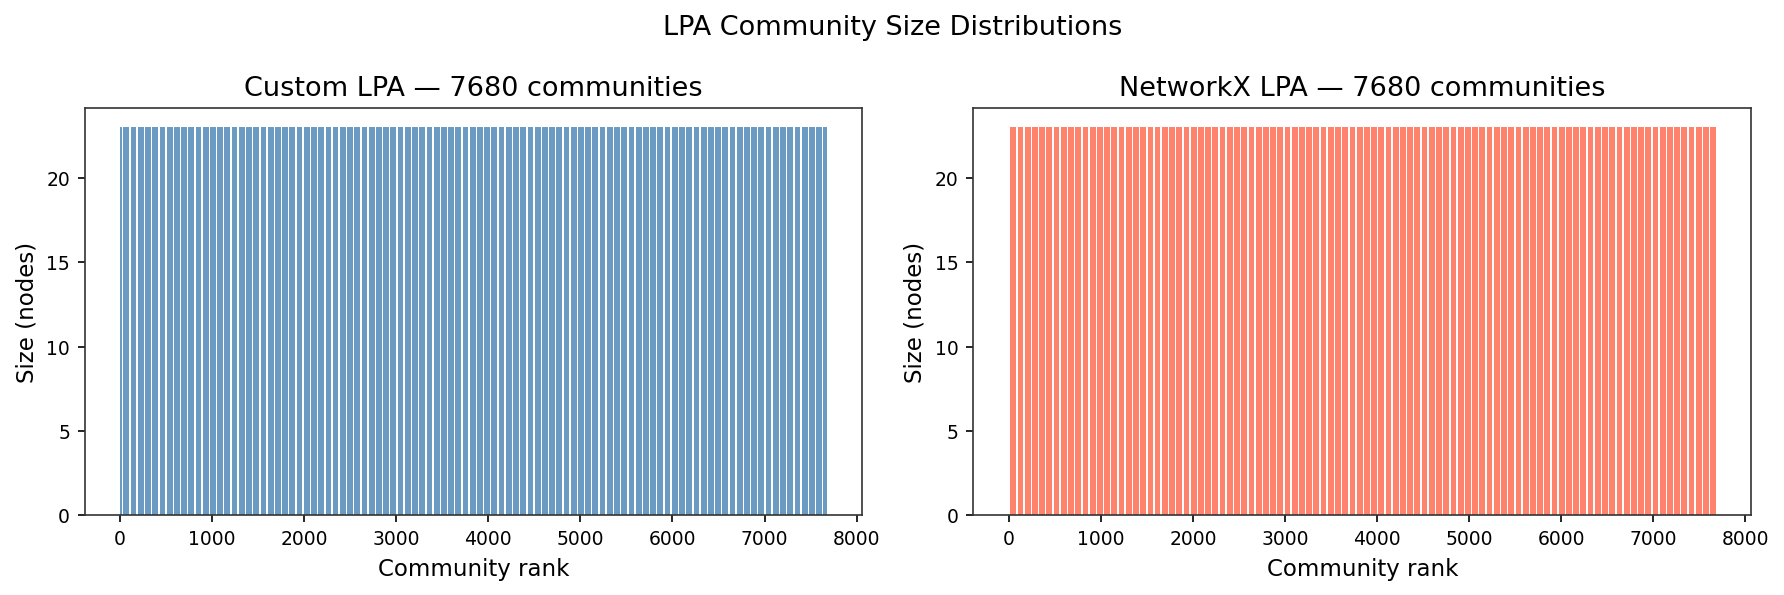

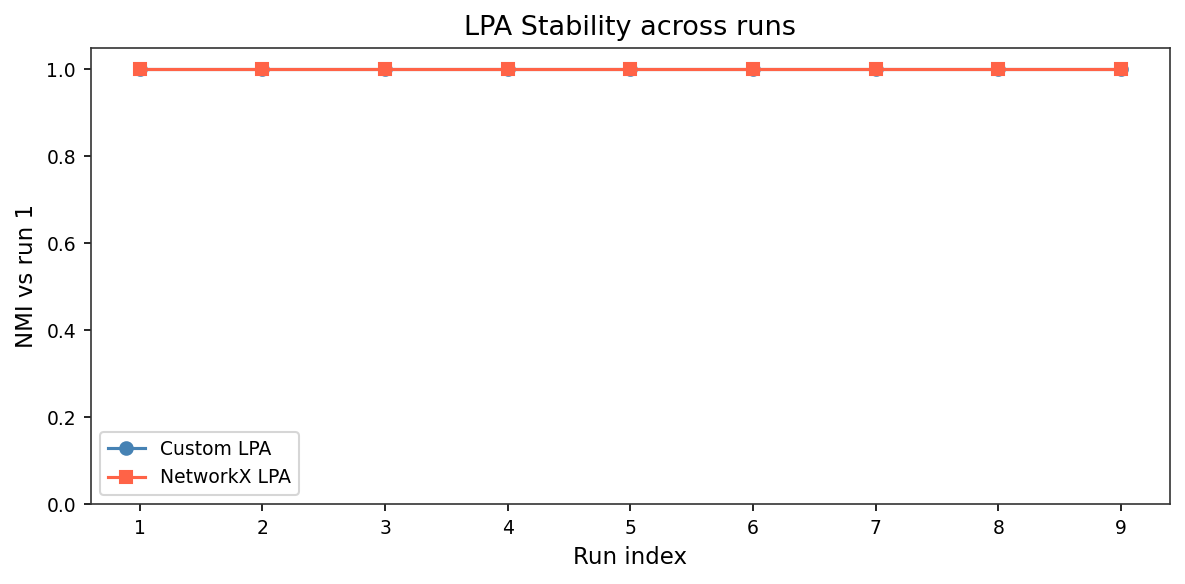

In [26]:
# ────────────────────────────────────────────────────────────────────────
run_lpa_comparison()

---
## SECTION 9 · HTML Visualisation Generation

Generates two **self-contained HTML files** (no server needed, open in any browser):

1. `eeg_vg_network_inter.html` — animated electrode-level connectivity,  
   node size/colour = mean HVG degree, edges = sliding-window Pearson correlation
2. `eeg_visibility_graph_online_mini_timepoint.html` — 23 electrodes in head layout,  
   each showing its circular mini-VG with 16 subsampled timepoints per window

In [27]:
def generate_html_visualisations():
    """
    Generates two self-contained browser HTML animations directly from the
    adjacency NPZ (no template files required).

    eeg_vg_network_inter.html
        23-electrode functional connectivity network animated over 30 windows.
        Node size/color = mean intra-layer HVG degree per window.
        Edge = Pearson correlation of degree sequences (sliding 3-window).

    eeg_visibility_graph_online_mini_timepoint.html
        All 23 electrodes in head layout, each as a small circular VG.
        16 subsampled timepoints per electrode per window.
    """
    print_section("SECTION 9 · HTML Visualisation Generation")
    HTML_DIR = BASE_DIR / "src" / "04_visualization"
    HTML_DIR.mkdir(parents=True, exist_ok=True)

    if not NPZ_PATH.exists():
        _skip("HTML visualisations", "adjacency NPZ missing — run graph construction first")
        return

    N_WIN_H = N_TP // FS        # 30 one-second windows
    WIN_H   = FS                 # 256 samples per window
    N_BINS  = 16                 # mini-view: 16 subsampled timepoints per window
    STEP_B  = WIN_H // N_BINS    # 16 samples per bin
    SZ_WIN  = 15                 # window index of seizure onset (0-indexed)

    ELEC_LABELS = ["FP1","FP2","F7","F3","FZ","F4","F8","T7","C3","CZ","C4","T8",
                   "P7","P3","PZ","P4","P8","O1","OZ","O2","A1","A2","T9"]
    ELEC_POS = [
        [.5,.05],[.55,.05],[.15,.18],[.35,.15],[.5,.12],[.65,.15],[.85,.18],
        [.1,.45],[.3,.38],[.5,.35],[.7,.38],[.9,.45],
        [.1,.7],[.3,.62],[.5,.6],[.7,.62],[.9,.7],
        [.3,.85],[.5,.82],[.7,.85],
        [.05,.55],[.95,.55],[.05,.75],
    ]

    # ── Load NPZ → intra-layer degree per node ────────────────────────────────
    print("  Loading adjacency NPZ …")
    mat = sp.load_npz(NPZ_PATH)
    cx  = mat.tocoo()
    rows_elec = cx.row // N_TP
    rows_time = cx.row % N_TP
    same      = rows_elec == (cx.col // N_TP)

    intra_mat = sp.csr_matrix(
        (np.ones(same.sum(), dtype=np.float32), (cx.row[same], cx.col[same])),
        shape=mat.shape,
    )
    intra_deg = (np.array(intra_mat.sum(axis=1)).flatten() +
                 np.array(intra_mat.sum(axis=0)).flatten())
    deg_full  = intra_deg.reshape(N_CH, N_TP)   # (23, 7680)
    print(f"  Intra-layer edges: {same.sum():,}  |  mean pre-deg: {deg_full[:,:SZ_WIN*WIN_H].mean():.3f}")

    # ── Per-window: mean degree, subsampled edges & mini-bins ─────────────────
    print("  Computing per-window data …")
    deg_wins   = np.zeros((N_CH, N_WIN_H), dtype=np.float64)
    edges_wins = [[[] for _ in range(N_CH)] for _ in range(N_WIN_H)]
    deg_mini   = np.zeros((N_CH, N_WIN_H, N_BINS), dtype=np.float64)

    for w in range(N_WIN_H):
        t0 = w * WIN_H; t1 = t0 + WIN_H
        for ch in range(N_CH):
            deg_wins[ch, w] = deg_full[ch, t0:t1].mean()
            sub_idx = np.arange(0, WIN_H, STEP_B)[:N_BINS]
            deg_mini[ch, w] = deg_full[ch, t0:t1][sub_idx]
            mask = (same & (rows_elec == ch) & (rows_time >= t0) & (rows_time < t1))
            r_tp = (cx.row[mask] % N_TP) - t0
            c_tp = (cx.col[mask] % N_TP) - t0
            seen = set()
            for ri, ci in zip(r_tp.tolist(), c_tp.tolist()):
                if ri >= ci or ri < 0 or ci >= WIN_H or (ri, ci) in seen:
                    continue
                seen.add((ri, ci))
                ri_s = ri // STEP_B; ci_s = ci // STEP_B
                if ri_s < N_BINS and ci_s < N_BINS and ri_s != ci_s:
                    edges_wins[w][ch].append([int(ri_s), int(ci_s)])
            edges_wins[w][ch] = [[a, b] for a, b in
                                  {(min(a, b), max(a, b)) for a, b in edges_wins[w][ch]}]
        if w % 5 == 0:
            print(f"\r    window {w:2d}/{N_WIN_H}", end="", flush=True)
    print()

    # ── Sliding-window Pearson correlation (3-window) ─────────────────────────
    print("  Computing sliding-window correlation …")
    adj_corr = np.zeros((N_WIN_H, N_CH, N_CH))
    for w in range(N_WIN_H):
        seg = deg_wins[:, max(0, w - 2):w + 1]
        for i in range(N_CH):
            for j in range(i + 1, N_CH):
                a, b = seg[i], seg[j]
                if len(a) < 2: continue
                na, nb = a - a.mean(), b - b.mean()
                denom  = np.sqrt((na**2).sum() * (nb**2).sum())
                if denom == 0: continue
                r = max(0.0, float((na * nb).sum() / denom))
                adj_corr[w, i, j] = adj_corr[w, j, i] = round(r, 4)

    # ── Pack JSON data ────────────────────────────────────────────────────────
    data1_json = json.dumps({
        "deg": [[round(float(deg_wins[ch, w]), 4) for w in range(N_WIN_H)]
                for ch in range(N_CH)],
        "adj": [[[round(float(adj_corr[w, i, j]), 4) for j in range(N_CH)]
                  for i in range(N_CH)]
                for w in range(N_WIN_H)],
        "n_elec": N_CH, "n_windows": N_WIN_H, "seizure": SZ_WIN, "labels": ELEC_LABELS,
    }, separators=(",", ":"))

    data2_json = json.dumps({
        "deg":  [[[round(float(deg_mini[ch, w, k]), 4) for k in range(N_BINS)]
                  for w in range(N_WIN_H)]
                 for ch in range(N_CH)],
        "edges": edges_wins,
        "n_elec": N_CH, "n_windows": N_WIN_H, "n_nodes": N_BINS,
        "seizure": SZ_WIN, "labels": ELEC_LABELS,
    }, separators=(",", ":"))

    pos_js = json.dumps(ELEC_POS)

    # ── HTML 1: electrode-level functional connectivity network ───────────────
    html1 = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>EEG Visibility Graph Network</title>
<style>
*{{margin:0;padding:0;box-sizing:border-box}}
body{{background:#0a0a12;color:#ccc;font-family:'Courier New',monospace;display:flex;flex-direction:column;height:100vh}}
#hdr{{padding:8px 16px;border-bottom:1px solid #151525;display:flex;align-items:center;gap:12px;flex-shrink:0}}
#hdr h1{{font-size:11px;color:#444;letter-spacing:.1em;text-transform:uppercase}}
#phase{{padding:2px 8px;border-radius:3px;font-size:10px;transition:all .4s}}
.pre{{background:rgba(40,100,220,.15);color:#4d9fff;border:1px solid rgba(40,100,220,.3)}}
.ict{{background:rgba(220,60,30,.15);color:#ff5533;border:1px solid rgba(220,60,30,.3)}}
#stats{{margin-left:auto;display:flex;gap:16px;font-size:10px;color:#555}}
#stats b{{color:#888}}
#thr-wrap{{display:flex;align-items:center;gap:6px;font-size:10px;color:#555}}
#cw{{flex:1;position:relative}}
canvas{{display:block;width:100%;height:100%}}
#ctrl{{padding:8px 16px;border-top:1px solid #151525;display:flex;align-items:center;gap:12px;flex-shrink:0}}
#pb{{width:28px;height:28px;border-radius:50%;background:#4d9fff;border:none;cursor:pointer;font-size:13px;color:#fff}}
#tl{{flex:1;position:relative;height:26px;cursor:pointer}}
#tl-bg{{position:absolute;top:50%;transform:translateY(-50%);width:100%;height:2px;background:#151525}}
#tl-fill{{position:absolute;top:50%;transform:translateY(-50%);height:2px;background:#fff;opacity:.25;width:0%}}
#tl-sz{{position:absolute;top:0;height:100%;width:1px;background:rgba(255,85,51,.6);left:50%}}
#tl-cur{{position:absolute;top:50%;transform:translate(-50%,-50%);width:10px;height:10px;border-radius:50%;background:#fff;left:0%;transition:left .12s}}
.tlb{{position:absolute;bottom:0;font-size:8px;color:#333;transform:translateX(-50%)}}
#lbl{{font-size:10px;color:#555;min-width:50px}}
</style>
</head>
<body>
<div id="hdr">
  <h1>EEG Visibility Graph Network &middot; CHB01 &middot; 23 Electrodes</h1>
  <div id="phase" class="pre">PRE-ICTAL</div>
  <div id="stats">
    <span>t=<b id="sw">0s</b></span>
    <span>edges=<b id="se">0</b></span>
    <span>max corr=<b id="sc">0.00</b></span>
  </div>
  <div id="thr-wrap">
    threshold: <input type="range" id="thr" min="0" max="100" value="30" style="width:80px;accent-color:#4d9fff">
    <span id="thr-val">0.30</span>
  </div>
</div>
<div id="cw"><canvas id="c"></canvas></div>
<div id="ctrl">
  <button id="pb" onclick="togglePlay()">&#9654;</button>
  <div id="tl">
    <div id="tl-bg"></div><div id="tl-fill"></div>
    <div id="tl-sz"></div><div id="tl-cur"></div>
    <div class="tlb" style="left:0%">0s</div>
    <div class="tlb" style="left:16.7%">5s</div>
    <div class="tlb" style="left:33.3%">10s</div>
    <div class="tlb" style="left:50%;color:#ff5533">&#9889;15s</div>
    <div class="tlb" style="left:66.7%">20s</div>
    <div class="tlb" style="left:83.3%">25s</div>
    <div class="tlb" style="left:100%">30s</div>
  </div>
  <div id="lbl">t=0s</div>
</div>
<script>
const D={data1_json};
const POS={pos_js};
const NW=D.n_windows,NE=D.n_elec,SZ=D.seizure,LB=D.labels;
let W=0,playing=false,timer=null;
const cv=document.getElementById('c'),ctx=cv.getContext('2d');
document.getElementById('thr').oninput=e=>{{document.getElementById('thr-val').textContent=(e.target.value/100).toFixed(2);draw(W);}};
function resize(){{const cw=document.getElementById('cw');cv.width=cw.clientWidth;cv.height=cw.clientHeight;draw(W);}}
window.addEventListener('resize',resize);setTimeout(resize,50);
function getThreshold(){{return document.getElementById('thr').value/100;}}
function draw(w){{
  const CW=cv.width,CH=cv.height,ictal=w>=SZ;
  ctx.fillStyle='#0a0a12';ctx.fillRect(0,0,CW,CH);
  const PAD=60;
  const pos=POS.map(p=>([PAD+p[0]*(CW-2*PAD),PAD+p[1]*(CH-2*PAD)]));
  const deg=D.deg.map(d=>d[w]);
  const maxDeg=Math.max(...deg,0.001);
  const adj=D.adj[w];const thr=getThreshold();let nEdges=0,maxCorr=0;
  for(let i=0;i<NE;i++){{for(let j=i+1;j<NE;j++){{
    const r=adj[i][j];if(r<thr)continue;nEdges++;maxCorr=Math.max(maxCorr,r);
    const alpha=0.15+(r-thr)/(1-thr+0.001)*0.7,t=(r-thr)/(1-thr+0.001);
    const R=Math.round(77+t*178),G=Math.round(159-t*100),B=Math.round(255-t*200);
    ctx.beginPath();ctx.moveTo(pos[i][0],pos[i][1]);ctx.lineTo(pos[j][0],pos[j][1]);
    ctx.strokeStyle=`rgba(${{R}},${{G}},${{B}},${{alpha}})`;ctx.lineWidth=0.5+r*4;ctx.stroke();
  }}}}
  ctx.beginPath();ctx.ellipse(CW/2,CH/2,CW*0.44,CH*0.46,0,0,Math.PI*2);
  ctx.strokeStyle='rgba(255,255,255,0.03)';ctx.lineWidth=1;ctx.stroke();
  pos.forEach((p,ei)=>{{
    const d=deg[ei],t=d/maxDeg,r=6+t*18;
    const grd=ctx.createRadialGradient(p[0],p[1],0,p[0],p[1],r*2);
    const nc=ictal?`rgba(255,85,51,${{0.3+t*0.5}})`:`rgba(77,159,255,${{0.3+t*0.5}})`;
    grd.addColorStop(0,nc);grd.addColorStop(1,'rgba(0,0,0,0)');
    ctx.beginPath();ctx.arc(p[0],p[1],r*2,0,Math.PI*2);ctx.fillStyle=grd;ctx.fill();
    ctx.beginPath();ctx.arc(p[0],p[1],r,0,Math.PI*2);
    ctx.fillStyle=ictal?`rgba(255,85,51,${{0.5+t*0.5}})`:`rgba(77,159,255,${{0.5+t*0.5}})`;ctx.fill();
    ctx.font=`${{Math.max(8,r*0.7)}}px Courier New`;
    ctx.fillStyle=`rgba(255,255,255,${{0.4+t*0.5}})`;
    ctx.textAlign='center';ctx.textBaseline='middle';ctx.fillText(LB[ei],p[0],p[1]);
  }});
  document.getElementById('sw').textContent=w<SZ?`${{w}}s`:`+${{w-SZ}}s`;
  document.getElementById('se').textContent=nEdges;
  document.getElementById('sc').textContent=maxCorr.toFixed(2);
  const badge=document.getElementById('phase');
  badge.textContent=ictal?'ICTAL':'PRE-ICTAL';badge.className=ictal?'ict':'pre';
  const pct=(w/(NW-1))*100;
  document.getElementById('tl-fill').style.width=pct+'%';
  document.getElementById('tl-cur').style.left=pct+'%';
  document.getElementById('lbl').textContent=`t=${{w<SZ?w+'s':'+'+(w-SZ)+'s'}}`;
}}
function togglePlay(){{playing=!playing;document.getElementById('pb').textContent=playing?'&#9646;&#9646;':'&#9654;';if(playing)step();else clearTimeout(timer);}}
function step(){{if(!playing)return;W=(W+1)%NW;draw(W);timer=setTimeout(step,800);}}
document.getElementById('tl').addEventListener('click',e=>{{
  const r=e.currentTarget.getBoundingClientRect();
  W=Math.round(((e.clientX-r.left)/r.width)*(NW-1));draw(W);
}});
draw(0);
</script>
</body>
</html>"""

    # ── HTML 2: per-electrode circular mini VG ────────────────────────────────
    html2 = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>EEG Visibility Graph &mdash; Seizure Network</title>
<style>
*{{margin:0;padding:0;box-sizing:border-box}}
body{{background:#0a0a12;color:#ccc;font-family:'Courier New',monospace;display:flex;flex-direction:column;height:100vh}}
#hdr{{padding:8px 16px;border-bottom:1px solid #151525;display:flex;align-items:center;gap:10px;flex-shrink:0}}
#hdr h1{{font-size:11px;color:#444;letter-spacing:.1em;text-transform:uppercase}}
#phase{{padding:2px 8px;border-radius:3px;font-size:10px;transition:all .4s}}
.pre{{background:rgba(40,100,220,.15);color:#4d9fff;border:1px solid rgba(40,100,220,.3)}}
.ict{{background:rgba(220,60,30,.15);color:#ff5533;border:1px solid rgba(220,60,30,.3)}}
#stats{{margin-left:auto;display:flex;gap:16px;font-size:10px;color:#555}}
#stats b{{color:#888}}
#cw{{flex:1;position:relative}}
canvas{{display:block;width:100%;height:100%}}
#ctrl{{padding:8px 16px;border-top:1px solid #151525;display:flex;align-items:center;gap:12px;flex-shrink:0}}
#pb{{width:28px;height:28px;border-radius:50%;background:#4d9fff;border:none;cursor:pointer;font-size:13px;color:#fff}}
#tl{{flex:1;position:relative;height:26px;cursor:pointer}}
#tl-bg{{position:absolute;top:50%;transform:translateY(-50%);width:100%;height:2px;background:#151525}}
#tl-fill{{position:absolute;top:50%;transform:translateY(-50%);height:2px;background:#fff;opacity:.25;width:0%}}
#tl-sz{{position:absolute;top:0;height:100%;width:1px;background:rgba(255,85,51,.6);left:50%}}
#tl-cur{{position:absolute;top:50%;transform:translate(-50%,-50%);width:10px;height:10px;border-radius:50%;background:#fff;left:0%;transition:left .12s}}
.tlb{{position:absolute;bottom:0;font-size:8px;color:#333;transform:translateX(-50%)}}
#lbl{{font-size:10px;color:#555;min-width:50px}}
</style>
</head>
<body>
<div id="hdr">
  <h1>EEG Visibility Graph &middot; CHB01 &middot; Seizure Onset</h1>
  <div id="phase" class="pre">PRE-ICTAL</div>
  <div id="stats">
    <span>t=<b id="sw">0s</b></span>
    <span>edges=<b id="se">0</b></span>
    <span>mean deg=<b id="sd">0.00</b></span>
    <span>top: <b id="st">-</b></span>
  </div>
</div>
<div id="cw"><canvas id="c"></canvas></div>
<div id="ctrl">
  <button id="pb" onclick="togglePlay()">&#9654;</button>
  <div id="tl">
    <div id="tl-bg"></div><div id="tl-fill"></div>
    <div id="tl-sz"></div><div id="tl-cur"></div>
    <div class="tlb" style="left:0%">0s</div>
    <div class="tlb" style="left:16.7%">5s</div>
    <div class="tlb" style="left:33.3%">10s</div>
    <div class="tlb" style="left:50%;color:#ff5533">&#9889;15s</div>
    <div class="tlb" style="left:66.7%">20s</div>
    <div class="tlb" style="left:83.3%">25s</div>
    <div class="tlb" style="left:100%">30s</div>
  </div>
  <div id="lbl">t=0s</div>
</div>
<script>
const DATA={data2_json};
const POS={pos_js};
const NW=DATA.n_windows,NE=DATA.n_elec,NN=DATA.n_nodes,SZ=DATA.seizure,LB=DATA.labels;
let W=0,playing=false,timer=null;
const cv=document.getElementById('c'),ctx=cv.getContext('2d');
function resize(){{const cw=document.getElementById('cw');cv.width=cw.clientWidth;cv.height=cw.clientHeight;draw(W);}}
window.addEventListener('resize',resize);setTimeout(resize,50);
function edgeColor(i,j){{
  const dist=Math.abs(i-j),t=Math.min(1,dist/NN);
  const stops=[[58,12,163],[67,97,238],[76,201,240],[122,229,130],[248,150,30]];
  const idx=(1-t)*(stops.length-1),si=Math.min(Math.floor(idx),stops.length-2),f=idx-si;
  const c1=stops[si],c2=stops[si+1];
  return[Math.round(c1[0]*(1-f)+c2[0]*f),Math.round(c1[1]*(1-f)+c2[1]*f),Math.round(c1[2]*(1-f)+c2[2]*f)];
}}
function draw(w){{
  const CW=cv.width,CH=cv.height,ictal=w>=SZ;
  ctx.fillStyle='#0a0a12';ctx.fillRect(0,0,CW,CH);
  const PAD=30,R=Math.min(CW,CH)*0.065;
  ctx.beginPath();ctx.ellipse(CW/2,CH/2,CW*0.44,CH*0.46,0,0,Math.PI*2);
  ctx.strokeStyle='rgba(255,255,255,0.03)';ctx.lineWidth=1;ctx.stroke();
  let totalEdges=0,totalDeg=0,topElec='',topDeg=0;
  POS.forEach((p,ei)=>{{
    const ex=PAD+p[0]*(CW-2*PAD),ey=PAD+p[1]*(CH-2*PAD);
    const deg=DATA.deg[ei][w],edges=DATA.edges[w][ei];
    const maxDeg=Math.max(...deg,0.001),meanDeg=deg.reduce((a,b)=>a+b,0)/NN;
    totalEdges+=edges.length;totalDeg+=meanDeg;
    if(meanDeg>topDeg){{topDeg=meanDeg;topElec=LB[ei];}}
    const pts=Array.from({{length:NN}},(_,k)=>{{
      const a=(k/NN)*Math.PI*2-Math.PI/2;
      return{{x:ex+R*0.82*Math.cos(a),y:ey+R*0.82*Math.sin(a)}};
    }});
    edges.forEach(([a,b])=>{{
      if(a<0||a>=NN||b<0||b>=NN)return;
      const[r,g,bl]=edgeColor(a,b),dist=Math.abs(a-b),alpha=0.2+(dist/NN)*0.6;
      const p1=pts[a],p2=pts[b],tc=0.3+(1-dist/NN)*0.4;
      ctx.beginPath();ctx.moveTo(p1.x,p1.y);
      ctx.quadraticCurveTo(ex*tc+(p1.x+p2.x)/2*(1-tc),ey*tc+(p1.y+p2.y)/2*(1-tc),p2.x,p2.y);
      ctx.strokeStyle=`rgba(${{r}},${{g}},${{bl}},${{alpha}})`;ctx.lineWidth=0.8+(dist/NN)*2;ctx.stroke();
    }});
    const meanT=meanDeg/maxDeg;
    ctx.beginPath();ctx.arc(ex,ey,R,0,Math.PI*2);
    ctx.strokeStyle=ictal?`rgba(255,85,51,${{0.06+meanT*0.12}})`:`rgba(77,159,255,${{0.04+meanT*0.08}})`;
    ctx.lineWidth=1+meanT*1.5;ctx.stroke();
    pts.forEach((pt,k)=>{{
      const d=deg[k],t=d/maxDeg,nr=1.5+t*5;
      ctx.beginPath();ctx.arc(pt.x,pt.y,nr,0,Math.PI*2);
      ctx.fillStyle=d>0?(ictal?`rgba(255,85,51,${{0.4+t*0.6}})`:`rgba(77,159,255,${{0.4+t*0.6}})`):'rgba(255,255,255,0.08)';
      ctx.fill();
    }});
    ctx.font=`bold ${{Math.max(6,R*0.22)}}px Courier New`;
    ctx.fillStyle=ictal?'rgba(255,85,51,.7)':'rgba(77,159,255,.7)';
    ctx.textAlign='center';ctx.textBaseline='middle';ctx.fillText(LB[ei],ex,ey);
  }});
  document.getElementById('sw').textContent=w<SZ?`${{w}}s`:`+${{w-SZ}}s`;
  document.getElementById('se').textContent=totalEdges;
  document.getElementById('sd').textContent=(totalDeg/NE).toFixed(2);
  document.getElementById('st').textContent=topElec;
  const badge=document.getElementById('phase');
  badge.textContent=ictal?'ICTAL':'PRE-ICTAL';badge.className=ictal?'ict':'pre';
  const pct=(w/(NW-1))*100;
  document.getElementById('tl-fill').style.width=pct+'%';
  document.getElementById('tl-cur').style.left=pct+'%';
  document.getElementById('lbl').textContent=`t=${{w<SZ?w+'s':'+'+(w-SZ)+'s'}}`;
}}
function togglePlay(){{playing=!playing;document.getElementById('pb').textContent=playing?'&#9646;&#9646;':'&#9654;';if(playing)step();else clearTimeout(timer);}}
function step(){{if(!playing)return;W=(W+1)%NW;draw(W);timer=setTimeout(step,800);}}
document.getElementById('tl').addEventListener('click',e=>{{
  const r=e.currentTarget.getBoundingClientRect();
  W=Math.round(((e.clientX-r.left)/r.width)*(NW-1));draw(W);
}});
draw(0);
</script>
</body>
</html>"""

    # ── Write self-contained HTML files ───────────────────────────────────────
    p1 = HTML_DIR / "eeg_vg_network_inter.html"
    p1.write_text(html1, encoding="utf-8")
    print(f"  Saved {p1.name}  ({p1.stat().st_size // 1024} kB)")
    _ok("HTML: eeg_vg_network_inter.html", "open in browser")

    p2 = HTML_DIR / "eeg_visibility_graph_online_mini_timepoint.html"
    p2.write_text(html2, encoding="utf-8")
    print(f"  Saved {p2.name}  ({p2.stat().st_size // 1024} kB)")
    _ok("HTML: eeg_visibility_graph_online_mini_timepoint.html", "open in browser")

In [28]:
# ────────────────────────────────────────────────────────────────────────
generate_html_visualisations()


──────────────────────────────────────────────────────────────────────
  SECTION 9 · HTML Visualisation Generation
──────────────────────────────────────────────────────────────────────
  Loading adjacency NPZ …
  Intra-layer edges: 70,322  |  mean pre-deg: 0.181
  Computing per-window data …
    window 25/30
  Computing sliding-window correlation …
  Saved eeg_vg_network_inter.html  (95 kB)
  Saved eeg_visibility_graph_online_mini_timepoint.html  (77 kB)
